# Day 18 / Notebook 22 — Frequency rebasing, design first

## Entry context
Day 17 (commit `df2dbee`) closed the τ_ref availability audit on 8 axis-(a)-runnable parameter sets. HPPC 1C / 10s pulse + 600 s relaxation at SoC ≈ 10 % returned a **STRUCTURED BROAD** verdict: under `tau2_biexp(600s)`, max/min = 3.561 satisfies BROAD with a 7+1 outlier pattern — Ecker2015 fast outlier (16.52 s); the remaining seven sets cluster 36.32–58.82 s with internal max/min ≈ 1.62. Cross-descriptor Spearman mean = 0.590 separates the recovery-time family (`tau_FG_eff` / `t95` / `t99`) from the bi-exp family. The 7+1 pattern is therefore a `tau2_biexp` finding; whether `tau_FG_eff` reproduces the same structure is a **Cell 2 verification**, not a Day 17 inheritance.

## Descriptor role lock (Day 18)
- **Main descriptor for first rebasing**: `tau_FG_eff`
- **Sensitivity**: `tau2_secondary_60s`
- **Slow-tail references (informational only)**: `tau2_biexp`, `tau_tail`
- **Outlier-policy gating**: All-8 + 7-set dual-line reporting is **provisional**. Its activation depends on Cell 2 confirming that under `tau_FG_eff`, (i) Ecker2015 is the standalone minimum, (ii) the gap from Ecker2015 to the next-smallest is appreciable relative to the median in-cluster gap, and (iii) the 7-set max/min is meaningfully tighter than the all-8 max/min. Failure of (i)–(iii) triggers an outlier-policy revision.

## Hard constraints carried into Day 18
- **Main grid amplitude rule**: `|DC| + |AC| ≤ 1 C`. This is the post-Day-16 main-protocol constraint introduced to keep the rebasing branch aligned with the MJ1 experimental peak-current boundary. Day 16 itself contained stress cases up to `|DC|+|AC| = 1.2 C` (e.g. 0.2 C + 1.0 C @ 10τ); these are now downgraded to boundary-audit only and do not enter the Day 18 main grid.
- **DC baseline shared between main and audit**: 1 × `DC_0p2C` baseline per set, reused as the Δt(Q) reference for both main pairings (0.5 C / 0.8 C × {1τ, 10τ}) and audit pairings (0.5 C / 0.8 C × 0.1τ). Sim accounting is `8 DC + 32 main DCAC + 16 audit DCAC = 56 sims` (NOT 64). Cell 4 must implement explicit dedup of the DC reference.
- **DC–AC re-execution is gated** on Cells 2–3 review. Cells 4–6 do not run before the design table and protocol grid are inspected and explicitly marked as `REVIEW_PASS` (see Manual execution gate below).
- **Cell 4 fix-set carry-over from Day 16 close**: `pv["Current function [A]"]` is a callable using `pybamm.sin` (NOT `np.sin`); `model.events` kept (NOT disabled). Both errors caused 48/48 solver crashes in Day 16 rev 1.
- **Frequency convention**: `f = 1 / (2π · n · τ)`, `T = 2π · τ`. Frozen since Day 9.

## Notebook flow
1. **Cell 1** — this markdown.
2. **Cell 2** — frequency rebasing design table + 7+1 structure verification under `tau_FG_eff`.
3. **Cell 3** — protocol grid + sim-count breakdown (8 DC + 32 main + 16 audit), conditional on Cell 2 sign-off.
4. **Cells 4–6** — DC–AC feasibility screen → Δt(Q) → outcome classification (A/B/C/D), conditional on Cells 2–3 sign-off.

## Manual execution gate

After Cells 2–3 are executed, the design table and protocol grid must be manually reviewed.

Cell 3 sets a state flag at its end:

```python
CELL2_CELL3_REVIEW_STATUS = "REVIEW_PENDING"
```

Cell 4 may only run if the human reviewer explicitly flips the flag in the notebook to:

```python
CELL2_CELL3_REVIEW_STATUS = "REVIEW_PASS"
```

Cell 4 enforces the gate via an `assert` on its first line. Kernel restart or top-to-bottom re-run resets the flag to `REVIEW_PENDING`, forcing re-review. This prevents accidental DC–AC re-execution before frequency-design validation.

In [1]:
# Cell 2 — Day 18 frequency rebasing design table
# Inputs:  data/day17_step1_tau_ref_descriptor_matrix.csv  (preferred)
#          data/day17_step1_tau_ref_audit.csv              (fallback)
#          → fallback to glob+heuristic if neither exists
# Outputs: data/day18_step0_frequency_rebasing_design_table.csv  (wide)
#          data/day18_step0_frequency_rebasing_design_long.csv   (long, Cell 3 anchor)
#          data/day18_step0_outlier_policy_status.json           (gate sidecar)
# Convention: f = 1 / (2π · n · τ),  T = 2π · τ   (Day 9 frozen)

from pathlib import Path
import json
import numpy as np
import pandas as pd

ROOT = Path("/Users/louislu/pybamm-dcac-superimposed")
DATA = ROOT / "data"
OUT_WIDE   = DATA / "day18_step0_frequency_rebasing_design_table.csv"
OUT_LONG   = DATA / "day18_step0_frequency_rebasing_design_long.csv"
OUT_POLICY = DATA / "day18_step0_outlier_policy_status.json"

TAU_LABEL_S = 11.1   # Day 9 frozen labeling, do NOT modify
N_LABELS = [
    ("0p1tau", 0.1,  "0.1τ"),
    ("1tau",   1.0,  "1τ"),
    ("10tau",  10.0, "10τ"),
]

# ---- locate Day 17 descriptor CSV (explicit > heuristic) ----------------------
PREFERRED = [
    DATA / "day17_step1_tau_ref_descriptor_matrix.csv",
    DATA / "day17_step1_tau_ref_audit.csv",
]
csv_path = next((p for p in PREFERRED if p.exists()), None)

if csv_path is None:
    candidates = sorted(DATA.glob("day17_step1_*.csv"))
    print("Preferred Day 17 CSVs not found. Discovered candidates:")
    for p in candidates:
        print(f"  {p.name}")
    if not candidates:
        raise FileNotFoundError("No data/day17_step1_*.csv files found.")
    csv_path = next(
        (p for p in candidates if any(k in p.name.lower() for k in ("descriptor", "matrix"))),
        next((p for p in candidates if "audit" in p.name.lower()), candidates[0]),
    )
    print(f"[heuristic fallback] picked: {csv_path.name}")
else:
    print(f"[explicit] using: {csv_path.name}")

df17 = pd.read_csv(csv_path)
print(f"Columns ({len(df17.columns)}): {list(df17.columns)}")
print(f"Rows: {len(df17)}")

# ---- column locks: tolerate set/param_set on input, standardize to param_set --
if "param_set" in df17.columns:
    COL_SET = "param_set"
elif "set" in df17.columns:
    COL_SET = "set"
else:
    raise KeyError(
        f"Day 17 CSV missing both 'param_set' and 'set'. Available: {list(df17.columns)}"
    )

COL_FG    = "tau_FG_eff"
COL_SEC   = "tau2_secondary_60s"
COL_BIEXP = "tau2_biexp"
COL_TAIL  = "tau_tail"

needed = [COL_FG, COL_SEC, COL_BIEXP, COL_TAIL]
missing = [c for c in needed if c not in df17.columns]
if missing:
    raise KeyError(
        f"Missing descriptor columns: {missing}\nAvailable: {list(df17.columns)}"
    )

# ---- sanity --------------------------------------------------------------------
assert len(df17) == 8, f"Expected 8 sets, got {len(df17)}"
assert (df17[COL_FG]  > 0).all(), "tau_FG_eff must be > 0"
assert (df17[COL_SEC] > 0).all(), "tau2_secondary_60s must be > 0"

# ---- wide design table --------------------------------------------------------
def f_from_tau(tau_s: float, n: float) -> float:
    return 1.0 / (2.0 * np.pi * n * tau_s)

rows = []
for _, r in df17.iterrows():
    tau_main = float(r[COL_FG])
    tau_sens = float(r[COL_SEC])
    row = {
        "param_set":                    r[COL_SET],
        "tau_FG_eff_s":                 tau_main,
        "tau2_secondary_60s_s":         tau_sens,
        "tau2_biexp_s":                 float(r[COL_BIEXP]),
        "tau_tail_s":                   float(r[COL_TAIL]),
        "ratio_native_over_label":      TAU_LABEL_S / tau_main,           # n cancels
        "ratio_sensitivity_over_label": TAU_LABEL_S / tau_sens,
    }
    for col_tag, n, _disp in N_LABELS:
        row[f"f_label_{col_tag}_Hz"]  = f_from_tau(TAU_LABEL_S, n)
        row[f"f_native_{col_tag}_Hz"] = f_from_tau(tau_main,    n)
        row[f"f_sens_{col_tag}_Hz"]   = f_from_tau(tau_sens,    n)
    rows.append(row)

design = pd.DataFrame(rows).sort_values("tau_FG_eff_s").reset_index(drop=True)

# ---- ratio invariance self-check (n cancels in ratio) -------------------------
ratio_main = design["ratio_native_over_label"].to_numpy()
for col_tag, _n, _disp in N_LABELS:
    r_n = (design[f"f_native_{col_tag}_Hz"].to_numpy()
           / design[f"f_label_{col_tag}_Hz"].to_numpy())
    if not np.allclose(r_n, ratio_main, rtol=1e-12, atol=0):
        raise AssertionError(f"Ratio invariance broken at {col_tag}.")
print("\nRatio invariance check across n: PASS")

# ---- spread + 7+1 verification under tau_FG_eff -------------------------------
fg = design["tau_FG_eff_s"].to_numpy()

print("\nSorted by tau_FG_eff (ascending):")
for _, r in design.iterrows():
    print(f"  {str(r['param_set']):<24s}  tau_FG_eff = {r['tau_FG_eff_s']:6.2f} s   "
          f"ratio_native/label = {r['ratio_native_over_label']:.3f}")

print(f"\nAll-8 tau_FG_eff:    range {fg.min():.2f} – {fg.max():.2f} s,   "
      f"max/min = {fg.max()/fg.min():.3f}")
print(f"All-8 ratio range:   {ratio_main.min():.3f} – {ratio_main.max():.3f}")

fg_asc = np.sort(fg)
gaps   = np.diff(fg_asc)
i_max  = int(np.argmax(gaps))
print(f"\nAdjacent gaps (s): {np.round(gaps, 3).tolist()}")
print(f"Largest adjacent gap: {gaps[i_max]:.2f} s "
      f"between rank {i_max+1} ({fg_asc[i_max]:.2f}) and rank {i_max+2} ({fg_asc[i_max+1]:.2f})")

ecker_mask = design["param_set"].astype(str).str.contains(
    "Ecker2015", case=False, regex=False, na=False
)
n_ecker = int(ecker_mask.sum())

# default (failure) state
is_min        = False
gap_to_next   = float("nan")
median_gap    = float("nan")
gap_ratio     = float("nan")
cluster_mm    = float("nan")
all8_mm       = float(fg.max() / fg.min())
concentration = float("nan")

if n_ecker == 1:
    ecker_tau   = float(design.loc[ecker_mask, "tau_FG_eff_s"].iloc[0])
    is_min      = bool(np.isclose(ecker_tau, fg.min()))
    rest        = np.sort(fg[~ecker_mask])
    gap_to_next = float(rest[0] - ecker_tau)
    median_gap  = float(np.median(np.diff(rest))) if len(rest) >= 2 else float("nan")
    gap_ratio   = (gap_to_next / median_gap) if (median_gap and median_gap > 0) else float("inf")
    cluster_mm  = float(rest.max() / rest.min())
    concentration = cluster_mm / all8_mm

    print(f"\n7+1 hypothesis verification under tau_FG_eff:")
    print(f"  Ecker2015 tau_FG_eff:                       {ecker_tau:.2f} s")
    print(f"  Is Ecker2015 the all-8 minimum?             {is_min}")
    print(f"  Gap to next-smallest set:                   {gap_to_next:+.2f} s")
    print(f"  Median adjacent gap within 7-set cluster:   {median_gap:.2f} s")
    print(f"  Separation gap / median 7-set gap:          {gap_ratio:.2f}")
    print(f"  7-set max/min:                              {cluster_mm:.3f}")
    print(f"  All-8 max/min:                              {all8_mm:.3f}")
    print(f"  Concentration ratio (7-set mm / all-8 mm):  {concentration:.3f}")
else:
    print(f"\n[warn] Ecker2015 mask matched {n_ecker} rows (expected 1). "
          f"7+1 verification skipped — outlier policy will NOT activate.")

# ---- machine-readable outlier policy gate ------------------------------------
THRESH_GAP_RATIO     = 2.0
THRESH_CONCENTRATION = 0.8
outlier_policy_tauFG_activated = bool(
    n_ecker == 1
    and is_min
    and (gap_ratio > THRESH_GAP_RATIO)
    and (concentration < THRESH_CONCENTRATION)
)

print(f"\nDecision criteria (heuristic thresholds):")
print(f"  is_min        required True            → {is_min}")
print(f"  gap_ratio     required > {THRESH_GAP_RATIO}            → {gap_ratio:.2f}")
print(f"  concentration required < {THRESH_CONCENTRATION}            → {concentration:.3f}")
print(f"  → OUTLIER_POLICY_TAUFG_ACTIVATED = {outlier_policy_tauFG_activated}")
print(f"  Note: thresholds are heuristic, not statistical. Recorded in sidecar JSON.")

design["outlier_policy_tauFG_activated"] = outlier_policy_tauFG_activated
design["outlier_policy_basis"] = "tau_FG_eff"

# ---- long-format design table (Cell 3 anchor) --------------------------------
long_rows = []
for _, r in design.iterrows():
    for col_tag, n, disp in N_LABELS:
        long_rows.append({
            "param_set":                    r["param_set"],
            "n_tau":                        n,            # float (1.0, 0.1, 10.0)
            "n_tau_tag":                    col_tag,      # ASCII filter key
            "tau_label_display":            disp,         # unicode for plotting
            "tau_FG_eff_s":                 r["tau_FG_eff_s"],
            "tau2_secondary_60s_s":         r["tau2_secondary_60s_s"],
            "tau2_biexp_s":                 r["tau2_biexp_s"],
            "tau_tail_s":                   r["tau_tail_s"],
            "f_label_Hz":                   r[f"f_label_{col_tag}_Hz"],
            "f_native_Hz":                  r[f"f_native_{col_tag}_Hz"],
            "f_sens_Hz":                    r[f"f_sens_{col_tag}_Hz"],
            "ratio_native_over_label":      r["ratio_native_over_label"],
            "ratio_sensitivity_over_label": r["ratio_sensitivity_over_label"],
            "outlier_policy_tauFG_activated": outlier_policy_tauFG_activated,
            "outlier_policy_basis":         "tau_FG_eff",
        })
design_long = pd.DataFrame(long_rows)

# ---- writes -------------------------------------------------------------------
OUT_WIDE.parent.mkdir(parents=True, exist_ok=True)
design.to_csv(OUT_WIDE, index=False)
design_long.to_csv(OUT_LONG, index=False)

policy = {
    "source_csv":                     csv_path.name,
    "outlier_policy_basis":           "tau_FG_eff",
    "outlier_policy_tauFG_activated": bool(outlier_policy_tauFG_activated),
    "is_min":                         bool(is_min),
    "gap_to_next_s":                  float(gap_to_next),
    "median_in_cluster_gap_s":        float(median_gap),
    "gap_ratio":                      float(gap_ratio),
    "cluster_max_min":                float(cluster_mm),
    "all8_max_min":                   float(all8_mm),
    "concentration":                  float(concentration),
    "thresholds": {
        "gap_ratio_min":              float(THRESH_GAP_RATIO),
        "concentration_max":          float(THRESH_CONCENTRATION),
    },
    "n_sets":                         int(len(design)),
    "n_ecker_matched":                int(n_ecker),
}
OUT_POLICY.write_text(json.dumps(policy, indent=2))

print(f"\nWrote: {OUT_WIDE.relative_to(ROOT)}  ({len(design)} rows × {len(design.columns)} cols)")
print(f"Wrote: {OUT_LONG.relative_to(ROOT)}  ({len(design_long)} rows × {len(design_long.columns)} cols)")
print(f"Wrote: {OUT_POLICY.relative_to(ROOT)}")

# ---- compact display ----------------------------------------------------------
view_cols = [
    "param_set", "tau_FG_eff_s", "tau2_secondary_60s_s",
    "ratio_native_over_label",
    "f_label_1tau_Hz", "f_native_1tau_Hz",
    "f_label_10tau_Hz", "f_native_10tau_Hz",
    "outlier_policy_tauFG_activated",
]
with pd.option_context(
    "display.max_columns", None,
    "display.width", 180,
    "display.float_format", "{:.4g}".format,
):
    print("\nDesign table (compact, sorted by tau_FG_eff):")
    print(design[view_cols].to_string(index=False))

[explicit] using: day17_step1_tau_ref_descriptor_matrix.csv
Columns (8): ['param_set', 'chem_tag', 'tau2_biexp', 'tau2_secondary_60s', 'tau_FG_eff', 't95_s', 't99_s', 'tau_tail']
Rows: 8

Ratio invariance check across n: PASS

Sorted by tau_FG_eff (ascending):
  Ai2020                    tau_FG_eff =   9.98 s   ratio_native/label = 1.112
  Ecker2015                 tau_FG_eff =   9.98 s   ratio_native/label = 1.112
  Mohtat2020                tau_FG_eff =  10.98 s   ratio_native/label = 1.011
  NCA_Kim2011               tau_FG_eff =  10.98 s   ratio_native/label = 1.011
  Chen2020                  tau_FG_eff =  15.98 s   ratio_native/label = 0.695
  OKane2022                 tau_FG_eff =  15.98 s   ratio_native/label = 0.695
  ORegan2022                tau_FG_eff =  18.98 s   ratio_native/label = 0.585
  Marquis2019               tau_FG_eff =  20.98 s   ratio_native/label = 0.529

All-8 tau_FG_eff:    range 9.98 – 20.98 s,   max/min = 2.102
All-8 ratio range:   0.529 – 1.112

Adjacent 

Source: day17_step1_tau_ref_descriptor_matrix.csv  (8 sets, 8 cols)

D-1: tau_FG_eff quantization screen (computational, source-code-blind)

Values:               [9.98, 9.98, 10.98, 10.98, 15.98, 15.98, 18.98, 20.98]
Unique values:        5 of 8
Tie fraction:         0.375
Tied groups:
  tau_FG_eff = 9.98 s  →  ['Ai2020', 'Ecker2015']
  tau_FG_eff = 10.98 s  →  ['Mohtat2020', 'NCA_Kim2011']
  tau_FG_eff = 15.98 s  →  ['Chen2020', 'OKane2022']

Grid-alignment test  (max | val/Δt − round(val/Δt) | × Δt):
  Δt =  1.000 s  →  max deviation = 0.0200 s   [rejected]
  Δt =  0.500 s  →  max deviation = 0.0200 s   [rejected]
  Δt =  0.100 s  →  max deviation = 0.0200 s   [rejected]
  Δt =  0.050 s  →  max deviation = 0.0200 s   [rejected]
  Δt =  0.005 s  →  max deviation = 0.0000 s   [CONSISTENT]

Fractional parts:     [0.9800000000000004, 0.9800000000000004, 0.9800000000000004, 0.9800000000000004, 0.9800000000000004, 0.9800000000000004, 0.9800000000000004, 0.9800000000000004]
  std (phase ti

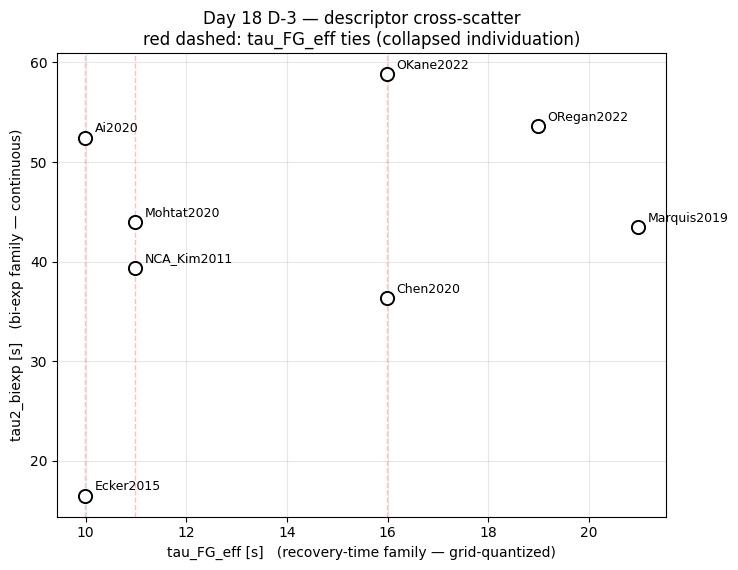


Wrote: figures/day18/day18_d3_scatter_tauFG_vs_tau2biexp.png


In [2]:
# Cell 2B — descriptor forensic audit
# D-1: computational screen for tau_FG_eff quantization (source-code-blind)
# D-3: descriptor cross-correlation, ties, pairwise inversions
# D-2 (raw relaxation overlay) → Cell 2C, gated on trace file path confirmation.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
from scipy.stats import spearmanr, kendalltau

ROOT = Path("/Users/louislu/pybamm-dcac-superimposed")
DATA = ROOT / "data"
FIG  = ROOT / "figures" / "day18"
FIG.mkdir(parents=True, exist_ok=True)

src = DATA / "day17_step1_tau_ref_descriptor_matrix.csv"
df17 = pd.read_csv(src).sort_values("tau_FG_eff").reset_index(drop=True)
print(f"Source: {src.name}  ({len(df17)} sets, {len(df17.columns)} cols)\n")

# =============================================================================
# D-1 — Quantization screen for tau_FG_eff
# =============================================================================
print("=" * 72)
print("D-1: tau_FG_eff quantization screen (computational, source-code-blind)")
print("=" * 72)

fg = df17["tau_FG_eff"].to_numpy()
n         = len(fg)
n_unique  = len(np.unique(fg))
tie_frac  = 1.0 - n_unique / n

print(f"\nValues:               {fg.tolist()}")
print(f"Unique values:        {n_unique} of {n}")
print(f"Tie fraction:         {tie_frac:.3f}")

# Tied-group enumeration
print("Tied groups:")
for v in np.unique(fg):
    members = df17.loc[df17["tau_FG_eff"] == v, "param_set"].tolist()
    if len(members) > 1:
        print(f"  tau_FG_eff = {v:.2f} s  →  {members}")

# (1) Grid-alignment test: val ≡ k·Δt (mod 0) for some Δt
print("\nGrid-alignment test  (max | val/Δt − round(val/Δt) | × Δt):")
for dt in [1.0, 0.5, 0.1, 0.05, 0.005]:
    rem      = (fg / dt) - np.round(fg / dt)
    max_dev  = float(np.max(np.abs(rem)) * dt)
    flag     = "CONSISTENT" if max_dev < 1e-3 else "rejected"
    print(f"  Δt = {dt:6.3f} s  →  max deviation = {max_dev:.4f} s   [{flag}]")

# (2) Phase test: fractional parts cluster around a fixed offset?
frac = fg - np.floor(fg)
print(f"\nFractional parts:     {frac.tolist()}")
print(f"  std (phase tightness): {frac.std():.4e} s")
print(f"  mean (≈ phase φ):      {frac.mean():.4f} s")

# (3) Integer-step on unique-value gaps
gaps     = np.diff(np.sort(np.unique(fg)))
all_int  = bool(np.allclose(gaps, np.round(gaps), atol=1e-3))
print(f"\nUnique-value gaps (s): {gaps.tolist()}")
print(f"All integer multiples of 1 s within 1 ms? {all_int}")

# (4) Match to declared Day 17 HPPC sampling protocol
print(f"\nDay 17 HPPC relaxation sampling (declared by user):")
print(f"  t ∈ [0, 5] s : 5 ms  (200 Hz)")
print(f"  t > 5 s      : 1 s   (1 Hz)")
print(f"tau_FG_eff range: [{fg.min():.2f}, {fg.max():.2f}] s   "
      f"→ fully inside 1-Hz regime.")
print(f"Predicted artifact: 1-s grid quantization with phase φ ≈ {frac.mean():.2f} s.")

verdict_d1 = bool(
    tie_frac > 0
    and frac.std() < 0.05
    and all_int
)
print(f"\nD-1 computational verdict: tau_FG_eff is grid-quantized on Δt = 1 s  →  {verdict_d1}")
print(f"D-1 manual follow-up: read Day 17 source for tau_FG_eff definition")
print(f"  Expected pattern: 'first time on relaxation grid where recovery ≥ threshold'.")

# =============================================================================
# D-3 — Descriptor cross-correlation, ties, pairwise inversions
# =============================================================================
print("\n" + "=" * 72)
print("D-3: descriptor cross-correlation diagnostics")
print("=" * 72)

descriptor_cols = ["tau_FG_eff", "tau2_biexp", "tau2_secondary_60s", "tau_tail"]
for opt in ["t95_s", "t99_s"]:
    if opt in df17.columns:
        descriptor_cols.append(opt)

descriptors = {c: df17[c].to_numpy() for c in descriptor_cols}

# Tie / unique counts
print("\nUnique-value count per descriptor (n=8):")
for name, vals in descriptors.items():
    nu = len(np.unique(vals))
    print(f"  {name:<22s}  unique = {nu}/{len(vals)}   tie_fraction = {1 - nu/len(vals):.3f}")

# Pairwise concordance against tau_FG_eff
def pair_breakdown(a, b):
    """Return (concordant, discordant, tied_in_a, tied_in_b, tied_in_both)."""
    conc = disc = ta = tb = tab = 0
    for i, j in combinations(range(len(a)), 2):
        da = np.sign(a[i] - a[j])
        db = np.sign(b[i] - b[j])
        if da == 0 and db == 0:
            tab += 1
        elif da == 0:
            ta += 1
        elif db == 0:
            tb += 1
        elif da == db:
            conc += 1
        else:
            disc += 1
    return conc, disc, ta, tb, tab

ref = descriptors["tau_FG_eff"]
print(f"\nPairwise correlation vs tau_FG_eff (28 pairs total):")
hdr = f"  {'descriptor':<22s}  {'ρ':>7s}  {'τ-b':>7s}  "\
      f"{'conc':>5s}  {'disc':>5s}  {'tied_FG':>8s}  {'tied_y':>7s}  {'tied_both':>10s}"
print(hdr)
print("  " + "-" * (len(hdr) - 2))
for name, vals in descriptors.items():
    if name == "tau_FG_eff":
        continue
    rho, _   = spearmanr(ref, vals)
    tau_b, _ = kendalltau(ref, vals)
    c, d, ta, tb, tab = pair_breakdown(ref, vals)
    print(f"  {name:<22s}  {rho:>+7.3f}  {tau_b:>+7.3f}  "
          f"{c:>5d}  {d:>5d}  {ta:>8d}  {tb:>7d}  {tab:>10d}")

# Highlight: how do tau_FG_eff-tied pairs rank under other descriptors?
print(f"\nWithin-tie spread under non-quantized descriptors:")
for v in np.unique(ref):
    if (ref == v).sum() <= 1:
        continue
    members = df17.loc[df17["tau_FG_eff"] == v, "param_set"].tolist()
    print(f"\n  tau_FG_eff = {v:.2f} s ties: {members}")
    for d_name in ["tau2_biexp", "tau2_secondary_60s", "tau_tail"]:
        if d_name not in df17.columns:
            continue
        sub = df17.loc[df17["tau_FG_eff"] == v, d_name].to_numpy()
        ratio = float(sub.max() / sub.min()) if sub.min() > 0 else float("inf")
        print(f"    {d_name:<22s}  values = {sub.tolist()}   max/min = {ratio:.2f}×")

# =============================================================================
# Visualization — scatter tau_FG_eff vs tau2_biexp
# =============================================================================
fig, ax = plt.subplots(figsize=(7.5, 5.8))
x = df17["tau_FG_eff"].to_numpy()
y = df17["tau2_biexp"].to_numpy()

# Mark tied tau_FG_eff columns
for v in np.unique(x):
    if (x == v).sum() > 1:
        ax.axvline(v, color="red", alpha=0.25, linestyle="--", zorder=1, lw=1)

ax.scatter(x, y, s=90, edgecolor="black", facecolor="white", linewidth=1.4, zorder=3)
for _, r in df17.iterrows():
    ax.annotate(r["param_set"], (r["tau_FG_eff"], r["tau2_biexp"]),
                xytext=(7, 4), textcoords="offset points", fontsize=9)

ax.set_xlabel("tau_FG_eff [s]   (recovery-time family — grid-quantized)")
ax.set_ylabel("tau2_biexp [s]   (bi-exp family — continuous)")
ax.set_title("Day 18 D-3 — descriptor cross-scatter\n"
             "red dashed: tau_FG_eff ties (collapsed individuation)")
ax.grid(alpha=0.3)
plt.tight_layout()

fig_path = FIG / "day18_d3_scatter_tauFG_vs_tau2biexp.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"\nWrote: {fig_path.relative_to(ROOT)}")

Loading: day17_step1_relaxation_curves_long.csv.gz
Rows: 12,768   Columns (4): ['param_set', 'chem_tag', 't_relax_s', 'V_V']

param_set              chem_tag  t_relax_s      V_V
   Ai2020 Enertech LCO/graphite     -0.020 3.645688
   Ai2020 Enertech LCO/graphite     -0.015 3.645683
   Ai2020 Enertech LCO/graphite     -0.010 3.645678
   Ai2020 Enertech LCO/graphite     -0.005 3.645674
   Ai2020 Enertech LCO/graphite      0.000 3.645670
   Ai2020 Enertech LCO/graphite      0.005 3.645666
   Ai2020 Enertech LCO/graphite      0.010 3.645663
   Ai2020 Enertech LCO/graphite      0.015 3.645659

Resolved: set='param_set'  time='t_relax_s'  voltage='V_V'
Optional: pulse=None

Time-axis alignment check (necessary for safe overlay):
  Global TIME_COL min = -0.0200 s
  Global TIME_COL max = 599.9800 s
  First 3 time points per set:
    Ai2020                   [-0.02, -0.015, -0.01]
    Chen2020                 [-0.02, -0.015, -0.01]
    Ecker2015                [-0.02, -0.015, -0.01]
    Marquis2

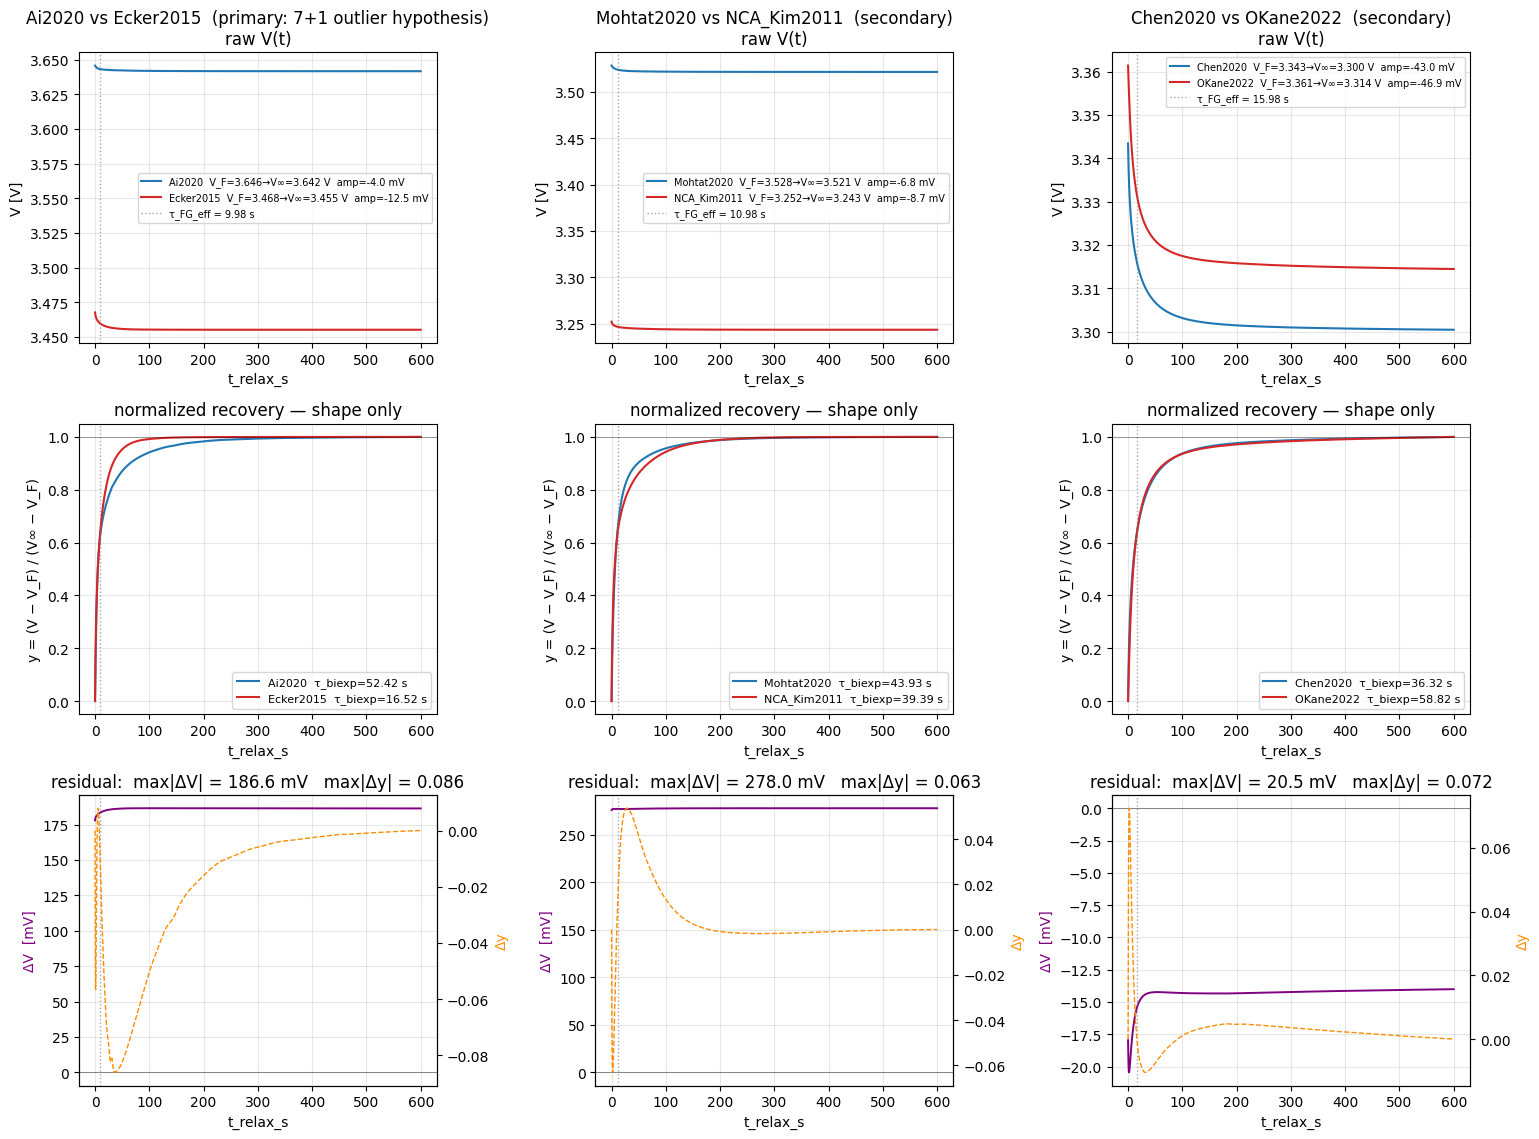


Wrote: figures/day18/day18_d2_tiedpair_relaxation_overlay.png

Cell 2D scope

Answers:
  Did tau_FG_eff fold real V(t) shape differences within tied pairs?
  → If Row 1 (normalized recovery) shows two curves diverging mid-trajectory:
     yes, tau_FG_eff missed real shape differences. Folding confirmed.
  → If Row 1 curves overlap and Row 0 differs only in amplitude:
     tau_FG_eff missed amplitude differences (which it shouldn't, since it's a
     time descriptor) — but biexp tau differences may then be amplitude-driven
     fitting artifacts; downstream biexp audit becomes more important.

Does NOT answer:
  Whether tau2_biexp is correctly fit on these curves.
  Would require: biexp residual, R²/RMSE, semilog ln(1−y) linearity,
                 remaining-fraction double-exp decomposition.
  Defer to a separate Cell 2E (biexp-fit audit) if Cell 2C selects Route 1.



In [4]:
# Cell 2D — D-2: raw + normalized relaxation overlay for tau_FG_eff-tied pairs
# Conditional: run if Cell 2C selects Route 1 (bi-exp-main) or Route 3 (diagnostic).
#
# Scope:
#   ANSWERS:    Did tau_FG_eff fold real V(t) shape differences within tied pairs?
#               Evidence = visible normalized-recovery divergence in Row 2.
#   DOES NOT ANSWER: Whether tau2_biexp is correctly fit on these traces.
#               (Requires biexp residual / R² / semilog audit — separate cell.)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path("/Users/louislu/pybamm-dcac-superimposed")
DATA = ROOT / "data"
FIG  = ROOT / "figures" / "day18"
FIG.mkdir(parents=True, exist_ok=True)

trace_path = DATA / "day17_step1_relaxation_curves_long.csv.gz"
print(f"Loading: {trace_path.name}")
df = pd.read_csv(trace_path)
print(f"Rows: {len(df):,}   Columns ({len(df.columns)}): {list(df.columns)}\n")
print(df.head(8).to_string(index=False))

# ---- column resolution -------------------------------------------------------
def find(df, candidates, label, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"No {label} column among {candidates}; available: {list(df.columns)}")
    return None

SET_COL   = find(df, ["param_set", "set", "cell"],                      "set")
TIME_COL  = find(df, ["t_from_F_s", "t_rel_from_F_s", "t_F_s",
                      "t_relax_s", "t_rel_s", "time_s", "t_s", "time", "t"],
                 "time")
VOLT_COL  = find(df, ["V_V", "V", "voltage_V", "voltage", "U_V", "U"],  "voltage")
PULSE_COL = find(df, ["pulse_idx", "pulse", "pulse_id"], "pulse", required=False)

print(f"\nResolved: set={SET_COL!r}  time={TIME_COL!r}  voltage={VOLT_COL!r}")
print(f"Optional: pulse={PULSE_COL!r}")

# ---- F-relative / step-relative consistency check ---------------------------
print("\nTime-axis alignment check (necessary for safe overlay):")
print(f"  Global TIME_COL min = {df[TIME_COL].min():.4f} s")
print(f"  Global TIME_COL max = {df[TIME_COL].max():.4f} s")
print("  First 3 time points per set:")
for s, g in df.groupby(SET_COL):
    head_t = g.sort_values(TIME_COL)[TIME_COL].head(3).tolist()
    print(f"    {s:<24s} {[round(t, 4) for t in head_t]}")

first_t = df.groupby(SET_COL)[TIME_COL].min()
spread = float(first_t.max() - first_t.min())
print(f"  Spread of per-set first-time-points: {spread:.4f} s")
if spread < 0.1:
    if abs(first_t.iloc[0]) < 0.1:
        print(f"  → axis is F-relative with a short pre-F guard window "
              f"(t_min = {first_t.iloc[0]:.3f} s).")
    else:
        print(f"  → axis is step-relative with shared origin (all sets start near "
              f"t = {first_t.iloc[0]:.3f} s). Overlay is safe.")
else:
    print(f"  → axis NOT shared. Overlay would misalign early-time region.")
assert spread < 0.1, (
    f"Time-axis origin not shared across sets (spread = {spread:.4f} s). "
    f"Resolve column convention before plotting. Available columns: {list(df.columns)}"
)

# ---- drop pre-F guard samples + defensive dedup -----------------------------
# V_F must be voltage at the F point (t = 0), not at t = -0.020 s where the
# cell is still on the pulse tail. Use -1e-12 epsilon for float-safe ">= 0".
pre_rows = int((df[TIME_COL] < 0).sum())
print(f"\nPre-F guard samples detected: {pre_rows:,}")
df = df[df[TIME_COL] >= -1e-12].copy()
print(f"Kept post-F samples only: rows = {len(df):,}")

# Defensive dedup on (set, time): collapses any accidental duplicate timestamps
# by averaging V; preserves chem_tag metadata if the column is present.
agg_dict = {VOLT_COL: "mean"}
if "chem_tag" in df.columns:
    agg_dict["chem_tag"] = "first"

before = len(df)
df = (df.sort_values([SET_COL, TIME_COL])
        .groupby([SET_COL, TIME_COL], as_index=False)
        .agg(agg_dict))
after = len(df)
if before != after:
    print(f"Dedup collapsed {before - after} duplicate (set, t) rows.")

# Per-set row-count sanity
per_set = df.groupby(SET_COL).size()
print(f"Rows per set: min = {per_set.min()}, max = {per_set.max()}, "
      f"std = {per_set.std():.1f}")
assert per_set.min() > 100, (
    f"After filter some set has < 100 rows ({per_set.idxmin()} = {per_set.min()}). "
    f"Investigate before plotting."
)

# ---- single-pulse selection (defensive; no-op when PULSE_COL is None) -------
if PULSE_COL and df[PULSE_COL].nunique() > 1:
    keep = sorted(df[PULSE_COL].unique())[0]
    df = df[df[PULSE_COL] == keep].copy()
    print(f"\nSelected first pulse: {PULSE_COL}={keep}, rows now = {len(df):,}")

# ---- tied-pair tau values (with consistency assertion) ----------------------
tau_df = pd.read_csv(DATA / "day17_step1_tau_ref_descriptor_matrix.csv").set_index("param_set")

TIED_PAIRS = [
    ("Ai2020",     "Ecker2015",   "primary: 7+1 outlier hypothesis"),
    ("Mohtat2020", "NCA_Kim2011", "secondary"),
    ("Chen2020",   "OKane2022",   "secondary"),
]

# ---- 3-row plot: raw / normalized / residual --------------------------------
fig, axes = plt.subplots(3, 3, figsize=(15.5, 11.5))

for col, (set_a, set_b, tag) in enumerate(TIED_PAIRS):
    sub_a = df[df[SET_COL] == set_a].sort_values(TIME_COL).reset_index(drop=True)
    sub_b = df[df[SET_COL] == set_b].sort_values(TIME_COL).reset_index(drop=True)

    if len(sub_a) == 0 or len(sub_b) == 0:
        for r in range(3):
            axes[r, col].text(0.5, 0.5,
                f"missing: {set_a if len(sub_a)==0 else set_b}",
                ha="center", transform=axes[r, col].transAxes)
        continue

    # Programmatic tau_FG_eff annotation with consistency assertion
    tau_a = float(tau_df.loc[set_a, "tau_FG_eff"])
    tau_b = float(tau_df.loc[set_b, "tau_FG_eff"])
    assert np.isclose(tau_a, tau_b), (
        f"Tied-pair mismatch: {set_a}={tau_a}, {set_b}={tau_b}. "
        f"Pair list out of sync with descriptor matrix."
    )
    tau_fg = tau_a

    # Restrict to overlap region — kills np.interp edge-tile artifact
    t_lo = max(sub_a[TIME_COL].min(), sub_b[TIME_COL].min())
    t_hi = min(sub_a[TIME_COL].max(), sub_b[TIME_COL].max())
    sub_a = sub_a[(sub_a[TIME_COL] >= t_lo) & (sub_a[TIME_COL] <= t_hi)].reset_index(drop=True)
    sub_b = sub_b[(sub_b[TIME_COL] >= t_lo) & (sub_b[TIME_COL] <= t_hi)].reset_index(drop=True)
    print(f"\n{set_a} vs {set_b}: overlap [{t_lo:.3f}, {t_hi:.3f}] s "
          f"(n_a={len(sub_a)}, n_b={len(sub_b)})")

    t_a, V_a = sub_a[TIME_COL].to_numpy(), sub_a[VOLT_COL].to_numpy()
    t_b, V_b = sub_b[TIME_COL].to_numpy(), sub_b[VOLT_COL].to_numpy()

    # F-point and pseudo-asymptote
    # NOTE: V_inf = last sample. Bias ~14% when tau_tail approaches the relax window.
    V_F_a, V_inf_a = float(V_a[0]), float(V_a[-1])
    V_F_b, V_inf_b = float(V_b[0]), float(V_b[-1])
    amp_a = V_inf_a - V_F_a
    amp_b = V_inf_b - V_F_b

    # Normalized recovery: 0 at F, 1 at pseudo-asymptote (sign-symmetric)
    y_a = (V_a - V_F_a) / amp_a if amp_a != 0 else np.zeros_like(V_a)
    y_b = (V_b - V_F_b) / amp_b if amp_b != 0 else np.zeros_like(V_b)

    # Residual on set-A's time grid, masked to within set-B's actual range
    t_common = t_a
    V_b_on_a = np.interp(t_common, t_b, V_b)
    y_b_on_a = np.interp(t_common, t_b, y_b)
    in_b_range = (t_common >= t_b.min()) & (t_common <= t_b.max())

    # ---- Row 0: raw V(t) -----------------------------------------------------
    ax = axes[0, col]
    ax.plot(t_a, V_a, lw=1.5, color="C0",
            label=f"{set_a}  V_F={V_F_a:.3f}→V∞={V_inf_a:.3f} V  amp={amp_a*1000:+.1f} mV")
    ax.plot(t_b, V_b, lw=1.5, color="C3",
            label=f"{set_b}  V_F={V_F_b:.3f}→V∞={V_inf_b:.3f} V  amp={amp_b*1000:+.1f} mV")
    ax.axvline(tau_fg, color="gray", ls=":", lw=1, alpha=0.7,
               label=f"τ_FG_eff = {tau_fg:.2f} s")
    ax.set_xlabel(TIME_COL); ax.set_ylabel("V [V]")
    ax.set_title(f"{set_a} vs {set_b}  ({tag})\nraw V(t)")
    ax.legend(fontsize=7, loc="best"); ax.grid(alpha=0.3)

    # ---- Row 1: normalized recovery (shape only) -----------------------------
    ax2 = axes[1, col]
    ax2.plot(t_a, y_a, lw=1.5, color="C0",
             label=f"{set_a}  τ_biexp={tau_df.loc[set_a, 'tau2_biexp']:.2f} s")
    ax2.plot(t_b, y_b, lw=1.5, color="C3",
             label=f"{set_b}  τ_biexp={tau_df.loc[set_b, 'tau2_biexp']:.2f} s")
    ax2.axvline(tau_fg, color="gray", ls=":", lw=1, alpha=0.7)
    ax2.axhline(1.0, color="black", lw=0.6, alpha=0.4)
    ax2.set_xlabel(TIME_COL); ax2.set_ylabel("y = (V − V_F) / (V∞ − V_F)")
    ax2.set_title("normalized recovery — shape only")
    ax2.legend(fontsize=8, loc="best"); ax2.grid(alpha=0.3)

    # ---- Row 2: residual (raw + normalized, on overlap) ----------------------
    ax3 = axes[2, col]
    dV = (V_a - V_b_on_a)[in_b_range]
    dy = (y_a - y_b_on_a)[in_b_range]
    t_res = t_common[in_b_range]
    ax3.plot(t_res, dV * 1000, lw=1.4, color="purple", label="ΔV [mV] (raw)")
    ax3_n = ax3.twinx()
    ax3_n.plot(t_res, dy, lw=1.0, color="darkorange", linestyle="--",
               label="Δy (normalized)")
    ax3.axhline(0, color="black", lw=0.6, alpha=0.5)
    ax3.axvline(tau_fg, color="gray", ls=":", lw=1, alpha=0.7)
    ax3.set_xlabel(TIME_COL)
    ax3.set_ylabel("ΔV  [mV]", color="purple")
    ax3_n.set_ylabel("Δy", color="darkorange")
    ax3.set_title(f"residual:  max|ΔV| = {np.max(np.abs(dV))*1000:.1f} mV   "
                  f"max|Δy| = {np.max(np.abs(dy)):.3f}")
    ax3.grid(alpha=0.3)

plt.tight_layout()
out = FIG / "day18_d2_tiedpair_relaxation_overlay.png"
plt.savefig(out, dpi=150)
plt.show()
print(f"\nWrote: {out.relative_to(ROOT)}")

# ---- scope statement ---------------------------------------------------------
print("\n" + "=" * 72)
print("Cell 2D scope")
print("=" * 72)
print("""
Answers:
  Did tau_FG_eff fold real V(t) shape differences within tied pairs?
  → If Row 1 (normalized recovery) shows two curves diverging mid-trajectory:
     yes, tau_FG_eff missed real shape differences. Folding confirmed.
  → If Row 1 curves overlap and Row 0 differs only in amplitude:
     tau_FG_eff missed amplitude differences (which it shouldn't, since it's a
     time descriptor) — but biexp tau differences may then be amplitude-driven
     fitting artifacts; downstream biexp audit becomes more important.

Does NOT answer:
  Whether tau2_biexp is correctly fit on these curves.
  Would require: biexp residual, R²/RMSE, semilog ln(1−y) linearity,
                 remaining-fraction double-exp decomposition.
  Defer to a separate Cell 2E (biexp-fit audit) if Cell 2C selects Route 1.
""")

In [5]:
# Cell 2C v2 — candidate descriptor eligibility audit
# Per Cell 2B verdict: tau_FG_eff REJECTED_AS_MAIN_PER_SET_REBASING_DESCRIPTOR.
# Cell 2D confirmed real V(t) shape divergence within Ai2020/Ecker2015 tie.
#
# Key principle: F (Ecker2015 7+1 outlier) is DIAGNOSTIC, not a universal gate.
#                Failure of F by recovery-time descriptors does NOT disqualify
#                them as recovery-time-main candidates. F is supportive evidence
#                for Route 1 (bi-exp-main) only.

import json
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import combinations
from scipy.stats import spearmanr, kendalltau

ROOT = Path("/Users/louislu/pybamm-dcac-superimposed")
DATA = ROOT / "data"

src  = DATA / "day17_step1_tau_ref_descriptor_matrix.csv"
df17 = pd.read_csv(src)
TAU_LABEL_S = 11.1

CANDIDATES = ["tau2_biexp", "tau2_secondary_60s", "t95_s", "t99_s", "tau_FG_eff"]
FAMILY = {
    "tau2_biexp":         "bi-exp (long-window)",
    "tau2_secondary_60s": "bi-exp (short-window)",
    "t95_s":              "recovery-time (95%)",
    "t99_s":              "recovery-time (99%)",
    "tau_FG_eff":         "recovery-time (free-grain) — REJECTED",
}
REJECTED = {"tau_FG_eff"}

REJECTION_REASONS_TAUFG = [
    "5 unique values among 8 sets, including three two-member ties",
    "tie fraction = 0.375; parameter-set individuation is collapsed",
    "values align to a 1 s grid with fixed phase ≈ 0.98 s",
    "large within-tie spread under non-quantized descriptors (up to 4.70× in tau2_secondary_60s)",
    "Cell 2D confirms visible normalized-recovery divergence in primary tied pair Ai2020/Ecker2015 (max|Δy|=0.086)",
    "therefore unsuitable for per-set native-frequency rebasing",
]

print("=" * 84)
print("Cell 2C v2 — candidate descriptor eligibility audit")
print("=" * 84)
print(f"Candidates: {CANDIDATES}")
print(f"Rejected (kept for cross-family reference only): {sorted(REJECTED)}")

# =============================================================================
# (A) per-descriptor metrics — float-tolerant uniqueness
# =============================================================================
DECIMAL_PRECISION = 6  # collapse spurious float-precision uniqueness

rows = []
for col in CANDIDATES:
    if col not in df17.columns:
        continue
    v = df17[col].to_numpy().astype(float)
    v_round = np.round(v, DECIMAL_PRECISION)
    n  = len(v_round)
    nu = len(np.unique(v_round))
    f_ratio = TAU_LABEL_S / v
    rows.append({
        "descriptor":         col,
        "family":             FAMILY[col],
        "rejected":           col in REJECTED,
        "unique":             int(nu),
        "tie_fraction":       float(1 - nu / n),
        "tau_min_s":          float(v.min()),
        "tau_max_s":          float(v.max()),
        "tau_max_min":        float(v.max() / v.min()),
        "f_ratio_min":        float(f_ratio.min()),
        "f_ratio_max":        float(f_ratio.max()),
        "f_ratio_span":       float(f_ratio.max() / f_ratio.min()),
    })
audit = pd.DataFrame(rows)
print(f"\n--- (A) per-descriptor metrics (uniqueness rounded to {DECIMAL_PRECISION} decimals) ---")
with pd.option_context("display.max_columns", None, "display.width", 220,
                      "display.float_format", "{:.4g}".format):
    print(audit.to_string(index=False))

# =============================================================================
# (B) pairwise correlation matrix
# =============================================================================
rho_mat = pd.DataFrame(np.eye(len(CANDIDATES)), index=CANDIDATES, columns=CANDIDATES)
tau_mat = pd.DataFrame(np.eye(len(CANDIDATES)), index=CANDIDATES, columns=CANDIDATES)
for a, b in combinations(CANDIDATES, 2):
    rho, _ = spearmanr(df17[a], df17[b])
    tk,  _ = kendalltau(df17[a], df17[b])
    rho_mat.loc[a, b] = rho_mat.loc[b, a] = rho
    tau_mat.loc[a, b] = tau_mat.loc[b, a] = tk

print("\n--- (B) pairwise Spearman ρ -------------------------------------------")
with pd.option_context("display.float_format", "{:+.3f}".format, "display.width", 200):
    print(rho_mat.to_string())
print("\n--- (B) pairwise Kendall τ-b ------------------------------------------")
with pd.option_context("display.float_format", "{:+.3f}".format, "display.width", 200):
    print(tau_mat.to_string())

# =============================================================================
# (C) within-family + true cross-family consistency
# =============================================================================
RECOVERY = ["t95_s", "t99_s"]
BIEXP    = ["tau2_biexp", "tau2_secondary_60s"]

def within_family(cols):
    """Spearman ρ for all pairs within the given family."""
    if len(cols) < 2:
        return float("nan"), float("nan"), []
    rs = [spearmanr(df17[a], df17[b])[0] for a, b in combinations(cols, 2)]
    return float(np.mean(rs)), float(np.min(rs)), [float(r) for r in rs]

def cross_family(A, B):
    """Spearman ρ for cross-family pairs only (no within-family contamination)."""
    rs = [spearmanr(df17[a], df17[b])[0] for a in A for b in B]
    return float(np.mean(rs)), float(np.min(rs)), [float(r) for r in rs]

mean_rec, min_rec, pairs_rec = within_family(RECOVERY)
mean_bex, min_bex, pairs_bex = within_family(BIEXP)
mean_x,   min_x,   pairs_x   = cross_family(RECOVERY, BIEXP)

print("\n--- (C) family consistency --------------------------------------------")
print(f"Within RECOVERY {RECOVERY}:           mean ρ = {mean_rec:+.3f}   min ρ = {min_rec:+.3f}")
print(f"Within BIEXP    {BIEXP}: mean ρ = {mean_bex:+.3f}   min ρ = {min_bex:+.3f}")
print(f"True cross-family RECOVERY × BIEXP   ({len(pairs_x)} pairs):")
print(f"                                       mean ρ = {mean_x:+.3f}   min ρ = {min_x:+.3f}")
print("  Thresholds: within-family min ρ ≥ 0.9 (bi-exp) / ≥ 0.7 (recovery, only 2 members)")
print("              cross-family min ρ ≥ 0.5 (otherwise families are mutually incompatible)")

# =============================================================================
# (D) Uinf-stability proxy: t99_s / t95_s ratio (per-set)
#     Governs t99_s sensitivity-role reliability, NOT t95_s eligibility.
# =============================================================================
print("\n--- (D) Uinf-stability proxy: t99_s / t95_s per set -------------------")
print("       (governs t99_s sensitivity role only; t95_s eligibility unaffected)")
t99_role = None
spread = float("nan")
median_ratio = float("nan")

if "t99_s" in df17.columns and "t95_s" in df17.columns:
    ratio = df17["t99_s"].to_numpy() / df17["t95_s"].to_numpy()
    rep = df17[["param_set"]].copy()
    rep["t95_s"]   = df17["t95_s"]
    rep["t99_s"]   = df17["t99_s"]
    rep["t99/t95"] = ratio
    with pd.option_context("display.float_format", "{:.3f}".format, "display.width", 140):
        print(rep.sort_values("t99/t95").to_string(index=False))
    median_ratio = float(np.median(ratio))
    spread       = float(ratio.max() / ratio.min())
    print(f"  Median t99/t95 ratio:    {median_ratio:.3f}")
    print(f"  Range:                   {float(ratio.min()):.3f} – {float(ratio.max()):.3f}")
    print(f"  Spread (max/min):        {spread:.3f}")
    if spread < 1.5:
        t99_role = "stable_sensitivity"
        print(f"  → t99_s role = STABLE_SENSITIVITY (spread < 1.5)")
    else:
        t99_role = "tail_contaminated_audit_only"
        print(f"  → t99_s role = TAIL_CONTAMINATED_AUDIT_ONLY (spread ≥ 1.5)")
    print("  Note: t95_s eligibility is independent of this t99_s classification.")
else:
    print("  [skip] t95_s or t99_s missing")

# =============================================================================
# (E) frequency-collision risk — n_tau-INVARIANT
# =============================================================================
print("\n--- (E) frequency-collision risk (relative Δf < 1%) -------------------")
print("      Note: relative frequency collisions are n_tau-INVARIANT because")
print("            f(nτ) = 1/(2π·n·τ); the n factor cancels in Δf/f.")
THRESH_REL = 0.01
collisions_summary = {}
for col in CANDIDATES:
    if col not in df17.columns:
        continue
    v = df17[col].to_numpy()
    sets = df17["param_set"].astype(str).to_numpy()
    f = 1.0 / v   # n cancels in relative diff; absolute scale irrelevant
    pairs = []
    for i, j in combinations(range(len(v)), 2):
        rel = abs(f[i] - f[j]) / max(f[i], f[j])
        if rel < THRESH_REL:
            pairs.append((sets[i], sets[j], float(rel)))
    collisions_summary[col] = {
        "n_close_pairs": len(pairs),
        "pairs":         [{"a": a, "b": b, "rel_df": r} for a, b, r in pairs],
    }
    if pairs:
        print(f"  {col}: {len(pairs)} close pair(s)")
        for a, b, r in pairs:
            print(f"    {a} ↔ {b}   relative Δf = {r*100:.2f}%")
    else:
        print(f"  {col}: no close pairs (clean individuation)")

# =============================================================================
# (F) DIAGNOSTIC ONLY: 7+1 (Ecker2015 standalone) structure under each candidate
#     Does NOT gate eligibility for any route. Supportive evidence for Route 1.
# =============================================================================
print("\n--- (F) Ecker2015 7+1 outlier structure — DIAGNOSTIC, not gate --------")
THR_GAP, THR_CONC = 2.0, 0.8
ecker_mask = df17["param_set"].astype(str).str.contains("Ecker2015", case=False, na=False)
outlier_summary = {}

for col in CANDIDATES:
    if col not in df17.columns or int(ecker_mask.sum()) != 1:
        outlier_summary[col] = {"applicable": False, "reason": "ecker_not_unique"}
        continue
    v = df17[col].to_numpy()
    e_val = float(df17.loc[ecker_mask, col].iloc[0])
    n_equal_e = int(np.isclose(v, e_val).sum())
    rest = np.sort(v[~ecker_mask])

    is_min = bool(np.isclose(e_val, v.min()))
    is_max = bool(np.isclose(e_val, v.max()))
    is_tied_min = is_min and n_equal_e > 1
    is_tied_max = is_max and n_equal_e > 1

    if is_tied_min or is_tied_max:
        side = "tied_min" if is_tied_min else "tied_max"
        print(f"  {col:<22s}  Ecker2015 = {side:<10s}   "
              f"({n_equal_e} sets share value {e_val:.4g}) → activated = False")
        outlier_summary[col] = {
            "applicable":    True,
            "ecker_side":    side,
            "n_equal_ecker": n_equal_e,
            "activated":     False,
        }
        continue

    if is_min or is_max:
        side = "min" if is_min else "max"
        gap        = (rest[0] - e_val) if is_min else (e_val - rest[-1])
        median_gap = float(np.median(np.diff(rest)))
        gap_ratio  = (gap / median_gap) if median_gap > 0 else float("inf")
        cluster_mm = float(rest.max() / rest.min())
        all8_mm    = float(v.max() / v.min())
        conc       = cluster_mm / all8_mm
        activated  = bool(gap_ratio > THR_GAP and conc < THR_CONC)
        print(f"  {col:<22s}  Ecker2015 = {side:<10s}   "
              f"gap_ratio = {gap_ratio:5.2f}   conc = {conc:.3f}   → activated = {activated}")
        outlier_summary[col] = {
            "applicable":   True,
            "ecker_side":   side,
            "gap_ratio":    float(gap_ratio),
            "concentration": float(conc),
            "activated":    bool(activated),
        }
    else:
        rank = int(np.argsort(np.argsort(v))[ecker_mask][0]) + 1
        print(f"  {col:<22s}  Ecker2015 rank {rank}/8 (interior — 7+1 not applicable)")
        outlier_summary[col] = {"applicable": False, "ecker_side": "interior", "rank": rank}

# =============================================================================
# Persist eligibility table + decision sidecar
# =============================================================================
audit_path = DATA / "day18_step0b_descriptor_eligibility.csv"
audit.to_csv(audit_path, index=False)

decision = {
    "tau_FG_eff_verdict":           "REJECTED_AS_MAIN_PER_SET_REBASING_DESCRIPTOR",
    "tau_FG_eff_rejection_reasons": REJECTION_REASONS_TAUFG,
    "candidates":                   [c for c in CANDIDATES if c not in REJECTED],
    "thresholds": {
        "frequency_collision_relative":     THRESH_REL,
        "outlier_gap_ratio_min":            THR_GAP,
        "outlier_concentration_max":        THR_CONC,
        "within_family_min_rho_biexp":      0.9,
        "within_family_min_rho_recovery":   0.7,
        "cross_family_min_rho":             0.5,
        "uinf_stability_spread_threshold":  1.5,
        "decimal_precision_for_uniqueness": DECIMAL_PRECISION,
    },
    "within_family_consistency": {
        "recovery_time": {"mean_rho": mean_rec, "min_rho": min_rec,
                          "members": RECOVERY, "pair_rhos": pairs_rec},
        "biexp":         {"mean_rho": mean_bex, "min_rho": min_bex,
                          "members": BIEXP,    "pair_rhos": pairs_bex},
    },
    "cross_family_consistency": {
        "recovery_vs_biexp": {
            "mean_rho":  mean_x,
            "min_rho":   min_x,
            "n_pairs":   len(pairs_x),
            "pair_rhos": pairs_x,
        },
    },
    "t99_role_classification":   t99_role,
    "t99_t95_spread_max_min":    spread,
    "t99_t95_median_ratio":      median_ratio,
    "frequency_collisions":      collisions_summary,
    "outlier_structure":         outlier_summary,
    "outlier_structure_role":    "DIAGNOSTIC (Route-1 supportive, not universal gate)",
    "route_decision":            "PENDING_HUMAN_REVIEW",
}
decision_path = DATA / "day18_step0b_descriptor_decision.json"
decision_path.write_text(json.dumps(decision, indent=2, default=str))

print(f"\nWrote: {audit_path.relative_to(ROOT)}")
print(f"Wrote: {decision_path.relative_to(ROOT)}")

# =============================================================================
# Route decision criteria (revised — F is supportive, not gating)
# =============================================================================
print("\n" + "=" * 84)
print("Route decision criteria — apply after reviewing (A)–(F) above")
print("=" * 84)
print("""
Route 1 (bi-exp-main):
  Slots:    main = tau2_biexp
            sensitivity = tau2_secondary_60s
            recovery audit = t95_s
  Eligible iff ALL of:
    1. tau2_biexp has 8/8 unique values
    2. tau2_biexp has no close frequency collisions (relative Δf < 1%)
    3. bi-exp within-family ρ ≥ 0.9
    4. cross-family RECOVERY × BIEXP min ρ ≥ 0.5
    5. tau2_biexp fit quality passes a separate Cell 2E biexp-fit audit
       (Cell 2D Pair-3 anomaly — Chen2020/OKane2022 — flagged this need)
  F (Ecker2015 7+1) is SUPPORTIVE only; not necessary, not sufficient.

Route 2 (recovery-time-main):
  Slots:    main = t95_s
            sensitivity = t99_s (downgraded to audit-only if D classifies it as
                                 tail-contaminated)
            bi-exp audit = tau2_biexp
  Eligible iff ALL of:
    1. t95_s has 8/8 unique values
    2. t95_s has no close frequency collisions
    3. recovery within-family ρ(t95, t99) ≥ 0.7
       (looser than bi-exp 0.9 because only 2 family members)
    4. cross-family RECOVERY × BIEXP min ρ ≥ 0.5
    5. t95_s f_ratio_span is operational (no near-zero or extreme frequencies)
  F (Ecker2015 7+1) is NOT REQUIRED. Recovery descriptors may legitimately
  fail F without that disqualifying them as recovery-time-main.

Route 3 (descriptor-family diagnostic, no DCAC sims):
  Triggered iff EITHER:
    - No descriptor passes uniqueness + collision + within-family checks, OR
    - cross-family min ρ < 0.5 (RECOVERY and BIEXP rank sets incompatibly,
      making per-set frequency rebasing under-identified across descriptor families)
  Day 18 outcome statement:
    'Native time-scale rebasing is descriptor-family-dependent under the tested
     parameter set; the Day-16 fixed-label null cannot be cleanly attributed to
     fixed-label frequency alone within the current descriptor set.'
""")
print(f"Route decision recorded as PENDING_HUMAN_REVIEW in:")
print(f"  {decision_path.relative_to(ROOT)}")
print("After review, manually edit JSON: route_decision → 'ROUTE_1' / 'ROUTE_2' / 'ROUTE_3'")

Cell 2C v2 — candidate descriptor eligibility audit
Candidates: ['tau2_biexp', 'tau2_secondary_60s', 't95_s', 't99_s', 'tau_FG_eff']
Rejected (kept for cross-family reference only): ['tau_FG_eff']

--- (A) per-descriptor metrics (uniqueness rounded to 6 decimals) ---
        descriptor                                family  rejected  unique  tie_fraction  tau_min_s  tau_max_s  tau_max_min  f_ratio_min  f_ratio_max  f_ratio_span
        tau2_biexp                  bi-exp (long-window)     False       8             0      16.52      58.82        3.561       0.1887        0.672         3.561
tau2_secondary_60s                 bi-exp (short-window)     False       8             0      5.099      36.28        7.115       0.3059        2.177         7.115
             t95_s                   recovery-time (95%)     False       8             0      48.98        143        2.919      0.07763       0.2266         2.919
             t99_s                   recovery-time (99%)     False       8  

In [6]:
# Cell 2C v3 — candidate descriptor eligibility audit
# v3 fix: t95_s and t99_s are RECOVERY TIMES, not time constants.
#         Convert to equivalent τ via mono-exponential recovery-fraction inversion:
#           y(t) = 1 − exp(−t/τ)  ⇒  τ_eq = t_p / [−ln(1−p)]
#         tau95_eq = t95_s / 2.9957  (since −ln(0.05) ≈ 2.9957)
#         tau99_eq = t99_s / 4.6052  (since −ln(0.01) ≈ 4.6052)
# This restores dimensional consistency with tau2_biexp / tau2_secondary_60s
# so that f = 1/(2π·n·τ) gives physically comparable rebasing frequencies.
#
# Spearman ρ values are rank-invariant under this transform; v3 numerical ρ
# matches v2 exactly. The transform changes magnitudes, scale alignment, and
# the physical interpretation of (D).

import json
import numpy as np
import pandas as pd
from pathlib import Path
from itertools import combinations
from scipy.stats import spearmanr, kendalltau

ROOT = Path("/Users/louislu/pybamm-dcac-superimposed")
DATA = ROOT / "data"

src  = DATA / "day17_step1_tau_ref_descriptor_matrix.csv"
df17 = pd.read_csv(src)
TAU_LABEL_S = 11.1

# ---- recovery-time → equivalent-tau conversion (mono-exp inversion) ---------
TAU95_FACTOR = -np.log(1 - 0.95)   # 2.9957
TAU99_FACTOR = -np.log(1 - 0.99)   # 4.6052
print(f"Conversion factors: TAU95_FACTOR = {TAU95_FACTOR:.4f}, "
      f"TAU99_FACTOR = {TAU99_FACTOR:.4f}")
df17["tau95_eq"] = df17["t95_s"] / TAU95_FACTOR
df17["tau99_eq"] = df17["t99_s"] / TAU99_FACTOR

CANDIDATES = ["tau2_biexp", "tau2_secondary_60s", "tau95_eq", "tau99_eq", "tau_FG_eff"]
FAMILY = {
    "tau2_biexp":         "bi-exp (long-window fit)",
    "tau2_secondary_60s": "bi-exp (short-window fit)",
    "tau95_eq":           "recovery-equivalent τ from t95 (mono-exp inversion)",
    "tau99_eq":           "recovery-equivalent τ from t99 (mono-exp inversion)",
    "tau_FG_eff":         "recovery-time (free-grain) — REJECTED",
}
REJECTED = {"tau_FG_eff"}

REJECTION_REASONS_TAUFG = [
    "5 unique values among 8 sets, including three two-member ties",
    "tie fraction = 0.375; parameter-set individuation is collapsed",
    "values align to a 1 s grid with fixed phase ≈ 0.98 s",
    "large within-tie spread under non-quantized descriptors (up to 4.70× in tau2_secondary_60s)",
    "Cell 2D confirms visible normalized-recovery divergence in primary tied pair Ai2020/Ecker2015 (max|Δy|=0.086)",
    "therefore unsuitable for per-set native-frequency rebasing",
]

print("=" * 84)
print("Cell 2C v3 — candidate descriptor eligibility audit (recovery-eq τ)")
print("=" * 84)
print(f"Candidates: {CANDIDATES}")
print(f"Rejected (kept for cross-family reference only): {sorted(REJECTED)}")

# =============================================================================
# (A) per-descriptor metrics — float-tolerant uniqueness, dimensional τ
# =============================================================================
DECIMAL_PRECISION = 6

rows = []
for col in CANDIDATES:
    if col not in df17.columns:
        continue
    v = df17[col].to_numpy().astype(float)
    v_round = np.round(v, DECIMAL_PRECISION)
    n  = len(v_round)
    nu = len(np.unique(v_round))
    f_ratio = TAU_LABEL_S / v
    rows.append({
        "descriptor":         col,
        "family":             FAMILY[col],
        "rejected":           col in REJECTED,
        "unique":             int(nu),
        "tie_fraction":       float(1 - nu / n),
        "tau_min_s":          float(v.min()),
        "tau_max_s":          float(v.max()),
        "tau_max_min":        float(v.max() / v.min()),
        "f_ratio_min":        float(f_ratio.min()),
        "f_ratio_max":        float(f_ratio.max()),
        "f_ratio_span":       float(f_ratio.max() / f_ratio.min()),
    })
audit = pd.DataFrame(rows)
print(f"\n--- (A) per-descriptor metrics (uniqueness rounded to {DECIMAL_PRECISION} decimals) ---")
with pd.option_context("display.max_columns", None, "display.width", 220,
                      "display.float_format", "{:.4g}".format):
    print(audit.to_string(index=False))
print("\nScale alignment check (tau range comparison):")
for c in CANDIDATES:
    if c in REJECTED:
        continue
    v = df17[c].to_numpy()
    print(f"  {c:<22s}  [{v.min():6.2f}, {v.max():6.2f}] s")

# =============================================================================
# (B) pairwise correlation matrix (rank-invariant; matches v2 exactly)
# =============================================================================
rho_mat = pd.DataFrame(np.eye(len(CANDIDATES)), index=CANDIDATES, columns=CANDIDATES)
tau_mat = pd.DataFrame(np.eye(len(CANDIDATES)), index=CANDIDATES, columns=CANDIDATES)
for a, b in combinations(CANDIDATES, 2):
    rho, _ = spearmanr(df17[a], df17[b])
    tk,  _ = kendalltau(df17[a], df17[b])
    rho_mat.loc[a, b] = rho_mat.loc[b, a] = rho
    tau_mat.loc[a, b] = tau_mat.loc[b, a] = tk

print("\n--- (B) pairwise Spearman ρ (rank-invariant; identical to v2 numerically) ---")
with pd.option_context("display.float_format", "{:+.3f}".format, "display.width", 200):
    print(rho_mat.to_string())
print("\n--- (B) pairwise Kendall τ-b ------------------------------------------")
with pd.option_context("display.float_format", "{:+.3f}".format, "display.width", 200):
    print(tau_mat.to_string())

# =============================================================================
# (C) within-family + true cross-family consistency
# =============================================================================
RECOVERY = ["tau95_eq", "tau99_eq"]
BIEXP    = ["tau2_biexp", "tau2_secondary_60s"]

def within_family(cols):
    if len(cols) < 2:
        return float("nan"), float("nan"), []
    rs = [spearmanr(df17[a], df17[b])[0] for a, b in combinations(cols, 2)]
    return float(np.mean(rs)), float(np.min(rs)), [float(r) for r in rs]

def cross_family(A, B):
    rs = [spearmanr(df17[a], df17[b])[0] for a in A for b in B]
    return float(np.mean(rs)), float(np.min(rs)), [float(r) for r in rs]

mean_rec, min_rec, pairs_rec = within_family(RECOVERY)
mean_bex, min_bex, pairs_bex = within_family(BIEXP)
mean_x,   min_x,   pairs_x   = cross_family(RECOVERY, BIEXP)

print("\n--- (C) family consistency --------------------------------------------")
print(f"Within RECOVERY {RECOVERY}: mean ρ = {mean_rec:+.3f}   min ρ = {min_rec:+.3f}")
print(f"Within BIEXP    {BIEXP}: mean ρ = {mean_bex:+.3f}   min ρ = {min_bex:+.3f}")
print(f"True cross-family RECOVERY × BIEXP   ({len(pairs_x)} pairs):")
print(f"                                       mean ρ = {mean_x:+.3f}   min ρ = {min_x:+.3f}")
print("  Thresholds: within-family min ρ ≥ 0.9 (bi-exp) / ≥ 0.7 (recovery, only 2 members)")
print("              cross-family min ρ ≥ 0.5 (otherwise families are mutually incompatible)")

# =============================================================================
# (D) Mono-exp deviation: tau99_eq / tau95_eq per set
#     v3 reinterpretation: this ratio is a PHYSICAL indicator of multi-exponentiality.
#       = 1.0  → relaxation is mono-exponential
#       > 1.0  → slow tail prolongs the 95→99% region (multi-exp character)
#     It also governs whether tau99_eq is a stable sensitivity descriptor.
# =============================================================================
print("\n--- (D) Mono-exp deviation: tau99_eq / tau95_eq per set ---------------")
print("       (1.0 = pure mono-exp; > 1.0 = multi-exp / slow-tail dominated)")
t99_role = None
spread = float("nan")
median_ratio = float("nan")

ratio = df17["tau99_eq"].to_numpy() / df17["tau95_eq"].to_numpy()
rep = df17[["param_set"]].copy()
rep["tau95_eq"]            = df17["tau95_eq"]
rep["tau99_eq"]            = df17["tau99_eq"]
rep["tau99_eq/tau95_eq"]   = ratio
with pd.option_context("display.float_format", "{:.3f}".format, "display.width", 140):
    print(rep.sort_values("tau99_eq/tau95_eq").to_string(index=False))

median_ratio = float(np.median(ratio))
spread       = float(ratio.max() / ratio.min())
print(f"  Median tau99_eq/tau95_eq:   {median_ratio:.3f}")
print(f"  Range:                      {float(ratio.min()):.3f} – {float(ratio.max()):.3f}")
print(f"  Spread (max/min):           {spread:.3f}")
print(f"  Pure mono-exp would give:   1.000 across all sets")

if spread < 1.5:
    t99_role = "stable_sensitivity"
    print(f"  → tau99_eq role = STABLE_SENSITIVITY (per-set multi-exp variation < 1.5×)")
else:
    t99_role = "tail_dominated_audit_only"
    print(f"  → tau99_eq role = TAIL_DOMINATED_AUDIT_ONLY (per-set multi-exp variation ≥ 1.5×)")
print("  Note: tau95_eq eligibility is independent of this tau99_eq classification.")
print("  Note: deviation from 1.0 is a real physical signal of multi-time-scale relaxation,")
print("        not a noise artifact.")

# =============================================================================
# (E) frequency-collision risk — n_tau-INVARIANT
# =============================================================================
print("\n--- (E) frequency-collision risk (relative Δf < 1%) -------------------")
print("      Note: relative frequency collisions are n_tau-INVARIANT because")
print("            f(nτ) = 1/(2π·n·τ); the n factor cancels in Δf/f.")
THRESH_REL = 0.01
collisions_summary = {}
for col in CANDIDATES:
    if col not in df17.columns:
        continue
    v = df17[col].to_numpy()
    sets = df17["param_set"].astype(str).to_numpy()
    f = 1.0 / v
    pairs = []
    for i, j in combinations(range(len(v)), 2):
        rel = abs(f[i] - f[j]) / max(f[i], f[j])
        if rel < THRESH_REL:
            pairs.append((sets[i], sets[j], float(rel)))
    collisions_summary[col] = {
        "n_close_pairs": len(pairs),
        "pairs":         [{"a": a, "b": b, "rel_df": r} for a, b, r in pairs],
    }
    if pairs:
        print(f"  {col}: {len(pairs)} close pair(s)")
        for a, b, r in pairs:
            print(f"    {a} ↔ {b}   relative Δf = {r*100:.2f}%")
    else:
        print(f"  {col}: no close pairs (clean individuation)")

# =============================================================================
# (F) DIAGNOSTIC: 7+1 (Ecker2015 standalone) under each candidate
#     Rank-invariant; identical to v2 except labels reflect tau95_eq/tau99_eq.
# =============================================================================
print("\n--- (F) Ecker2015 7+1 outlier structure — DIAGNOSTIC, not gate --------")
THR_GAP, THR_CONC = 2.0, 0.8
ecker_mask = df17["param_set"].astype(str).str.contains("Ecker2015", case=False, na=False)
outlier_summary = {}

for col in CANDIDATES:
    if col not in df17.columns or int(ecker_mask.sum()) != 1:
        outlier_summary[col] = {"applicable": False, "reason": "ecker_not_unique"}
        continue
    v = df17[col].to_numpy()
    e_val = float(df17.loc[ecker_mask, col].iloc[0])
    n_equal_e = int(np.isclose(v, e_val).sum())
    rest = np.sort(v[~ecker_mask])

    is_min = bool(np.isclose(e_val, v.min()))
    is_max = bool(np.isclose(e_val, v.max()))
    is_tied_min = is_min and n_equal_e > 1
    is_tied_max = is_max and n_equal_e > 1

    if is_tied_min or is_tied_max:
        side = "tied_min" if is_tied_min else "tied_max"
        print(f"  {col:<22s}  Ecker2015 = {side:<10s}   "
              f"({n_equal_e} sets share value {e_val:.4g}) → activated = False")
        outlier_summary[col] = {
            "applicable": True, "ecker_side": side,
            "n_equal_ecker": n_equal_e, "activated": False,
        }
        continue

    if is_min or is_max:
        side = "min" if is_min else "max"
        gap        = (rest[0] - e_val) if is_min else (e_val - rest[-1])
        median_gap = float(np.median(np.diff(rest)))
        gap_ratio  = (gap / median_gap) if median_gap > 0 else float("inf")
        cluster_mm = float(rest.max() / rest.min())
        all8_mm    = float(v.max() / v.min())
        conc       = cluster_mm / all8_mm
        activated  = bool(gap_ratio > THR_GAP and conc < THR_CONC)
        print(f"  {col:<22s}  Ecker2015 = {side:<10s}   "
              f"gap_ratio = {gap_ratio:5.2f}   conc = {conc:.3f}   → activated = {activated}")
        outlier_summary[col] = {
            "applicable":   True,
            "ecker_side":   side,
            "gap_ratio":    float(gap_ratio),
            "concentration": float(conc),
            "activated":    bool(activated),
        }
    else:
        rank = int(np.argsort(np.argsort(v))[ecker_mask][0]) + 1
        print(f"  {col:<22s}  Ecker2015 rank {rank}/8 (interior — 7+1 not applicable)")
        outlier_summary[col] = {"applicable": False, "ecker_side": "interior", "rank": rank}

# =============================================================================
# Persist eligibility table + decision sidecar (v3 supersedes v2)
# =============================================================================
audit_path = DATA / "day18_step0b_descriptor_eligibility_v3.csv"
audit.to_csv(audit_path, index=False)

decision = {
    "version":                      "v3 (recovery-time → equivalent τ via mono-exp inversion)",
    "supersedes":                   "day18_step0b_descriptor_decision.json (v2)",
    "conversion_factors": {
        "TAU95_FACTOR":             float(TAU95_FACTOR),
        "TAU99_FACTOR":             float(TAU99_FACTOR),
        "formula":                  "tau_eq = t_p / (-ln(1-p)); inverts y(t) = 1 - exp(-t/tau)",
    },
    "tau_FG_eff_verdict":           "REJECTED_AS_MAIN_PER_SET_REBASING_DESCRIPTOR",
    "tau_FG_eff_rejection_reasons": REJECTION_REASONS_TAUFG,
    "candidates":                   [c for c in CANDIDATES if c not in REJECTED],
    "thresholds": {
        "frequency_collision_relative":     THRESH_REL,
        "outlier_gap_ratio_min":            THR_GAP,
        "outlier_concentration_max":        THR_CONC,
        "within_family_min_rho_biexp":      0.9,
        "within_family_min_rho_recovery":   0.7,
        "cross_family_min_rho":             0.5,
        "tau99_tau95_spread_threshold":     1.5,
        "decimal_precision_for_uniqueness": DECIMAL_PRECISION,
    },
    "within_family_consistency": {
        "recovery_time": {"mean_rho": mean_rec, "min_rho": min_rec,
                          "members": RECOVERY, "pair_rhos": pairs_rec},
        "biexp":         {"mean_rho": mean_bex, "min_rho": min_bex,
                          "members": BIEXP,    "pair_rhos": pairs_bex},
    },
    "cross_family_consistency": {
        "recovery_vs_biexp": {
            "mean_rho":  mean_x,
            "min_rho":   min_x,
            "n_pairs":   len(pairs_x),
            "pair_rhos": pairs_x,
        },
    },
    "tau99_role_classification":  t99_role,
    "tau99_tau95_spread_max_min": spread,
    "tau99_tau95_median_ratio":   median_ratio,
    "frequency_collisions":       collisions_summary,
    "outlier_structure":          outlier_summary,
    "outlier_structure_role":     "DIAGNOSTIC (Route-1 supportive, not universal gate)",
    "route_decision":             "PENDING_HUMAN_REVIEW_AFTER_V3",
}
decision_path = DATA / "day18_step0b_descriptor_decision_v3.json"
decision_path.write_text(json.dumps(decision, indent=2, default=str))

print(f"\nWrote: {audit_path.relative_to(ROOT)}")
print(f"Wrote: {decision_path.relative_to(ROOT)}")

# =============================================================================
# Route decision criteria (v3 — recovery slots use tau95_eq / tau99_eq)
# =============================================================================
print("\n" + "=" * 84)
print("Route decision criteria (v3) — apply after reviewing (A)–(F) above")
print("=" * 84)
print("""
Route 1 (bi-exp-main):
  Slots:    main = tau2_biexp
            sensitivity = tau2_secondary_60s
            recovery audit = tau95_eq
  Eligible iff ALL of:
    1. tau2_biexp has 8/8 unique values
    2. tau2_biexp has no close frequency collisions
    3. bi-exp within-family ρ ≥ 0.9
    4. cross-family RECOVERY × BIEXP min ρ ≥ 0.5
    5. tau2_biexp fit quality passes a separate Cell 2E biexp-fit audit
  F (Ecker2015 7+1) is supportive only.

Route 2 (recovery-equivalent-tau-main):
  Slots:    main = tau95_eq          (← was raw t95_s in v2; now properly τ-dimensioned)
            sensitivity = tau99_eq   (downgraded to audit-only if D classifies tail-dominated)
            bi-exp audit = tau2_biexp
  Eligible iff ALL of:
    1. tau95_eq has 8/8 unique values
    2. tau95_eq has no close frequency collisions
    3. recovery within-family ρ(tau95_eq, tau99_eq) ≥ 0.7
    4. cross-family RECOVERY × BIEXP min ρ ≥ 0.5  OR  the failing pair lies in
       non-main slots (e.g., tau99_eq × tau2_secondary_60s where neither is in
       Route-2 main configuration). Document the exception explicitly.
    5. tau95_eq f_ratio_span operational (no near-zero or extreme frequencies)
  F (Ecker2015 7+1) is NOT REQUIRED.

Route 3 (descriptor-family diagnostic, no DCAC sims):
  Triggered iff EITHER:
    - No descriptor passes uniqueness + collision + within-family checks, OR
    - cross-family fails AND the failing pair includes the proposed main slot.
  Day 18 outcome statement:
    'Native time-scale rebasing is descriptor-family-dependent under the tested
     parameter set; the Day-16 fixed-label null cannot be cleanly attributed to
     fixed-label frequency alone within the current descriptor set.'
""")
print("Route decision recorded as PENDING_HUMAN_REVIEW_AFTER_V3 in:")
print(f"  {decision_path.relative_to(ROOT)}")
print("After review, manually edit JSON: route_decision → 'ROUTE_1' / 'ROUTE_2' / 'ROUTE_3'")

Conversion factors: TAU95_FACTOR = 2.9957, TAU99_FACTOR = 4.6052
Cell 2C v3 — candidate descriptor eligibility audit (recovery-eq τ)
Candidates: ['tau2_biexp', 'tau2_secondary_60s', 'tau95_eq', 'tau99_eq', 'tau_FG_eff']
Rejected (kept for cross-family reference only): ['tau_FG_eff']

--- (A) per-descriptor metrics (uniqueness rounded to 6 decimals) ---
        descriptor                                              family  rejected  unique  tie_fraction  tau_min_s  tau_max_s  tau_max_min  f_ratio_min  f_ratio_max  f_ratio_span
        tau2_biexp                            bi-exp (long-window fit)     False       8             0      16.52      58.82        3.561       0.1887        0.672         3.561
tau2_secondary_60s                           bi-exp (short-window fit)     False       8             0      5.099      36.28        7.115       0.3059        2.177         7.115
          tau95_eq recovery-equivalent τ from t95 (mono-exp inversion)     False       8             0      16.

In [7]:
# Patch route_decision in v3 sidecar after Cell 2C v3 audit
import json
from pathlib import Path

ROOT = Path("/Users/louislu/pybamm-dcac-superimposed")
path = ROOT / "data" / "day18_step0b_descriptor_decision_v3.json"

decision = json.loads(path.read_text())

decision["route_decision"]          = "ROUTE_2_RECOVERY_EQ_TAU_MAIN"
decision["execution_mode"]          = "ANCHOR_FIRST_NOT_FULL_56"
decision["main_descriptor"]         = "tau95_eq"
decision["sensitivity_descriptor"]  = "tau99_eq_audit_only"
decision["bi_exp_audit_descriptor"] = "tau2_biexp"
decision["rejected_descriptor"]     = "tau_FG_eff"
decision["rationale"] = [
    "tau95_eq has 8/8 unique values and no frequency collisions",
    "tau95_eq is dimensionally compatible with f = 1/(2*pi*n*tau) via mono-exp inversion of t95",
    "recovery family coherence is high: Spearman(tau95_eq, tau99_eq) = 0.905",
    "tau99_eq is tail-dominated (median ratio 1.559, spread 1.576) and therefore audit-only",
    "tau2_biexp remains useful as bi-exp audit but not main; bi-exp within-family rho = 0.476",
    "tau_FG_eff is rejected for grid quantization, tied-pair collapse, and Cell 2D shape-folding evidence",
    "cross-family min rho = 0.429 falls in non-main pair (tau99_eq x tau2_secondary_60s); Route-2 main configuration uses tau95_eq x tau2_biexp = 0.571 which exceeds threshold",
]
decision["physical_findings"] = {
    "multi_exp_character":     "tau99_eq / tau95_eq median = 1.559, range 1.222 - 1.925",
    "biexp_window_dependence": "tau2_biexp (600s window) and tau2_secondary_60s (60s window) rank sets incompatibly (rho = 0.476); Day 17 STRUCTURED BROAD verdict is fit-window-specific",
}

path.write_text(json.dumps(decision, indent=2, default=str))

# Verify
loaded = json.loads(path.read_text())
for k in ("route_decision", "execution_mode", "main_descriptor",
          "sensitivity_descriptor", "bi_exp_audit_descriptor"):
    print(f"  {k:<24s} = {loaded[k]!r}")
print(f"\nWrote: {path.relative_to(ROOT)}")

  route_decision           = 'ROUTE_2_RECOVERY_EQ_TAU_MAIN'
  execution_mode           = 'ANCHOR_FIRST_NOT_FULL_56'
  main_descriptor          = 'tau95_eq'
  sensitivity_descriptor   = 'tau99_eq_audit_only'
  bi_exp_audit_descriptor  = 'tau2_biexp'

Wrote: data/day18_step0b_descriptor_decision_v3.json


In [9]:
# Cell 3A — frequency design tables for Route 2 (tau95_eq main, tau2_biexp audit)
# Outputs:
#   data/day18_step0c_frequency_design_route2_tau95eq.csv         (main)
#   data/day18_step0c_frequency_design_audit_tau2biexp.csv         (audit)
#   data/day18_step0c_frequency_design_main_vs_audit_compare.csv   (per-set ratios)

import numpy as np
import pandas as pd
from pathlib import Path

ROOT = Path("/Users/louislu/pybamm-dcac-superimposed")
DATA = ROOT / "data"

src = DATA / "day17_step1_tau_ref_descriptor_matrix.csv"
df17 = pd.read_csv(src)

TAU_LABEL_S  = 11.1
TAU95_FACTOR = -np.log(1 - 0.95)   # 2.9957
TAU99_FACTOR = -np.log(1 - 0.99)   # 4.6052
df17["tau95_eq"] = df17["t95_s"] / TAU95_FACTOR
df17["tau99_eq"] = df17["t99_s"] / TAU99_FACTOR

N_LABELS = [
    ("0p1tau", 0.1,  "0.1τ"),
    ("1tau",   1.0,  "1τ"),
    ("10tau", 10.0,  "10τ"),
]

def f_from_tau(tau_s, n):
    return 1.0 / (2.0 * np.pi * n * tau_s)

def build_design(df, tau_col):
    rows = []
    for _, r in df.iterrows():
        tau = float(r[tau_col])
        row = {
            "param_set":               r["param_set"],
            "chem_tag":                r.get("chem_tag", ""),
            "tau_descriptor":          tau_col,
            f"{tau_col}_s":            tau,
            "ratio_native_over_label": TAU_LABEL_S / tau,
        }
        for tag, n, _disp in N_LABELS:
            row[f"f_label_{tag}_Hz"]  = f_from_tau(TAU_LABEL_S, n)
            row[f"f_native_{tag}_Hz"] = f_from_tau(tau, n)
            row[f"T_native_{tag}_s"]  = 1.0 / f_from_tau(tau, n)
        rows.append(row)
    return pd.DataFrame(rows).sort_values(f"{tau_col}_s").reset_index(drop=True)

design_main  = build_design(df17, "tau95_eq")
design_audit = build_design(df17, "tau2_biexp")

out_main  = DATA / "day18_step0c_frequency_design_route2_tau95eq.csv"
out_audit = DATA / "day18_step0c_frequency_design_audit_tau2biexp.csv"
design_main.to_csv(out_main, index=False)
design_audit.to_csv(out_audit, index=False)

# Per-set main vs audit comparison
df17_idx = df17.set_index("param_set")
cmp_rows = []
for s in df17["param_set"]:
    tau_main, tau_audit = float(df17_idx.loc[s, "tau95_eq"]), float(df17_idx.loc[s, "tau2_biexp"])
    cmp_rows.append({
        "param_set":              s,
        "chem_tag":               df17_idx.loc[s, "chem_tag"],
        "tau95_eq_s":             tau_main,
        "tau2_biexp_s":           tau_audit,
        "f_main_over_f_audit":    tau_audit / tau_main,
        "ratio_main_over_label":  TAU_LABEL_S / tau_main,
        "ratio_audit_over_label": TAU_LABEL_S / tau_audit,
    })
cmp = pd.DataFrame(cmp_rows).sort_values("tau95_eq_s").reset_index(drop=True)
out_cmp = DATA / "day18_step0c_frequency_design_main_vs_audit_compare.csv"
cmp.to_csv(out_cmp, index=False)

print(f"Wrote main design:    {out_main.relative_to(ROOT)}")
print(f"Wrote audit design:   {out_audit.relative_to(ROOT)}")
print(f"Wrote main-vs-audit:  {out_cmp.relative_to(ROOT)}")

# Compact display
print("\n--- Main design (tau95_eq) — sorted by tau ---")
view_main = design_main[["param_set", "tau95_eq_s", "ratio_native_over_label",
                         "f_native_1tau_Hz", "T_native_1tau_s",
                         "f_native_10tau_Hz", "T_native_10tau_s"]]
with pd.option_context("display.max_columns", None, "display.width", 200,
                      "display.float_format", "{:.4g}".format):
    print(view_main.to_string(index=False))

print("\n--- Main vs audit comparison (per-set frequency ratios) ---")
with pd.option_context("display.max_columns", None, "display.width", 200,
                      "display.float_format", "{:.4g}".format):
    print(cmp.to_string(index=False))

# Anchor configuration printout
print("\n" + "=" * 72)
print("Anchor configuration for Cell 3B (16 sims)")
print("=" * 72)
print("DC = 0.2C, AC = 0.8C, n_tau = 10 (period = 2π · 10 · tau95_eq per set)")
print("Total: 8 DC baselines + 8 DCAC = 16 sims\n")
for _, r in design_main.iterrows():
    f_anchor = r["f_native_10tau_Hz"]
    period   = r["T_native_10tau_s"]
    print(f"  {str(r['param_set']):<24s}  τ95_eq={r['tau95_eq_s']:6.2f} s   "
          f"f_anchor = {f_anchor*1e4:6.2f} × 10⁻⁴ Hz   T = {period:7.0f} s")

# Review gate
ROUTE2_ANCHOR_REVIEW_STATUS = "REVIEW_PENDING"
print(f"\n[gate] ROUTE2_ANCHOR_REVIEW_STATUS = {ROUTE2_ANCHOR_REVIEW_STATUS!r}")
print("[gate] After reviewing the design tables above, manually flip to 'REVIEW_PASS'")
print("[gate] before running Cell 3B.")

Wrote main design:    data/day18_step0c_frequency_design_route2_tau95eq.csv
Wrote audit design:   data/day18_step0c_frequency_design_audit_tau2biexp.csv
Wrote main-vs-audit:  data/day18_step0c_frequency_design_main_vs_audit_compare.csv

--- Main design (tau95_eq) — sorted by tau ---
  param_set  tau95_eq_s  ratio_native_over_label  f_native_1tau_Hz  T_native_1tau_s  f_native_10tau_Hz  T_native_10tau_s
  Ecker2015       16.35                   0.6789          0.009734            102.7          0.0009734              1027
 Mohtat2020       30.04                   0.3696          0.005299            188.7          0.0005299              1887
NCA_Kim2011       36.04                    0.308          0.004415            226.5          0.0004415              2265
     Ai2020       37.05                   0.2996          0.004296            232.8          0.0004296              2328
   Chen2020       39.05                   0.2843          0.004076            245.4          0.0004076         

In [12]:
# Cell 3A-hold — Cell 3B v1 has known issues; gate held until v2 lands.
ROUTE2_ANCHOR_REVIEW_STATUS = "REVIEW_HOLD_FIX_INITIAL_SOC_AND_T_EVAL"
print(f"ROUTE2_ANCHOR_REVIEW_STATUS = {ROUTE2_ANCHOR_REVIEW_STATUS!r}")

ROUTE2_ANCHOR_REVIEW_STATUS = 'REVIEW_HOLD_FIX_INITIAL_SOC_AND_T_EVAL'


In [13]:
# Cell 3A-pass — gate flip after Cell 3A frequency design review
ROUTE2_ANCHOR_REVIEW_STATUS = "REVIEW_PASS"
print(f"ROUTE2_ANCHOR_REVIEW_STATUS = {ROUTE2_ANCHOR_REVIEW_STATUS!r}")
print("Cell 3B unblocked. Anchor periods 1027–2999 s reviewed and approved.")

ROUTE2_ANCHOR_REVIEW_STATUS = 'REVIEW_PASS'
Cell 3B unblocked. Anchor periods 1027–2999 s reviewed and approved.


## Cell 3B v1 → v2 changes

- Replaced `model.set_initial_conditions_from(pv, soc=SOC0)` with `sim.solve(initial_soc=SOC0)`
- Added explicit `t_eval = np.arange(0, t_max + dt, dt)` with `dt = min(10s, period/100)`
- Converted current callables from inline lambdas to factory functions with default-arg binding
- Expanded feasibility matrix: termination_class, feasibility_verdict, V_below_Vmin_fraction, V_above_Vmax_fraction, V_init_charge, Q_to_Vmax_Ah, t_to_Vmax_s
- Read V_min/V_max from per-set parameter values instead of hardcoding 2.5/4.2

v1 retained in git history (commit before Cell 3B v2 lands).

In [14]:
# Cell 3B v2 — Route 2 anchor protocol grid (16 sims)
# Fixes vs v1:
#   (1) initial SOC via sim.solve(initial_soc=SOC0), not model.set_initial_conditions_from
#   (2) explicit t_eval with adaptive dt = min(10s, period/100)
#   (3) current functions as factory closures with default-arg binding
#   (4) expanded feasibility matrix: termination_class, feasibility_verdict,
#       V_below_Vmin_fraction, V_above_Vmax_fraction, V_init_charge, Q_to_Vmax_Ah
#   (5) V_min / V_max read per-set from parameter values
#   (6) DC current function uses 0*t trick to keep symbolic time-dependence

assert ROUTE2_ANCHOR_REVIEW_STATUS == "REVIEW_PASS", (
    f"Manual review gate not passed (current: {ROUTE2_ANCHOR_REVIEW_STATUS!r}). "
    f"Required: REVIEW_PASS after Cell 3A frequency design + Cell 3B v2 review."
)

import numpy as np
import pandas as pd
import pybamm
import time as _time
from pathlib import Path

ROOT = Path("/Users/louislu/pybamm-dcac-superimposed")
DATA = ROOT / "data"

design = pd.read_csv(DATA / "day18_step0c_frequency_design_route2_tau95eq.csv")
print(f"Loaded {len(design)} sets from main design table")

# ---- Anchor parameters (locked) ----------------------------------------------
DC_C, AC_C, N_TAU = 0.2, 0.8, 10
SOC0           = 0.05
T_MAX_FACTOR   = 2.5
ANCHOR_TAG_DC   = "DC_0p2C"
ANCHOR_TAG_DCAC = f"DCAC_DC0p2C_AC0p8C_{N_TAU}tau"

PARAM_SET_LOOKUP = {
    "Ai2020": "Ai2020", "Chen2020": "Chen2020", "Ecker2015": "Ecker2015",
    "Marquis2019": "Marquis2019", "Mohtat2020": "Mohtat2020",
    "NCA_Kim2011": "NCA_Kim2011", "OKane2022": "OKane2022", "ORegan2022": "ORegan2022",
}

# ---- factory functions for current callables (default-arg binding) ----------
def make_dc_current(I_dc):
    # 0*t preserves symbolic time-dependence for PyBaMM expression compilation
    return lambda t, I_dc=I_dc: -I_dc + 0 * t

def make_dcac_current(I_dc, I_ac, omega):
    return lambda t, I_dc=I_dc, I_ac=I_ac, omega=omega: (
        -I_dc + I_ac * pybamm.sin(omega * t)
    )

# ---- classifiers --------------------------------------------------------------
def classify_termination(term_str):
    s = str(term_str).lower()
    if "maximum voltage" in s or ("voltage" in s and "max" in s):
        return "Vmax_event"
    if "minimum voltage" in s or ("voltage" in s and "min" in s):
        return "Vmin_event"
    if "final time" in s:
        return "final_time"
    return "other"

def feasibility_verdict_from(term_class, V_below_frac):
    # Vmin event OR > 1% time below Vmin → boundary-confounded
    if term_class == "Vmin_event" or V_below_frac > 0.01:
        return "boundary_confounded"
    if term_class == "Vmax_event":
        return "feasible_clean"
    if term_class == "final_time":
        return "feasible_truncated"
    return "other"

# ---- main loop ---------------------------------------------------------------
results, trajectories = [], {}

for _, row in design.iterrows():
    set_name  = row["param_set"]
    tau95_eq  = float(row["tau95_eq_s"])
    f_anchor  = float(row["f_native_10tau_Hz"])
    omega     = 2.0 * np.pi * f_anchor
    period_s  = 1.0 / f_anchor

    pv_template = pybamm.ParameterValues(PARAM_SET_LOOKUP[set_name])
    Q_nom = float(pv_template["Nominal cell capacity [A.h]"])
    V_max = float(pv_template["Upper voltage cut-off [V]"])
    V_min = float(pv_template["Lower voltage cut-off [V]"])

    I_dc_A, I_ac_A = DC_C * Q_nom, AC_C * Q_nom
    cc_time_est = (1.0 - SOC0) * 3600.0 / DC_C
    t_max       = T_MAX_FACTOR * cc_time_est

    print(f"\n=== {set_name}  τ95_eq={tau95_eq:.2f}s  T={period_s:.0f}s  "
          f"Q_nom={Q_nom:.3f}Ah  V∈[{V_min:.2f}, {V_max:.2f}]  "
          f"I_dc={I_dc_A:.3f}A  I_ac={I_ac_A:.3f}A ===")

    for protocol_tag, current_fn, has_ac in [
        (ANCHOR_TAG_DC,   make_dc_current(I_dc_A),                  False),
        (ANCHOR_TAG_DCAC, make_dcac_current(I_dc_A, I_ac_A, omega), True),
    ]:
        # adaptive t_eval (uniform grid for stable Q_net integration / first-passage)
        dt_eval = min(10.0, period_s / 100.0) if has_ac else 10.0
        t_eval  = np.arange(0.0, t_max + dt_eval, dt_eval)

        pv = pybamm.ParameterValues(PARAM_SET_LOOKUP[set_name])
        pv["Current function [A]"] = current_fn
        model = pybamm.lithium_ion.DFN()              # model.events kept (default)
        sim   = pybamm.Simulation(model, parameter_values=pv)

        try:
            t0 = _time.time()
            sol = sim.solve(t_eval=t_eval, initial_soc=SOC0)
            wall_s = _time.time() - t0

            term       = str(sol.termination)
            term_class = classify_termination(term)
            tt = sol.t
            V  = sol["Voltage [V]"].entries
            I  = sol["Current [A]"].entries
            t_end = float(tt[-1])

            # Q_net via signed-current trapezoid (charging-positive convention)
            Q_net = -np.cumsum(np.concatenate([[0],
                               np.diff(tt) * (I[:-1] + I[1:]) / 2.0])) / 3600.0

            # Boundary-excursion fractions (uniform t_eval ⇒ sample frac = time frac)
            V_below_frac = float(np.mean(V < V_min + 1e-6))
            V_above_frac = float(np.mean(V > V_max - 1e-6))

            # First-passage to V_max (charge cutoff) — needed for Δt(Q) downstream
            above_vmax = V >= V_max - 1e-6
            if above_vmax.any():
                idx_vmax  = int(np.argmax(above_vmax))
                t_to_vmax = float(tt[idx_vmax])
                Q_to_vmax = float(Q_net[idx_vmax])
            else:
                t_to_vmax = float("nan")
                Q_to_vmax = float("nan")

            verdict = feasibility_verdict_from(term_class, V_below_frac)

            results.append({
                "param_set":              set_name,
                "protocol":               protocol_tag,
                "tau95_eq_s":             tau95_eq,
                "f_anchor_Hz":            f_anchor if has_ac else 0.0,
                "T_anchor_s":             period_s if has_ac else float("nan"),
                "Q_nom_Ah":               Q_nom,
                "V_min_cutoff":           V_min,
                "V_max_cutoff":           V_max,
                "I_dc_A":                 I_dc_A,
                "I_ac_A":                 I_ac_A if has_ac else 0.0,
                "termination":            term,
                "termination_class":      term_class,
                "feasibility_verdict":    verdict,
                "t_end_s":                t_end,
                "t_max_s":                float(t_max),
                "V_init_charge":          float(V[0]),
                "V_min_obs":              float(V.min()),
                "V_max_obs":              float(V.max()),
                "V_below_Vmin_fraction":  V_below_frac,
                "V_above_Vmax_fraction":  V_above_frac,
                "Q_net_end_Ah":           float(Q_net[-1]),
                "t_to_Vmax_s":            t_to_vmax,
                "Q_to_Vmax_Ah":           Q_to_vmax,
                "n_t_eval":               int(len(tt)),
                "dt_eval_s":              float(dt_eval),
                "wall_s":                 wall_s,
            })

            key_prefix = f"{set_name}__{protocol_tag}"
            trajectories[f"{key_prefix}__t"]     = tt
            trajectories[f"{key_prefix}__V"]     = V
            trajectories[f"{key_prefix}__I"]     = I
            trajectories[f"{key_prefix}__Q_net"] = Q_net

            print(f"  [{protocol_tag:<28s}] term={term_class:<14s} verdict={verdict:<22s} wall={wall_s:5.1f}s")
            print(f"  {'':30s} t_end={t_end:6.0f}s  V∈[{V.min():.3f}, {V.max():.3f}]  "
                  f"<Vmin={V_below_frac*100:5.2f}%  >Vmax={V_above_frac*100:5.2f}%")
            print(f"  {'':30s} Q_to_Vmax={Q_to_vmax if np.isfinite(Q_to_vmax) else float('nan'):.3f}Ah  "
                  f"Q_end={Q_net[-1]:.3f}Ah  t_to_Vmax={t_to_vmax if np.isfinite(t_to_vmax) else float('nan'):.0f}s")

        except Exception as e:
            print(f"  [{protocol_tag}] FAILED: {type(e).__name__}: {e}")
            results.append({
                "param_set":           set_name, "protocol": protocol_tag,
                "tau95_eq_s":          tau95_eq,
                "termination":         f"ERROR: {type(e).__name__}: {e}",
                "termination_class":   "error",
                "feasibility_verdict": "error",
            })

# Persist
out_csv = DATA / "day18_step1_anchor_feasibility_matrix.csv"
out_npz = DATA / "day18_step1_anchor_trajectories.npz"
df_res  = pd.DataFrame(results)
df_res.to_csv(out_csv, index=False)
np.savez_compressed(out_npz, **trajectories)
print(f"\nWrote: {out_csv.relative_to(ROOT)}  ({len(results)} rows × {len(df_res.columns)} cols)")
print(f"Wrote: {out_npz.relative_to(ROOT)}  ({len(trajectories)//4} trajectory groups)")

# Verdict summary
print("\n--- Verdict counts (per protocol × feasibility_verdict) ---")
if "feasibility_verdict" in df_res.columns:
    pivot = df_res.groupby(["protocol", "feasibility_verdict"]).size().unstack(fill_value=0)
    print(pivot.to_string())

Loaded 8 sets from main design table

=== Ecker2015  τ95_eq=16.35s  T=1027s  Q_nom=0.156Ah  V∈[2.50, 4.20]  I_dc=0.031A  I_ac=0.125A ===
  [DC_0p2C                     ] term=Vmax_event     verdict=feasible_clean         wall=  2.4s
                                 t_end= 18536s  V∈[3.307, 4.200]  <Vmin= 0.00%  >Vmax= 0.01%
                                 Q_to_Vmax=0.161Ah  Q_end=0.161Ah  t_to_Vmax=18536s
  [DCAC_DC0p2C_AC0p8C_10tau    ] term=Vmax_event     verdict=feasible_clean         wall=  3.2s
                                 t_end= 18266s  V∈[2.834, 4.200]  <Vmin= 0.00%  >Vmax= 0.01%
                                 Q_to_Vmax=0.154Ah  Q_end=0.154Ah  t_to_Vmax=18266s

=== Mohtat2020  τ95_eq=30.04s  T=1887s  Q_nom=5.000Ah  V∈[2.80, 4.20]  I_dc=1.000A  I_ac=4.000A ===
  [DC_0p2C                     ] term=Vmax_event     verdict=feasible_clean         wall=  1.5s
                                 t_end= 16706s  V∈[3.480, 4.200]  <Vmin= 0.00%  >Vmax= 0.01%
                           

## Day 18 anchor — v2 finding (AC=0.8C @ 10τ_native, SOC0=0.05)

7/8 parameter sets terminated at Vmin_event before reaching Vmax. Per-set
native-frequency rebasing changes the voltage-feasibility envelope at fixed
DC/AC amplitude: under 0.2C + 0.8C and n_τ = 10, longer τ95_eq values produce
proportionally longer AC discharge lobes, which drive SoC=0.05 starts below
V_min for 7/8 sets. The Day-16 fixed-label protocol remained feasible at the
same amplitude because τ_label = 11.1 s imposed a much shorter period; this
feasibility does not transfer automatically to native-τ rebased protocols.

Predicted discharge lobe (exact integration, D=0.2C / A=0.8C):
  factor = (2A·cos(θ₀) − D(π − 2θ₀)) / (2π) = 0.163 with θ₀ = arcsin(D/A)
  Q_lobe / Q_nom per period = factor × T(s) / 3600

| context           | T (s) | Q_lobe / Q_nom |
|-------------------|-------|----------------|
| Day 16 fixed-label 10τ_label | 697  | 3.1%  |
| Day 18 Ecker2015 10τ_native  | 1027 | 4.6%  |
| Day 18 ORegan2022 10τ_native | 2999 | 13.5% |

v3 reduces AC to 0.5C while retaining 10τ_native to test feasibility recovery.
v2 results retained as primary evidence for this finding.

Files:
  data/day18_step1_anchor_feasibility_matrix.csv      v2: AC=0.8C, 7/8 boundary_confounded
  data/day18_step1_anchor_feasibility_matrix_v3.csv   v3: AC=0.5C, pending

In [15]:
# Cell 3A-hold-v3 — release v2 gate, signal v3 review pending
ROUTE2_ANCHOR_REVIEW_STATUS = "REVIEW_HOLD_AC0p8C_BOUNDARY_CONFOUNDED"
print(f"ROUTE2_ANCHOR_REVIEW_STATUS = {ROUTE2_ANCHOR_REVIEW_STATUS!r}")
print("v2 (AC=0.8C) results preserved as feasibility-envelope evidence in")
print("  data/day18_step1_anchor_feasibility_matrix.csv")
print("Awaiting Cell 3B v3 (AC=0.5C) implementation review.")

ROUTE2_ANCHOR_REVIEW_STATUS = 'REVIEW_HOLD_AC0p8C_BOUNDARY_CONFOUNDED'
v2 (AC=0.8C) results preserved as feasibility-envelope evidence in
  data/day18_step1_anchor_feasibility_matrix.csv
Awaiting Cell 3B v3 (AC=0.5C) implementation review.


In [16]:
# Cell 3A-pass-v3 — release v3 gate after Cell 3B v3 review
ROUTE2_ANCHOR_REVIEW_STATUS = "REVIEW_PASS_AC0p5C_10TAU_ANCHOR"
print(f"ROUTE2_ANCHOR_REVIEW_STATUS = {ROUTE2_ANCHOR_REVIEW_STATUS!r}")
print("Cell 3B v3 unblocked. AC reduced 0.8→0.5C, expected lobe exposure 1.6× lower.")
print("ORegan2022 still marginal at predicted ~6% Q_nom lobe; not guaranteed clean.")

ROUTE2_ANCHOR_REVIEW_STATUS = 'REVIEW_PASS_AC0p5C_10TAU_ANCHOR'
Cell 3B v3 unblocked. AC reduced 0.8→0.5C, expected lobe exposure 1.6× lower.
ORegan2022 still marginal at predicted ~6% Q_nom lobe; not guaranteed clean.


In [17]:
# Cell 3B v3 — Route 2 anchor v3 (AC=0.5C @ 10τ)
# Diff vs v2:
#   (1) AC reduced 0.8C → 0.5C to test feasibility recovery
#   (2) Output files suffixed with _v3 (v2 results preserved as feasibility-envelope evidence)
#   (3) Added exact positive-lobe exposure prediction columns
#   (4) Gate state name explicit: REVIEW_PASS_AC0p5C_10TAU_ANCHOR

assert ROUTE2_ANCHOR_REVIEW_STATUS == "REVIEW_PASS_AC0p5C_10TAU_ANCHOR", (
    f"Manual review gate not passed (current: {ROUTE2_ANCHOR_REVIEW_STATUS!r}). "
    f"Required: REVIEW_PASS_AC0p5C_10TAU_ANCHOR before running Cell 3B v3."
)

import numpy as np
import pandas as pd
import pybamm
import time as _time
from pathlib import Path

ROOT = Path("/Users/louislu/pybamm-dcac-superimposed")
DATA = ROOT / "data"

design = pd.read_csv(DATA / "day18_step0c_frequency_design_route2_tau95eq.csv")
print(f"Loaded {len(design)} sets from main design table")

# ---- Anchor parameters (locked) — v3: AC reduced for feasibility ------------
DC_C, AC_C, N_TAU = 0.2, 0.5, 10
SOC0           = 0.05
T_MAX_FACTOR   = 2.5
ANCHOR_TAG_DC   = "DC_0p2C"
ANCHOR_TAG_DCAC = f"DCAC_DC0p2C_AC0p5C_{N_TAU}tau"

PARAM_SET_LOOKUP = {
    "Ai2020": "Ai2020", "Chen2020": "Chen2020", "Ecker2015": "Ecker2015",
    "Marquis2019": "Marquis2019", "Mohtat2020": "Mohtat2020",
    "NCA_Kim2011": "NCA_Kim2011", "OKane2022": "OKane2022", "ORegan2022": "ORegan2022",
}

# ---- factory functions for current callables (default-arg binding) ----------
def make_dc_current(I_dc):
    return lambda t, I_dc=I_dc: -I_dc + 0 * t

def make_dcac_current(I_dc, I_ac, omega):
    return lambda t, I_dc=I_dc, I_ac=I_ac, omega=omega: (
        -I_dc + I_ac * pybamm.sin(omega * t)
    )

# ---- exact positive-lobe exposure (PyBaMM sign convention: +I = discharge) --
def positive_lobe_exposure(dc_c, ac_c, period_s):
    """
    I(t)/Q_nom = -dc_c + ac_c * sin(omega*t)   (PyBaMM C-rate, charging-negative)
    Positive (discharge) lobe: sin(theta) > dc_c/ac_c
                            -> theta in (theta0, pi - theta0), theta0 = arcsin(dc_c/ac_c)

    Returns:
      duration_s            — discharge-lobe duration per AC period [s]
      qfrac_per_period      — discharge charge per period as fraction of Q_nom
      I_charge_peak_C       — peak charging C-rate (most negative I/Q_nom)
      I_discharge_peak_C    — peak discharge C-rate (most positive I/Q_nom)
    """
    I_charge_peak = -(dc_c + ac_c)         # most negative
    I_discharge_peak = ac_c - dc_c          # most positive (negative if no discharge)
    if ac_c <= dc_c:
        return 0.0, 0.0, I_charge_peak, I_discharge_peak
    theta0       = np.arcsin(dc_c / ac_c)
    duration_s   = period_s * (np.pi - 2 * theta0) / (2 * np.pi)
    integral_factor = (2 * ac_c * np.cos(theta0) - dc_c * (np.pi - 2 * theta0)) / (2 * np.pi)
    qfrac_per_period = integral_factor * period_s / 3600.0
    return duration_s, qfrac_per_period, I_charge_peak, I_discharge_peak

# ---- termination + verdict classifiers --------------------------------------
def classify_termination(term_str):
    s = str(term_str).lower()
    if "maximum voltage" in s or ("voltage" in s and "max" in s):
        return "Vmax_event"
    if "minimum voltage" in s or ("voltage" in s and "min" in s):
        return "Vmin_event"
    if "final time" in s:
        return "final_time"
    return "other"

def feasibility_verdict_from(term_class, V_below_frac):
    if term_class == "Vmin_event" or V_below_frac > 0.01:
        return "boundary_confounded"
    if term_class == "Vmax_event":
        return "feasible_clean"
    if term_class == "final_time":
        return "feasible_truncated"
    return "other"

# ---- main loop ---------------------------------------------------------------
results, trajectories = [], {}

for _, row in design.iterrows():
    set_name  = row["param_set"]
    tau95_eq  = float(row["tau95_eq_s"])
    f_anchor  = float(row["f_native_10tau_Hz"])
    omega     = 2.0 * np.pi * f_anchor
    period_s  = 1.0 / f_anchor

    pv_template = pybamm.ParameterValues(PARAM_SET_LOOKUP[set_name])
    Q_nom = float(pv_template["Nominal cell capacity [A.h]"])
    V_max = float(pv_template["Upper voltage cut-off [V]"])
    V_min = float(pv_template["Lower voltage cut-off [V]"])

    I_dc_A, I_ac_A = DC_C * Q_nom, AC_C * Q_nom
    cc_time_est = (1.0 - SOC0) * 3600.0 / DC_C
    t_max       = T_MAX_FACTOR * cc_time_est

    # exact lobe prediction (v3 audit)
    lobe_dur_s, lobe_qfrac, I_chg_peak_C, I_dis_peak_C = positive_lobe_exposure(
        DC_C, AC_C, period_s
    )

    print(f"\n=== {set_name}  τ95_eq={tau95_eq:.2f}s  T={period_s:.0f}s  Q_nom={Q_nom:.3f}Ah ===")
    print(f"    V∈[{V_min:.2f}, {V_max:.2f}]  I_peak∈[{I_chg_peak_C:.2f}C, {I_dis_peak_C:+.2f}C]")
    print(f"    Predicted discharge lobe: duration={lobe_dur_s:.0f}s, "
          f"Q_lobe = {lobe_qfrac*100:.2f}% Q_nom per period")

    for protocol_tag, current_fn, has_ac in [
        (ANCHOR_TAG_DC,   make_dc_current(I_dc_A),                  False),
        (ANCHOR_TAG_DCAC, make_dcac_current(I_dc_A, I_ac_A, omega), True),
    ]:
        dt_eval = min(10.0, period_s / 100.0) if has_ac else 10.0
        t_eval  = np.arange(0.0, t_max + dt_eval, dt_eval)

        pv = pybamm.ParameterValues(PARAM_SET_LOOKUP[set_name])
        pv["Current function [A]"] = current_fn
        model = pybamm.lithium_ion.DFN()
        sim   = pybamm.Simulation(model, parameter_values=pv)

        try:
            t0 = _time.time()
            sol = sim.solve(t_eval=t_eval, initial_soc=SOC0)
            wall_s = _time.time() - t0

            term       = str(sol.termination)
            term_class = classify_termination(term)
            tt = sol.t
            V  = sol["Voltage [V]"].entries
            I  = sol["Current [A]"].entries
            t_end = float(tt[-1])

            Q_net = -np.cumsum(np.concatenate([[0],
                               np.diff(tt) * (I[:-1] + I[1:]) / 2.0])) / 3600.0

            V_below_frac = float(np.mean(V < V_min + 1e-6))
            V_above_frac = float(np.mean(V > V_max - 1e-6))

            above_vmax = V >= V_max - 1e-6
            if above_vmax.any():
                idx_vmax  = int(np.argmax(above_vmax))
                t_to_vmax = float(tt[idx_vmax])
                Q_to_vmax = float(Q_net[idx_vmax])
            else:
                t_to_vmax = float("nan")
                Q_to_vmax = float("nan")

            verdict = feasibility_verdict_from(term_class, V_below_frac)
            V_init  = float(V[0])

            results.append({
                "param_set":              set_name,
                "protocol":               protocol_tag,
                "tau95_eq_s":             tau95_eq,
                "f_anchor_Hz":            f_anchor if has_ac else 0.0,
                "T_anchor_s":             period_s if has_ac else float("nan"),
                "Q_nom_Ah":               Q_nom,
                "V_min_cutoff":           V_min,
                "V_max_cutoff":           V_max,
                "V_init_charge":          V_init,
                "V_headroom_init_V":      V_init - V_min,
                "I_dc_A":                 I_dc_A,
                "I_ac_A":                 I_ac_A if has_ac else 0.0,
                # v3 exposure audit (predicted from protocol, before sim)
                "I_charge_peak_C":        I_chg_peak_C if has_ac else -DC_C,
                "I_discharge_peak_C":     I_dis_peak_C if has_ac else 0.0,
                "lobe_duration_s_pred":   lobe_dur_s if has_ac else 0.0,
                "lobe_Qfrac_pred":        lobe_qfrac if has_ac else 0.0,
                # observed
                "termination":            term,
                "termination_class":      term_class,
                "feasibility_verdict":    verdict,
                "t_end_s":                t_end,
                "t_max_s":                float(t_max),
                "V_min_obs":              float(V.min()),
                "V_max_obs":              float(V.max()),
                "V_below_Vmin_fraction":  V_below_frac,
                "V_above_Vmax_fraction":  V_above_frac,
                "Q_net_end_Ah":           float(Q_net[-1]),
                "t_to_Vmax_s":            t_to_vmax,
                "Q_to_Vmax_Ah":           Q_to_vmax,
                "n_t_eval":               int(len(tt)),
                "dt_eval_s":              float(dt_eval),
                "wall_s":                 wall_s,
            })

            key_prefix = f"{set_name}__{protocol_tag}"
            trajectories[f"{key_prefix}__t"]     = tt
            trajectories[f"{key_prefix}__V"]     = V
            trajectories[f"{key_prefix}__I"]     = I
            trajectories[f"{key_prefix}__Q_net"] = Q_net

            print(f"  [{protocol_tag:<28s}] term={term_class:<14s} verdict={verdict:<22s} wall={wall_s:5.1f}s")
            print(f"  {'':30s} t_end={t_end:6.0f}s  V∈[{V.min():.3f}, {V.max():.3f}]  "
                  f"<Vmin={V_below_frac*100:5.2f}%  >Vmax={V_above_frac*100:5.2f}%  "
                  f"V_headroom={V_init-V_min:.3f}V")
            print(f"  {'':30s} Q_to_Vmax={Q_to_vmax if np.isfinite(Q_to_vmax) else float('nan'):.3f}Ah  "
                  f"Q_end={Q_net[-1]:+.3f}Ah")

        except Exception as e:
            print(f"  [{protocol_tag}] FAILED: {type(e).__name__}: {e}")
            results.append({
                "param_set":           set_name, "protocol": protocol_tag,
                "tau95_eq_s":          tau95_eq,
                "termination":         f"ERROR: {type(e).__name__}: {e}",
                "termination_class":   "error",
                "feasibility_verdict": "error",
            })

# Persist (v3 — coexists with v2 outputs)
out_csv = DATA / "day18_step1_anchor_feasibility_matrix_v3.csv"
out_npz = DATA / "day18_step1_anchor_trajectories_v3.npz"
df_res  = pd.DataFrame(results)
df_res.to_csv(out_csv, index=False)
np.savez_compressed(out_npz, **trajectories)
print(f"\nWrote: {out_csv.relative_to(ROOT)}  ({len(results)} rows × {len(df_res.columns)} cols)")
print(f"Wrote: {out_npz.relative_to(ROOT)}  ({len(trajectories)//4} trajectory groups)")

# Verdict summary
print("\n--- Verdict counts (per protocol × feasibility_verdict) ---")
if "feasibility_verdict" in df_res.columns:
    pivot = df_res.groupby(["protocol", "feasibility_verdict"]).size().unstack(fill_value=0)
    print(pivot.to_string())

# Lobe exposure × outcome cross-table
print("\n--- DCAC lobe exposure vs verdict (per-set audit) ---")
dcac = df_res[df_res["protocol"].str.contains("DCAC", na=False)].copy()
if len(dcac) > 0:
    dcac_view = dcac[["param_set", "tau95_eq_s", "T_anchor_s",
                      "lobe_duration_s_pred", "lobe_Qfrac_pred",
                      "V_headroom_init_V", "feasibility_verdict",
                      "Q_net_end_Ah", "t_end_s"]]
    dcac_view = dcac_view.sort_values("lobe_Qfrac_pred")
    with pd.option_context("display.max_columns", None, "display.width", 200,
                          "display.float_format", "{:.4g}".format):
        print(dcac_view.to_string(index=False))

Loaded 8 sets from main design table

=== Ecker2015  τ95_eq=16.35s  T=1027s  Q_nom=0.156Ah ===
    V∈[2.50, 4.20]  I_peak∈[-0.70C, +0.30C]
    Predicted discharge lobe: duration=379s, Q_lobe = 2.06% Q_nom per period
  [DC_0p2C                     ] term=Vmax_event     verdict=feasible_clean         wall=  2.3s
                                 t_end= 18536s  V∈[3.307, 4.200]  <Vmin= 0.00%  >Vmax= 0.01%  V_headroom=0.807V
                                 Q_to_Vmax=0.161Ah  Q_end=+0.161Ah
  [DCAC_DC0p2C_AC0p5C_10tau    ] term=Vmax_event     verdict=feasible_clean         wall=  2.8s
                                 t_end= 18310s  V∈[3.163, 4.200]  <Vmin= 0.00%  >Vmax= 0.01%  V_headroom=0.807V
                                 Q_to_Vmax=0.157Ah  Q_end=+0.157Ah

=== Mohtat2020  τ95_eq=30.04s  T=1887s  Q_nom=5.000Ah ===
    V∈[2.80, 4.20]  I_peak∈[-0.70C, +0.30C]
    Predicted discharge lobe: duration=696s, Q_lobe = 3.78% Q_nom per period
  [DC_0p2C                     ] term=Vmax_event     v

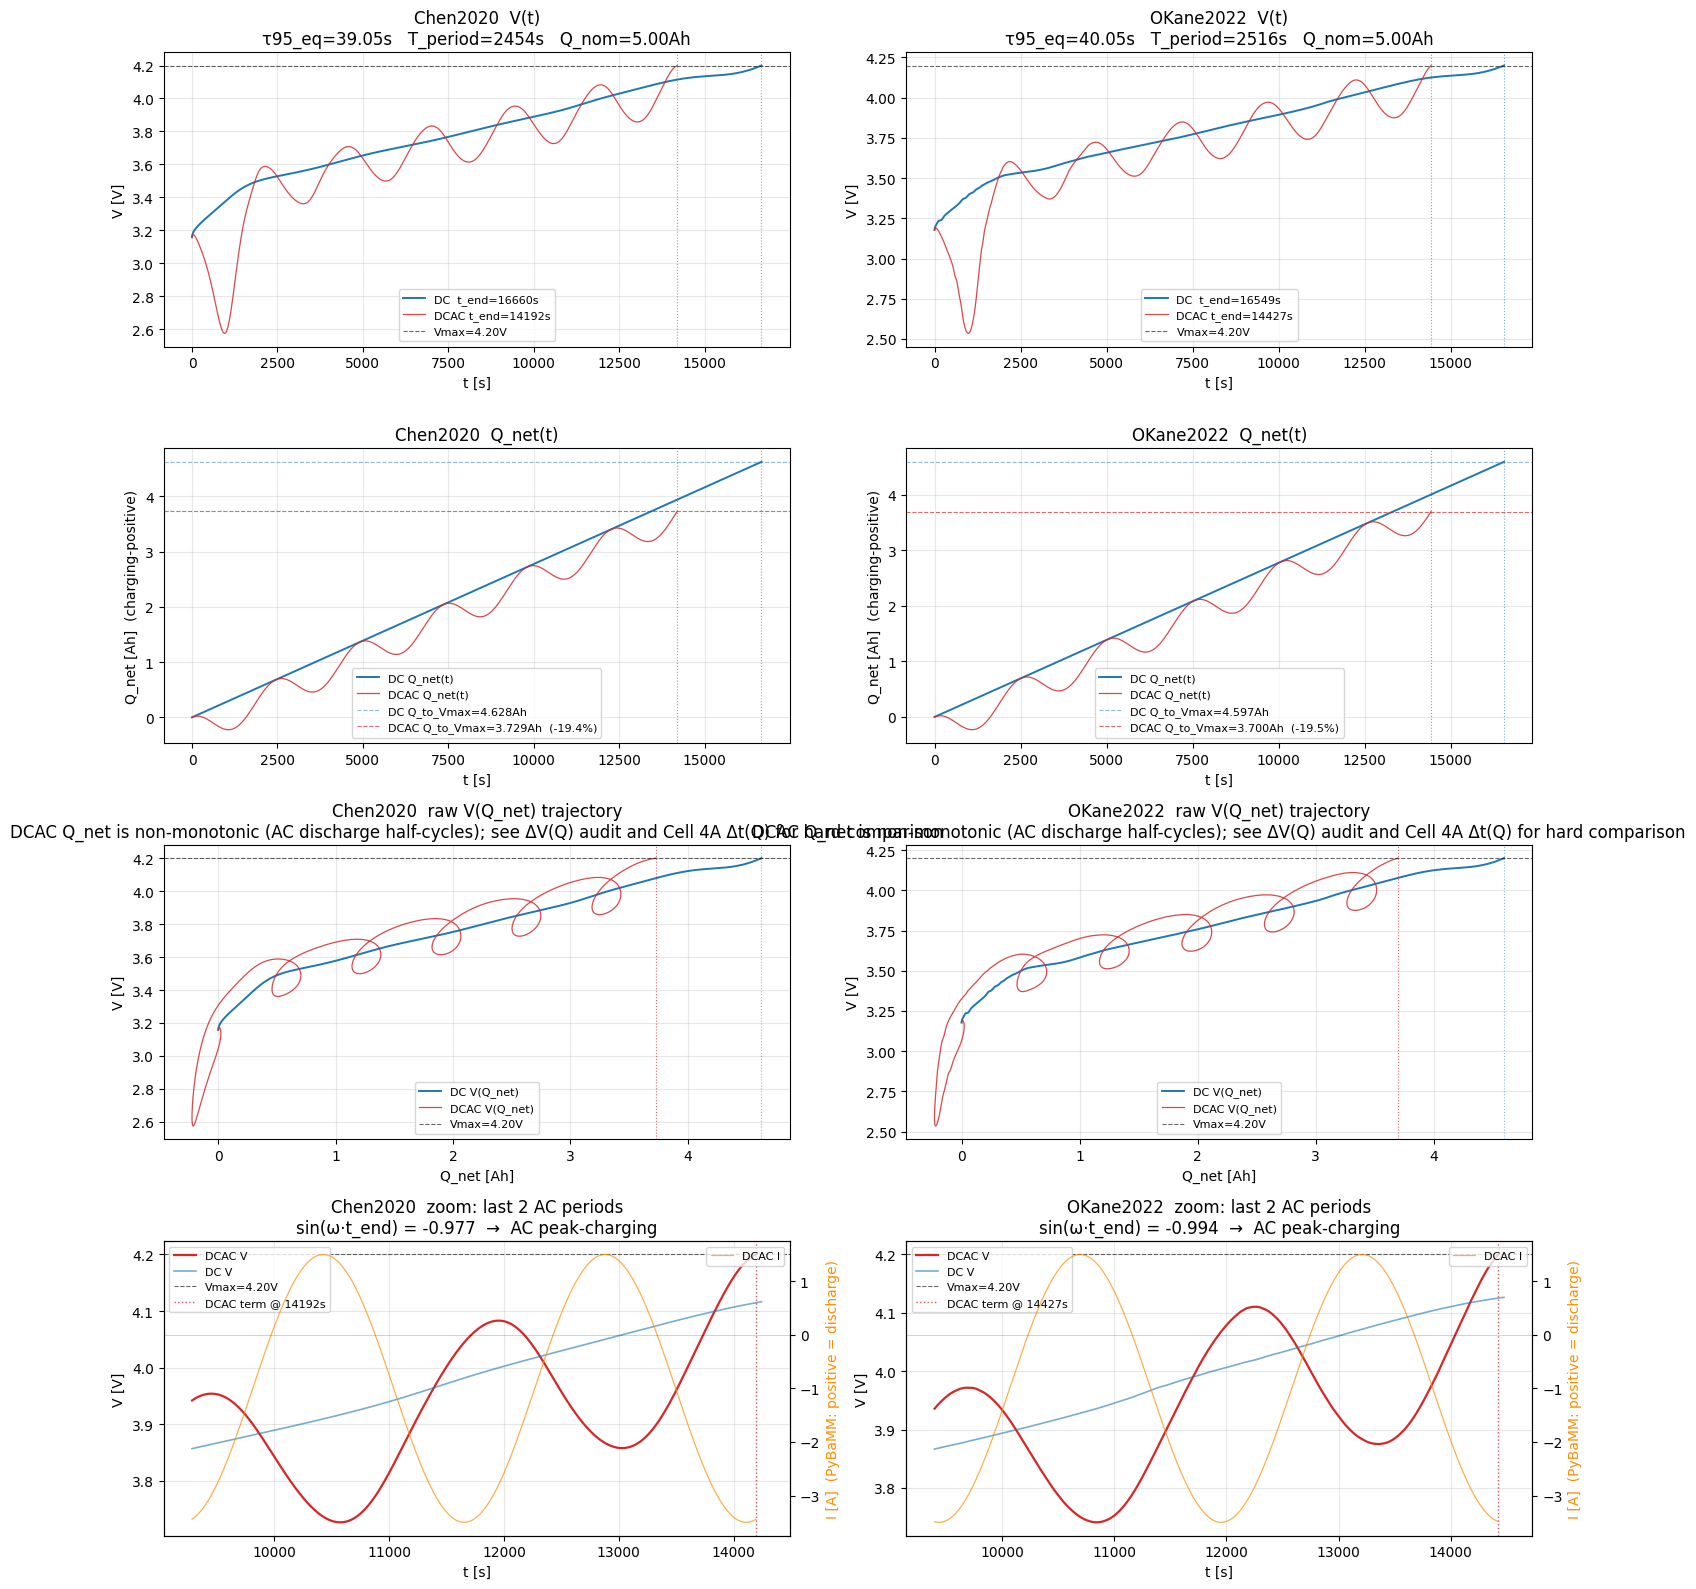

Wrote: figures/day18/day18_step1c_event_trigger_audit_v3.png

First-passage ΔV(Q) audit  (V_DCAC − V_DC at same Q, first-passage def.)

param_set  Q_nom_Ah  q_lo_Ah  q_hi_Ah  n_grid  n_valid  dV_median_V  dV_mean_V  dV_max_V  dV_min_V  frac_dV_positive  frac_dV_above_10mV
 Chen2020         5     0.25    3.629      80       80       0.1076    0.09773    0.1419   0.00609                 1              0.9875
OKane2022         5     0.25      3.6      80       80       0.1095    0.09777    0.1445  -0.01968            0.9625              0.9625

Wrote: data/day18_step1c_first_passage_dV_audit_v3.csv

AC phase + I_end audit at DCAC Vmax termination
Decision rule:
  sin(ω·t_end) <  -0.7  AND  I_end_C ≈ −(D+A)  → AC peak-triggered Vmax (event)
  sin(ω·t_end) >  +0.7  AND  I_end_C ≈ +(A−D)  → AC peak-discharging at termination
  |sin(ω·t_end)| ≤ 0.7  → mid-cycle, ambiguous

param_set  T_period_s  t_end_DCAC_s  n_periods_at_term  sin_omega_tend  I_end_A  I_end_C   phase_label  Q_to_Vmax_DC_Ah  

In [18]:
# Cell 3C v2 — event-trigger audit for feasible Route-2 anchor
# DIAGNOSTIC ONLY: assess whether DCAC Vmax_event is AC peak-triggered
# (event-layer pull-forward) vs state-driven. State-layer verdict deferred to Cell 4A Δt(Q).
# Subjects: Chen2020 / OKane2022 (largest Q_to_Vmax reduction in v3, both 5Ah LG M50).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path("/Users/louislu/pybamm-dcac-superimposed")
DATA = ROOT / "data"
FIG  = ROOT / "figures" / "day18"
FIG.mkdir(parents=True, exist_ok=True)

traj_path   = DATA / "day18_step1_anchor_trajectories_v3.npz"
matrix_path = DATA / "day18_step1_anchor_feasibility_matrix_v3.csv"
traj   = np.load(traj_path)
matrix = pd.read_csv(matrix_path)

PROTOCOL_DC   = "DC_0p2C"
PROTOCOL_DCAC = "DCAC_DC0p2C_AC0p5C_10tau"
TARGET_SETS   = ["Chen2020", "OKane2022"]

# ---- Hardened helpers --------------------------------------------------------
def get_meta(set_name, protocol):
    row = matrix[(matrix["param_set"] == set_name) & (matrix["protocol"] == protocol)]
    assert len(row) == 1, f"Expected 1 meta row for {set_name}/{protocol}, got {len(row)}"
    return row.iloc[0].to_dict()

def get_traj(set_name, protocol):
    keys = [f"{set_name}__{protocol}__{k}" for k in ("t", "V", "I", "Q_net")]
    missing = [k for k in keys if k not in traj.files]
    assert not missing, f"Missing trajectory keys: {missing}"
    return {"t": traj[keys[0]], "V": traj[keys[1]], "I": traj[keys[2]], "Q_net": traj[keys[3]]}

def first_passage_interp(x, y, q_grid):
    """Interpolate y at first index where x >= q. Robust to non-monotonic x (AC ripple)."""
    out = np.full(len(q_grid), np.nan)
    for i, q in enumerate(q_grid):
        idx = np.flatnonzero(x >= q)
        if len(idx) == 0:
            continue
        k = idx[0]
        if k == 0:
            out[i] = y[0]
        else:
            x0, x1 = x[k-1], x[k]
            y0, y1 = y[k-1], y[k]
            if x1 == x0:
                out[i] = y1
            else:
                out[i] = y0 + (q - x0) / (x1 - x0) * (y1 - y0)
    return out

# ============================================================================
# Section 1: Visual audit — 4-row × N-set figure
# ============================================================================
n_sets = len(TARGET_SETS)
fig, axes = plt.subplots(4, n_sets, figsize=(7.5 * n_sets, 16))
if n_sets == 1:
    axes = axes.reshape(-1, 1)

for col, set_name in enumerate(TARGET_SETS):
    dc, dcac     = get_traj(set_name, PROTOCOL_DC), get_traj(set_name, PROTOCOL_DCAC)
    dc_m, dcac_m = get_meta(set_name, PROTOCOL_DC), get_meta(set_name, PROTOCOL_DCAC)

    V_max     = dc_m["V_max_cutoff"]
    Q_nom     = dc_m["Q_nom_Ah"]
    T_period  = dcac_m["T_anchor_s"]
    Q_vmax_dc, Q_vmax_dcac   = dc_m["Q_to_Vmax_Ah"], dcac_m["Q_to_Vmax_Ah"]
    t_end_dc,  t_end_dcac    = dc_m["t_end_s"], dcac_m["t_end_s"]

    # Row 0: V(t) overlay
    ax = axes[0, col]
    ax.plot(dc["t"],   dc["V"],   lw=1.4, color="C0", label=f"DC  t_end={t_end_dc:.0f}s")
    ax.plot(dcac["t"], dcac["V"], lw=0.9, color="C3", alpha=0.85,
            label=f"DCAC t_end={t_end_dcac:.0f}s")
    ax.axhline(V_max, color="black", lw=0.8, ls="--", alpha=0.6, label=f"Vmax={V_max:.2f}V")
    ax.axvline(t_end_dc,   color="C0", lw=0.8, ls=":", alpha=0.6)
    ax.axvline(t_end_dcac, color="C3", lw=0.8, ls=":", alpha=0.6)
    ax.set_xlabel("t [s]"); ax.set_ylabel("V [V]")
    ax.set_title(f"{set_name}  V(t)\nτ95_eq={dc_m['tau95_eq_s']:.2f}s   "
                 f"T_period={T_period:.0f}s   Q_nom={Q_nom:.2f}Ah")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Row 1: Q_net(t) overlay
    ax = axes[1, col]
    ax.plot(dc["t"],   dc["Q_net"],   lw=1.4, color="C0", label="DC Q_net(t)")
    ax.plot(dcac["t"], dcac["Q_net"], lw=0.9, color="C3", alpha=0.85, label="DCAC Q_net(t)")
    ax.axhline(Q_vmax_dc,   color="C0", lw=0.8, ls="--", alpha=0.5,
               label=f"DC Q_to_Vmax={Q_vmax_dc:.3f}Ah")
    ax.axhline(Q_vmax_dcac, color="C3", lw=0.8, ls="--", alpha=0.7,
               label=f"DCAC Q_to_Vmax={Q_vmax_dcac:.3f}Ah  ({(Q_vmax_dcac/Q_vmax_dc-1)*100:+.1f}%)")
    ax.axvline(t_end_dc,   color="C0", lw=0.8, ls=":", alpha=0.6)
    ax.axvline(t_end_dcac, color="C3", lw=0.8, ls=":", alpha=0.6)
    ax.set_xlabel("t [s]"); ax.set_ylabel("Q_net [Ah]  (charging-positive)")
    ax.set_title(f"{set_name}  Q_net(t)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Row 2: V(Q_net) — RAW state-parametric trajectory (NOT same-Q comparison)
    ax = axes[2, col]
    ax.plot(dc["Q_net"],   dc["V"],   lw=1.4, color="C0", label="DC V(Q_net)")
    ax.plot(dcac["Q_net"], dcac["V"], lw=0.9, color="C3", alpha=0.85, label="DCAC V(Q_net)")
    ax.axhline(V_max, color="black", lw=0.8, ls="--", alpha=0.6, label=f"Vmax={V_max:.2f}V")
    ax.axvline(Q_vmax_dc,   color="C0", lw=0.8, ls=":", alpha=0.5)
    ax.axvline(Q_vmax_dcac, color="C3", lw=0.8, ls=":", alpha=0.7)
    ax.set_xlabel("Q_net [Ah]"); ax.set_ylabel("V [V]")
    ax.set_title(f"{set_name}  raw V(Q_net) trajectory\n"
                 "DCAC Q_net is non-monotonic (AC discharge half-cycles); "
                 "see ΔV(Q) audit and Cell 4A Δt(Q) for hard comparison")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Row 3: V(t) + I(t) zoom near DCAC termination
    ax = axes[3, col]
    t_zoom_start = max(0.0, t_end_dcac - 2 * T_period)
    m_dcac = (dcac["t"] >= t_zoom_start) & (dcac["t"] <= t_end_dcac + 50)
    m_dc   = (dc["t"]   >= t_zoom_start) & (dc["t"]   <= t_end_dcac + 50)

    ax.plot(dcac["t"][m_dcac], dcac["V"][m_dcac], lw=1.6, color="C3", label="DCAC V")
    ax.plot(dc["t"][m_dc],     dc["V"][m_dc],     lw=1.2, color="C0", alpha=0.6, label="DC V")
    ax.axhline(V_max, color="black", lw=0.8, ls="--", alpha=0.6, label=f"Vmax={V_max:.2f}V")
    ax.axvline(t_end_dcac, color="C3", lw=1.0, ls=":", alpha=0.8,
               label=f"DCAC term @ {t_end_dcac:.0f}s")
    ax.set_xlabel("t [s]"); ax.set_ylabel("V [V]")
    ax.legend(loc="upper left", fontsize=8); ax.grid(alpha=0.3)

    ax2 = ax.twinx()
    ax2.plot(dcac["t"][m_dcac], dcac["I"][m_dcac], lw=0.9, color="darkorange",
             alpha=0.7, label="DCAC I")
    ax2.axhline(0, color="black", lw=0.5, alpha=0.25)
    ax2.set_ylabel("I [A]  (PyBaMM: positive = discharge)", color="darkorange")
    ax2.legend(loc="upper right", fontsize=8)

    f_anchor = dcac_m["f_anchor_Hz"]
    sin_at_term = np.sin(2 * np.pi * f_anchor * t_end_dcac)
    phase_label = ("AC peak-charging" if sin_at_term < -0.7
                   else "AC peak-discharging" if sin_at_term > 0.7
                   else "mid-cycle")
    ax.set_title(f"{set_name}  zoom: last 2 AC periods\n"
                 f"sin(ω·t_end) = {sin_at_term:+.3f}  →  {phase_label}")

plt.tight_layout()
fig_path = FIG / "day18_step1c_event_trigger_audit_v3.png"
plt.savefig(fig_path, dpi=140)
plt.show()
print(f"Wrote: {fig_path.relative_to(ROOT)}")

# ============================================================================
# Section 2: ΔV(Q) at first-passage — quantitative event-layer audit
# ============================================================================
print("\n" + "=" * 80)
print("First-passage ΔV(Q) audit  (V_DCAC − V_DC at same Q, first-passage def.)")
print("=" * 80)

dV_rows = []
for set_name in TARGET_SETS:
    dc, dcac     = get_traj(set_name, PROTOCOL_DC), get_traj(set_name, PROTOCOL_DCAC)
    dc_m, dcac_m = get_meta(set_name, PROTOCOL_DC), get_meta(set_name, PROTOCOL_DCAC)
    Q_nom = dc_m["Q_nom_Ah"]

    q_lo = 0.05 * Q_nom
    q_hi = min(dc_m["Q_to_Vmax_Ah"], dcac_m["Q_to_Vmax_Ah"]) - 0.02 * Q_nom
    q_grid = np.linspace(q_lo, q_hi, 80)

    V_dc_q   = first_passage_interp(dc["Q_net"],   dc["V"],   q_grid)
    V_dcac_q = first_passage_interp(dcac["Q_net"], dcac["V"], q_grid)
    dV_q = V_dcac_q - V_dc_q
    dV_q_valid = dV_q[~np.isnan(dV_q)]

    if len(dV_q_valid) == 0:
        print(f"  {set_name}: NO VALID Q-GRID POINTS — check Q_net coverage")
        continue

    dV_rows.append({
        "param_set":           set_name,
        "Q_nom_Ah":             Q_nom,
        "q_lo_Ah":             q_lo,
        "q_hi_Ah":             q_hi,
        "n_grid":              len(q_grid),
        "n_valid":             int(len(dV_q_valid)),
        "dV_median_V":         float(np.median(dV_q_valid)),
        "dV_mean_V":           float(np.mean(dV_q_valid)),
        "dV_max_V":            float(np.max(dV_q_valid)),
        "dV_min_V":            float(np.min(dV_q_valid)),
        "frac_dV_positive":    float(np.mean(dV_q_valid > 0)),
        "frac_dV_above_10mV":  float(np.mean(dV_q_valid > 0.010)),
    })

dV_df = pd.DataFrame(dV_rows)
with pd.option_context("display.max_columns", None, "display.width", 200,
                       "display.float_format", "{:.4g}".format):
    print("\n" + dV_df.to_string(index=False))

dv_csv = DATA / "day18_step1c_first_passage_dV_audit_v3.csv"
dV_df.to_csv(dv_csv, index=False)
print(f"\nWrote: {dv_csv.relative_to(ROOT)}")

# ============================================================================
# Section 3: AC phase + I_end audit at termination
# ============================================================================
print("\n" + "=" * 80)
print("AC phase + I_end audit at DCAC Vmax termination")
print("=" * 80)
print("Decision rule:")
print("  sin(ω·t_end) <  -0.7  AND  I_end_C ≈ −(D+A)  → AC peak-triggered Vmax (event)")
print("  sin(ω·t_end) >  +0.7  AND  I_end_C ≈ +(A−D)  → AC peak-discharging at termination")
print("  |sin(ω·t_end)| ≤ 0.7  → mid-cycle, ambiguous")

audit_rows = []
for set_name in TARGET_SETS:
    dcac   = get_traj(set_name, PROTOCOL_DCAC)
    dcac_m = get_meta(set_name, PROTOCOL_DCAC)
    dc_m   = get_meta(set_name, PROTOCOL_DC)
    omega  = 2 * np.pi * dcac_m["f_anchor_Hz"]
    t_end  = dcac_m["t_end_s"]
    Q_nom  = dc_m["Q_nom_Ah"]

    sin_t   = float(np.sin(omega * t_end))
    I_end_A = float(np.interp(t_end, dcac["t"], dcac["I"]))
    I_end_C = I_end_A / Q_nom   # PyBaMM: positive = discharge → negative = charge

    label = ("peak_charging" if sin_t < -0.7
             else "peak_discharging" if sin_t > 0.7
             else "mid_cycle")

    audit_rows.append({
        "param_set":         set_name,
        "T_period_s":        dcac_m["T_anchor_s"],
        "t_end_DCAC_s":      t_end,
        "n_periods_at_term": t_end / dcac_m["T_anchor_s"],
        "sin_omega_tend":    sin_t,
        "I_end_A":           I_end_A,
        "I_end_C":           I_end_C,
        "phase_label":       label,
        "Q_to_Vmax_DC_Ah":   dc_m["Q_to_Vmax_Ah"],
        "Q_to_Vmax_DCAC_Ah": dcac_m["Q_to_Vmax_Ah"],
        "Q_reduction_pct":   (dcac_m["Q_to_Vmax_Ah"] / dc_m["Q_to_Vmax_Ah"] - 1) * 100,
    })

audit_df = pd.DataFrame(audit_rows)
with pd.option_context("display.max_columns", None, "display.width", 200,
                       "display.float_format", "{:.4g}".format):
    print("\n" + audit_df.to_string(index=False))

audit_csv = DATA / "day18_step1c_event_phase_audit_v3.csv"
audit_df.to_csv(audit_csv, index=False)
print(f"\nWrote: {audit_csv.relative_to(ROOT)}")

# ============================================================================
# Verdict guide (cautious wording — defer state-layer to Cell 4A)
# ============================================================================
print("\n" + "=" * 80)
print("Verdict guide for Cell 3C")
print("=" * 80)
print("""
If for both Chen2020 and OKane2022:
  (a) phase_label == 'peak_charging'  AND
  (b) I_end_C ≈ −0.7 (= −(D+A) at peak charging for D=0.2C, A=0.5C)  AND
  (c) frac_dV_positive > 0.7 (DCAC voltage envelope elevated at most same-Q points)

THEN  the −19% Q_to_Vmax reduction is consistent with event-layer voltage pull-forward:
      DCAC Vmax fires while Q_net is still mid-trajectory because AC peak voltage
      adds ~ I_ac · R_total transient on top of the DC trajectory.

This does NOT establish state-layer acceleration. Even with event pull-forward,
DCAC may still exhibit positive Δt(Q) in early Q regions due to local kinetics
or transport differences. Proceed to Cell 4A (Δt(Q) on shared Q-grid,
strict-net first-passage definition) for the state-layer verdict.
""")

Auto-derived FEASIBLE_SETS (7): ['Ai2020', 'Chen2020', 'Ecker2015', 'Marquis2019', 'Mohtat2020', 'NCA_Kim2011', 'OKane2022']
Excluded (one or both protocols not feasible_clean): ['ORegan2022']

Wrote: data/day18_step2_dt_Q_audit_v3.csv
Wrote: data/day18_step2_dt_Q_curves_long_v3.csv.gz  (560 rows)

Cell 4A — Δt(Q) audit on Route2_AC0p5C_10tau_native  (anchor-level, NOT Day-18-level)
  param_set  Q_nom_Ah  rel_ripple_pct_window  Q_to_Vmax_shift_pct  full_mean_s  full_rel_signal_pct full_class_mean full_sign_topology  full_frac_positive  full_n_cross  stable_mean_s  stable_rel_signal_pct stable_class_mean stable_sign_topology
     Ai2020      2.28                  5.908               -6.425       -635.5               -7.273        negative      negative_only                   0             0         -626.6                 -6.188          negative        negative_only
   Chen2020         5                  8.025               -19.42       -682.1               -9.769        negative      n

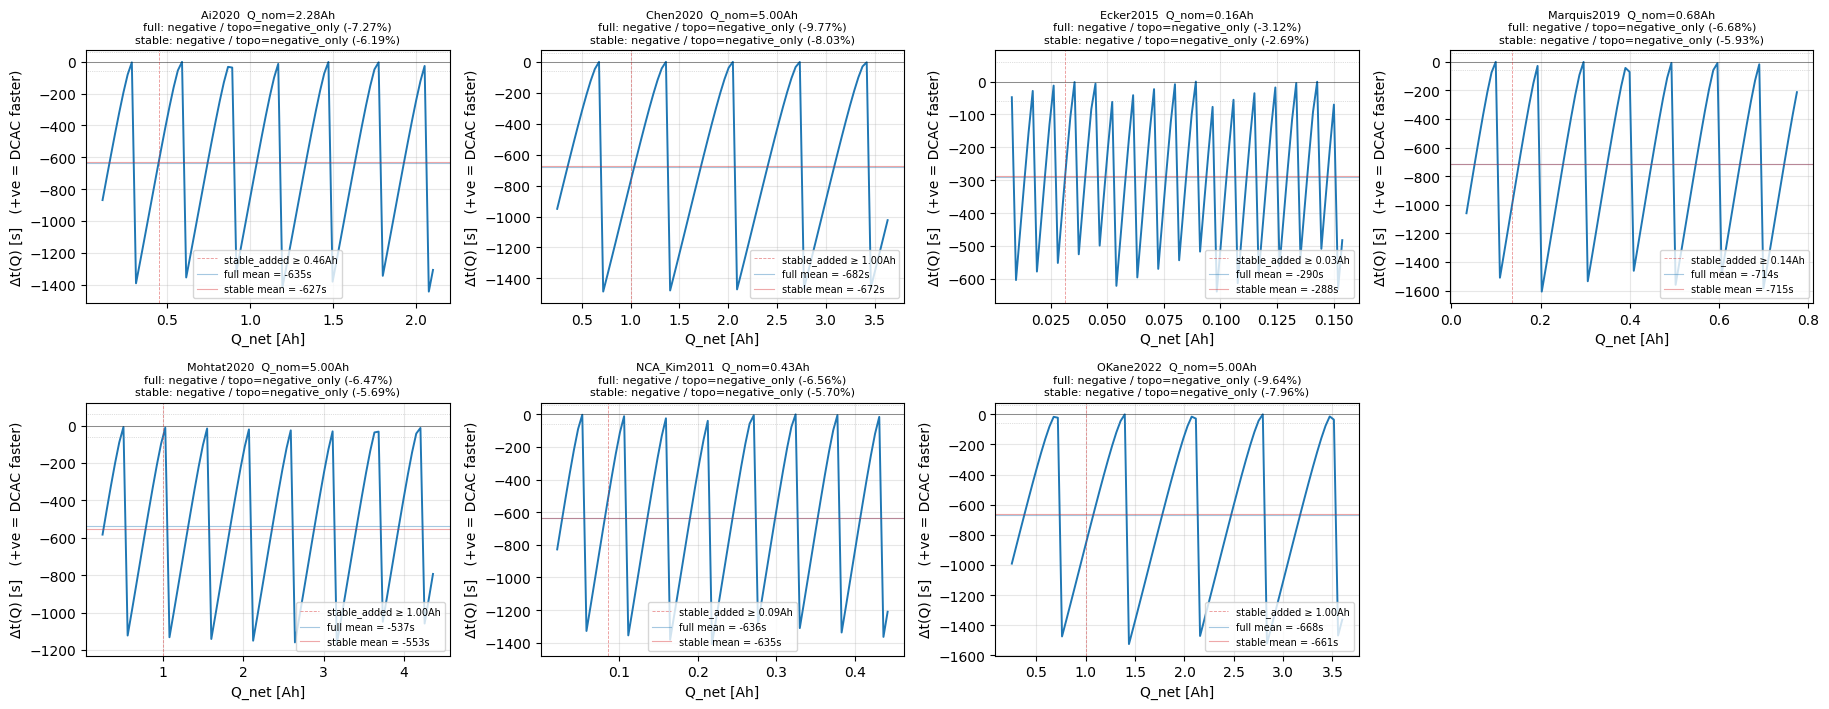

Wrote: figures/day18/day18_step2_dt_Q_audit_v3.png

Sign-class & topology distributions across 7 feasible_clean sets
(anchor: Route2_AC0p5C_10tau_native)

full_class_mean:
  negative: 7

full_sign_topology:
  negative_only: 7

stable_class_mean:
  negative: 7

stable_sign_topology:
  negative_only: 7

--- Interpretation rules (anchor-level only) ---
1. If both full_sign_topology and stable_sign_topology are 'near_zero' across all sets:
   → Native tau95_eq frequency rebasing does NOT support state-layer DCAC acceleration
     in the feasible subset under the tested Route2_AC0p5C_10tau_native anchor.
   → Day-16 fixed-label finding extends to this anchor; other anchors not yet tested.

2. If any set shows stable_sign_topology != 'near_zero':
   → A non-trivial state-layer signal exists at this anchor for that set; investigate.
   → Cross-check with full topology: if 'positive_only' or 'negative_only' in stable, robust signal.
   → If 'mixed' in stable: trajectory-shape effect, not unifo

In [21]:
# Cell 4A v2 — feasible-subset Δt(Q) first-passage audit (Route-2 anchor v3)
# SCOPE: ONE anchor only — Route-2 AC0.5C/10τ_native. Findings here are anchor-level,
#        not Day-18-level. Other anchors (1τ, 0.3C, 0.8C/1τ) not tested.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# NumPy 2.x compatibility shim (np.trapz removed → np.trapezoid)
trapz = getattr(np, "trapezoid", getattr(np, "trapz", None))
assert trapz is not None, "Neither np.trapezoid nor np.trapz available"

ROOT = Path("/Users/louislu/pybamm-dcac-superimposed")
DATA = ROOT / "data"
FIG  = ROOT / "figures" / "day18"
FIG.mkdir(parents=True, exist_ok=True)

traj   = np.load(DATA / "day18_step1_anchor_trajectories_v3.npz")
matrix = pd.read_csv(DATA / "day18_step1_anchor_feasibility_matrix_v3.csv")

PROTOCOL_DC   = "DC_0p2C"
PROTOCOL_DCAC = "DCAC_DC0p2C_AC0p5C_10tau"
ANCHOR_LABEL  = "Route2_AC0p5C_10tau_native"

# Auto-derive feasible sets (intersection of DC and DCAC feasible_clean)
feasible_dc   = set(matrix.query(f"protocol == '{PROTOCOL_DC}'   and feasibility_verdict == 'feasible_clean'")["param_set"])
feasible_dcac = set(matrix.query(f"protocol == '{PROTOCOL_DCAC}' and feasibility_verdict == 'feasible_clean'")["param_set"])
FEASIBLE_SETS = sorted(feasible_dc & feasible_dcac)
EXCLUDED      = sorted((feasible_dc | feasible_dcac) - set(FEASIBLE_SETS))
print(f"Auto-derived FEASIBLE_SETS ({len(FEASIBLE_SETS)}): {FEASIBLE_SETS}")
print(f"Excluded (one or both protocols not feasible_clean): {EXCLUDED}")

ABS_S_THRESH = 60.0
REL_THRESH   = 0.005   # 0.5% of mean DC window time

# ---- Helpers ----------------------------------------------------------------
def get_meta(set_name, protocol):
    row = matrix[(matrix["param_set"] == set_name) & (matrix["protocol"] == protocol)]
    assert len(row) == 1, f"Expected 1 row for {set_name}/{protocol}, got {len(row)}"
    return row.iloc[0].to_dict()

def get_traj(set_name, protocol):
    keys = [f"{set_name}__{protocol}__{k}" for k in ("t", "V", "I", "Q_net")]
    missing = [k for k in keys if k not in traj.files]
    assert not missing, f"Missing keys: {missing}"
    return {"t": traj[keys[0]], "V": traj[keys[1]], "I": traj[keys[2]], "Q_net": traj[keys[3]]}

def first_passage_t(q_net, t, q_grid):
    """First-passage time at each q in q_grid. NaN if never reached."""
    out = np.full(len(q_grid), np.nan)
    for i, q in enumerate(q_grid):
        idx = np.flatnonzero(q_net >= q)
        if len(idx) == 0:
            continue
        k = idx[0]
        if k == 0:
            out[i] = t[0]
        else:
            q0, q1 = q_net[k-1], q_net[k]
            t0, t1 = t[k-1], t[k]
            out[i] = t0 + (q - q0) / (q1 - q0) * (t1 - t0) if q1 != q0 else t1
    return out

def classify_mean(mean_dt_s, t_dc_window_avg_s):
    abs_pass = abs(mean_dt_s) >= ABS_S_THRESH
    rel_pass = (t_dc_window_avg_s > 0) and (abs(mean_dt_s) / t_dc_window_avg_s >= REL_THRESH)
    if abs_pass and rel_pass:
        return ("positive" if mean_dt_s > 0 else "negative"), abs_pass, rel_pass
    return "near_zero", abs_pass, rel_pass

def sign_topology(dt_v, abs_thresh=ABS_S_THRESH):
    """Topology classification independent of mean cancellation."""
    if len(dt_v) == 0:
        return "EMPTY"
    if np.max(np.abs(dt_v)) < abs_thresh:
        return "near_zero"
    pos_strong = bool(np.any(dt_v > +abs_thresh))
    neg_strong = bool(np.any(dt_v < -abs_thresh))
    if pos_strong and not neg_strong:
        return "positive_only"
    if neg_strong and not pos_strong:
        return "negative_only"
    return "mixed"

def n_zero_crossings(arr):
    if len(arr) < 2:
        return 0
    s = np.sign(arr)
    s[s == 0] = 1
    return int(np.sum(np.diff(s) != 0))

def window_metrics(q_v, dt_v, t_dc_v, prefix):
    """Compute full set of mean + topology metrics for a (sub)window."""
    if len(dt_v) < 2:
        return {f"{prefix}_n": int(len(dt_v)), f"{prefix}_status": "INSUFFICIENT"}

    dt_mean   = float(np.mean(dt_v))
    dt_median = float(np.median(dt_v))
    dt_area   = float(trapz(dt_v, q_v))
    dt_min    = float(np.min(dt_v))
    dt_max    = float(np.max(dt_v))
    t_dc_avg  = float(np.mean(t_dc_v))

    cls_mean, abs_p, rel_p = classify_mean(dt_mean, t_dc_avg)
    topo = sign_topology(dt_v)
    n_cross = n_zero_crossings(dt_v)

    n_third = max(1, len(dt_v) // 3)
    dt_early = float(np.mean(dt_v[:n_third]))
    dt_mid   = float(np.mean(dt_v[n_third:2*n_third])) if 2*n_third < len(dt_v) else float(np.mean(dt_v[n_third:]))
    dt_late  = float(np.mean(dt_v[2*n_third:]))

    return {
        f"{prefix}_n":               int(len(dt_v)),
        f"{prefix}_status":           "OK",
        f"{prefix}_mean_s":           dt_mean,
        f"{prefix}_median_s":         dt_median,
        f"{prefix}_area_sAh":         dt_area,
        f"{prefix}_min_s":            dt_min,
        f"{prefix}_max_s":            dt_max,
        f"{prefix}_range_s":          dt_max - dt_min,
        f"{prefix}_frac_positive":    float(np.mean(dt_v > 0)),
        f"{prefix}_frac_above_thr":   float(np.mean(dt_v > +ABS_S_THRESH)),
        f"{prefix}_frac_below_thr":   float(np.mean(dt_v < -ABS_S_THRESH)),
        f"{prefix}_n_cross":          n_cross,
        f"{prefix}_mean_early_s":     dt_early,
        f"{prefix}_mean_mid_s":       dt_mid,
        f"{prefix}_mean_late_s":      dt_late,
        f"{prefix}_t_dc_avg_s":       t_dc_avg,
        f"{prefix}_rel_signal_pct":   100 * dt_mean / t_dc_avg if t_dc_avg > 0 else np.nan,
        f"{prefix}_class_mean":       cls_mean,
        f"{prefix}_sign_topology":    topo,
    }

# ---- Per-set Δt(Q) analysis -------------------------------------------------
results, dt_curves = [], {}

for set_name in FEASIBLE_SETS:
    dc, dcac     = get_traj(set_name, PROTOCOL_DC), get_traj(set_name, PROTOCOL_DCAC)
    dc_m, dcac_m = get_meta(set_name, PROTOCOL_DC), get_meta(set_name, PROTOCOL_DCAC)

    Q_nom        = dc_m["Q_nom_Ah"]
    Q_vmax_dc    = dc_m["Q_to_Vmax_Ah"]
    Q_vmax_dcac  = dcac_m["Q_to_Vmax_Ah"]
    t_end_dc     = dc_m["t_end_s"]
    t_end_dcac   = dcac_m["t_end_s"]

    q_lo_full         = 0.05 * Q_nom
    q_lo_stable_added = 0.20 * Q_nom    # added-charge from SOC0=0.05; NOT absolute SOC=0.20
    q_hi              = min(Q_vmax_dc, Q_vmax_dcac) - 0.02 * Q_nom

    assert q_hi > q_lo_full, f"{set_name}: q_hi ({q_hi:.3f}) <= q_lo_full ({q_lo_full:.3f})"

    q_grid = np.linspace(q_lo_full, q_hi, 80)
    t_dc_q   = first_passage_t(dc["Q_net"],   dc["t"], q_grid)
    t_dcac_q = first_passage_t(dcac["Q_net"], dcac["t"], q_grid)
    dt_q = t_dc_q - t_dcac_q

    valid = ~(np.isnan(t_dc_q) | np.isnan(t_dcac_q))
    if valid.sum() < 2:
        results.append({"param_set": set_name, "n_valid": int(valid.sum()),
                        "status": "INSUFFICIENT_GRID"})
        continue

    q_v       = q_grid[valid]
    dt_v      = dt_q[valid]
    t_dc_v    = t_dc_q[valid]
    t_dcac_v  = t_dcac_q[valid]
    stable    = q_v >= q_lo_stable_added

    # AC charge ripple (sinusoidal current integral; NOT positive-lobe net charge)
    I_ac_A = 0.5 * Q_nom
    omega  = 2 * np.pi * dcac_m["f_anchor_Hz"]
    Q_sin_ripple_amp_Ah = I_ac_A / (omega * 3600)

    # Full-window metrics
    full_m = window_metrics(q_v, dt_v, t_dc_v, prefix="full")

    # Stable-subset metrics (audit only)
    if stable.sum() >= 2:
        stable_m = window_metrics(q_v[stable], dt_v[stable], t_dc_v[stable], prefix="stable")
    else:
        stable_m = {"stable_n": int(stable.sum()), "stable_status": "INSUFFICIENT"}

    row = {
        "param_set":                  set_name,
        "anchor_label":               ANCHOR_LABEL,
        "Q_nom_Ah":                   Q_nom,
        "tau95_eq_s":                 dc_m["tau95_eq_s"],
        "T_period_s":                 dcac_m["T_anchor_s"],
        "f_anchor_Hz":                dcac_m["f_anchor_Hz"],
        "Q_sinusoidal_ripple_amp_Ah": Q_sin_ripple_amp_Ah,
        "rel_ripple_pct_window":      100 * Q_sin_ripple_amp_Ah / (q_hi - q_lo_full),
        "q_lo_full_Ah":               q_lo_full,
        "q_lo_stable_added_Ah":       q_lo_stable_added,
        "q_hi_Ah":                    q_hi,
        "stable_window_definition":   "Q_net >= 0.20*Q_nom from sim start (SOC0=0.05); NOT absolute SOC",
        "n_grid":                     len(q_grid),
        "n_valid":                    int(valid.sum()),
        "t_end_DC_s":                 t_end_dc,
        "t_end_DCAC_s":               t_end_dcac,
        "event_shift_s":              t_end_dc - t_end_dcac,
        "Q_to_Vmax_DC_Ah":            Q_vmax_dc,
        "Q_to_Vmax_DCAC_Ah":          Q_vmax_dcac,
        "Q_to_Vmax_shift_Ah":         Q_vmax_dcac - Q_vmax_dc,
        "Q_to_Vmax_shift_pct":        (Q_vmax_dcac / Q_vmax_dc - 1) * 100,
    }
    row.update(full_m)
    row.update(stable_m)
    results.append(row)

    dt_curves[set_name] = {
        "q_v": q_v, "dt_v": dt_v, "t_dc_v": t_dc_v, "t_dcac_v": t_dcac_v,
        "q_lo_stable": q_lo_stable_added, "Q_nom": Q_nom,
    }

results_df = pd.DataFrame(results)

# ---- Save: summary CSV ------------------------------------------------------
results_csv = DATA / "day18_step2_dt_Q_audit_v3.csv"
results_df.to_csv(results_csv, index=False)
print(f"\nWrote: {results_csv.relative_to(ROOT)}")

# ---- Save: long-format Δt(Q) curves ----------------------------------------
long_rows = []
for set_name, c in dt_curves.items():
    for i, q in enumerate(c["q_v"]):
        long_rows.append({
            "param_set":           set_name,
            "anchor_label":        ANCHOR_LABEL,
            "Q_Ah":                q,
            "Q_frac_nom_added":    q / c["Q_nom"],
            "t_DC_s":              c["t_dc_v"][i],
            "t_DCAC_s":            c["t_dcac_v"][i],
            "dtQ_s":               c["dt_v"][i],
            "window_full":         True,
            "window_stable_added": bool(q >= c["q_lo_stable"]),
            "protocol_DC":         PROTOCOL_DC,
            "protocol_DCAC":       PROTOCOL_DCAC,
            "status":              "OK",
        })
long_df = pd.DataFrame(long_rows)
long_csv = DATA / "day18_step2_dt_Q_curves_long_v3.csv.gz"
long_df.to_csv(long_csv, index=False, compression="gzip")
print(f"Wrote: {long_csv.relative_to(ROOT)}  ({len(long_df)} rows)")

# ---- Display summary --------------------------------------------------------
print("\n" + "=" * 110)
print(f"Cell 4A — Δt(Q) audit on {ANCHOR_LABEL}  (anchor-level, NOT Day-18-level)")
print("=" * 110)
display_cols = [
    "param_set", "Q_nom_Ah", "rel_ripple_pct_window",
    "Q_to_Vmax_shift_pct",
    "full_mean_s", "full_rel_signal_pct", "full_class_mean", "full_sign_topology",
    "full_frac_positive", "full_n_cross",
    "stable_mean_s", "stable_rel_signal_pct", "stable_class_mean", "stable_sign_topology",
]
display_cols = [c for c in display_cols if c in results_df.columns]
with pd.option_context("display.max_columns", None, "display.width", 230,
                       "display.float_format", "{:.4g}".format):
    print(results_df[display_cols].to_string(index=False))

# ---- Multi-panel Δt(Q) figure (visualisation aid; CSV remains primary) -----
n = len(dt_curves)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.6 * nrows))
axes_flat = axes.flatten() if hasattr(axes, "flatten") else [axes]

for idx, (set_name, c) in enumerate(dt_curves.items()):
    ax = axes_flat[idx]
    row = next(r for r in results if r.get("param_set") == set_name and "full_mean_s" in r)

    ax.plot(c["q_v"], c["dt_v"], lw=1.4, color="C0")
    ax.axhline(0, color="black", lw=0.7, alpha=0.4)
    ax.axhline(+ABS_S_THRESH, color="gray", lw=0.5, ls=":", alpha=0.5)
    ax.axhline(-ABS_S_THRESH, color="gray", lw=0.5, ls=":", alpha=0.5)
    ax.axvline(c["q_lo_stable"], color="C3", lw=0.6, ls="--", alpha=0.5,
               label=f"stable_added ≥ {c['q_lo_stable']:.2f}Ah")
    ax.axhline(row["full_mean_s"], color="C0", lw=0.8, ls="-", alpha=0.4,
               label=f"full mean = {row['full_mean_s']:.0f}s")
    if "stable_mean_s" in row and not np.isnan(row.get("stable_mean_s", np.nan)):
        ax.axhline(row["stable_mean_s"], color="C3", lw=0.8, ls="-", alpha=0.4,
                   label=f"stable mean = {row['stable_mean_s']:.0f}s")

    ax.set_xlabel("Q_net [Ah]")
    ax.set_ylabel("Δt(Q) [s]   (+ve = DCAC faster)")
    ax.set_title(f"{set_name}  Q_nom={row['Q_nom_Ah']:.2f}Ah\n"
                 f"full: {row['full_class_mean']} / topo={row['full_sign_topology']} "
                 f"({row['full_rel_signal_pct']:+.2f}%)\n"
                 f"stable: {row.get('stable_class_mean','—')} / topo={row.get('stable_sign_topology','—')} "
                 f"({row.get('stable_rel_signal_pct', float('nan')):+.2f}%)",
                 fontsize=8)
    ax.legend(fontsize=7, loc="best")
    ax.grid(alpha=0.3)

for j in range(idx + 1, len(axes_flat)):
    axes_flat[j].axis("off")

plt.tight_layout()
fig_path = FIG / "day18_step2_dt_Q_audit_v3.png"
plt.savefig(fig_path, dpi=140)
plt.show()
print(f"Wrote: {fig_path.relative_to(ROOT)}")

# ---- Summary distributions --------------------------------------------------
print("\n" + "=" * 110)
print(f"Sign-class & topology distributions across {len(FEASIBLE_SETS)} feasible_clean sets")
print(f"(anchor: {ANCHOR_LABEL})")
print("=" * 110)
for col in ["full_class_mean", "full_sign_topology", "stable_class_mean", "stable_sign_topology"]:
    if col in results_df.columns:
        counts = results_df[col].value_counts(dropna=False).to_dict()
        print(f"\n{col}:")
        for k, v in counts.items():
            print(f"  {k}: {v}")

print(f"""
--- Interpretation rules (anchor-level only) ---
1. If both full_sign_topology and stable_sign_topology are 'near_zero' across all sets:
   → Native tau95_eq frequency rebasing does NOT support state-layer DCAC acceleration
     in the feasible subset under the tested {ANCHOR_LABEL} anchor.
   → Day-16 fixed-label finding extends to this anchor; other anchors not yet tested.

2. If any set shows stable_sign_topology != 'near_zero':
   → A non-trivial state-layer signal exists at this anchor for that set; investigate.
   → Cross-check with full topology: if 'positive_only' or 'negative_only' in stable, robust signal.
   → If 'mixed' in stable: trajectory-shape effect, not uniform acceleration; inspect early/mid/late.

3. For Chen2020 / OKane2022 specifically (already showing event-layer pull-forward):
   → If stable_sign_topology = near_zero and stable_class_mean = near_zero
     → Δt(Q) state-layer null; -19% Q_to_Vmax was pure event-layer (Cell 1c finding closes).
   → If positive: residual state-layer signal beyond event-layer; warrants AC=0.3C cross-check.
   → If negative: DCAC genuinely slower at same Q (Coulombic/transport loss); investigate.

4. Compare full vs stable per set:
   → If full=positive but stable=near_zero: full-window signal is initial AC transient
     bias (q < ~ Q_sinusoidal_ripple_amp_Ah region), not state-layer.
""")

# Day 18 — Morning Close & Phase-Convention HOLD (2026-05-05)

## ⚠️ STATUS

```
session:        Day 18 morning (Route 2 anchor branch)
computation:    Cell 0 → Cell 4A complete
interpretation: HOLD — phase-convention mismatch suspected
                See §7 below. Resolution required before any Day-18 verdict.
```

## 1. Descriptor selection (Cell 2 series)

```
main descriptor:           tau95_eq = t95_s / 2.9957   (recovery-equivalent τ)
sensitivity / tail audit:  tau99_eq                    (audit only)
bi-exp audit descriptor:   tau2_biexp                  (audit only)
rejected:                  tau_FG_eff                  (1 s grid quantization,
                                                        tie_fraction = 0.375,
                                                        Cell 2D max|Δy| = 0.086
                                                        confirms shape folding)
route_decision:            ROUTE_2_RECOVERY_EQ_TAU_MAIN
execution_mode:            ANCHOR_FIRST_NOT_FULL_56
```

## 2. Anchor protocol (current morning branch)

```
DC       = 0.2C
AC       = 0.5C
nτ       = 10
T_period = 2π · nτ · tau95_eq      (per-set native, 1027–2999 s)
SOC0     = 0.05
PyBaMM current convention:
    I_py = -I_DC + I_AC · pybamm.sin(omega * t)
    → discharge-first AC phase (see §7)
```

## 3. Feasibility (Cell 3B v3)

```
DC:    8/8 feasible_clean
DCAC:  7/8 feasible_clean,  1/8 boundary_confounded (ORegan2022, V_min event)

Threshold validation: predicted lobe Q_frac ≥ ~6 % Q_nom per period at
SOC0 = 0.05 / V_headroom 0.5–0.8 V drives termination at V_min.
ORegan2022 predicted lobe = 6.00 %  →  the only failure.
Other 7 sets in [2.06 %, 5.25 %]    →  all feasible_clean.

Files:
    data/day18_step1_anchor_feasibility_matrix_v3.csv
    data/day18_step1_anchor_trajectories_v3.npz
```

## 4. Event-trigger audit (Cell 3C, Chen2020 / OKane2022)

```
sin(ω·t_end_DCAC):  -0.977 / -0.994        → AC peak-charging
I_end_C:            -0.688 / -0.697        → consistent with -(D+A) = -0.7C
Q_to_Vmax shift:    -19.4 % / -19.5 %      → DCAC fires Vmax at lower Q_net
First-passage ΔV(Q) median:  +108 / +110 mV
frac(ΔV>0):         1.000 / 0.963

Verdict (anchor-level, this phase only):
    EVENT_LAYER_PULL_FORWARD_CONFIRMED_FOR_CHEN2020_OKANE2022
    physical attribution: AC peak transient polarization
                          (Ohmic + transport + short-time kinetics)
                          ~110 mV consistent with R0·I_ac_peak + BV transient.
```

## 5. Δt(Q) first-passage audit (Cell 4A)

```
Δt(Q) = t_DC(Q) − t_DCAC(Q)        (+ve = DCAC faster)
Q-window: [0.05·Q_nom, min(Q_to_Vmax_DC, Q_to_Vmax_DCAC) − 0.02·Q_nom]
Method:   strict-net Q_net = -∫I dt / 3600 (signed), first-passage on Q-grid

Result: 7/7 sets → negative_only / negative across full + stable windows.

set            full_mean_s   stable_mean_s   topology
Ai2020         -635.5        -626.6          negative_only
Chen2020       -682.1        -672.2          negative_only
Ecker2015      -290.5        -287.7          negative_only
Marquis2019    -714.4        -714.6          negative_only
Mohtat2020     -537.0        -552.5          negative_only
NCA_Kim2011    -635.7        -635.3          negative_only
OKane2022      -667.9        -660.9          negative_only
```

## 6. Critical finding — Δt(Q) is dominated by geometric phase, not state-layer

Cross-set audit of observed |Δt| vs analytical AC ripple integral `I_AC / (I_DC · ω)`:

```
set            observed |full_mean|   I_AC/(I_DC·ω)   ratio
Ai2020         635.5 s                925 s            0.687
Chen2020       682.1 s                976 s            0.699
Ecker2015      290.5 s                408 s            0.712
Marquis2019    714.4 s               1042 s            0.686
Mohtat2020     537.0 s                750 s            0.716
NCA_Kim2011    635.7 s                902 s            0.705
OKane2022      667.9 s                976 s            0.684

ratio range: 0.684 – 0.716       cross-chemistry spread < 5 %
```

The ratio is universal and dimensionless. It depends only on `I_DC / I_AC = 0.4` and the AC starting-phase convention.

### Geometric origin

In current-controlled PyBaMM mode, `Q_net(t)` is exactly the time integral of applied current — battery dynamics affect V(t) only, not Q_net(t). For the morning phase convention:

```
I(t)       = -I_DC + I_AC · sin(ωt)
Q_net(t)   = (I_DC·t)/3600 + (I_AC/(ω·3600))·(cos(ωt) − 1)
                              └────── ripple ≤ 0 always ──────┘
```

`cos(ωt) − 1 ≤ 0` → DCAC Q_net always ≤ DC trend → first-passage always later → Δt(Q) ≤ 0 always. This is geometric, not physics.

### Why this was invisible in Day 9–14

Day 9–14 were DCAC vs DCAC ablation comparisons. Both sides carried identical geometric bias → bias cancels in the differential. Day 18 is the first DC vs DCAC Δt(Q) comparison; the bias is exposed.

### Why this was below threshold at Day 16 fixed-label

Geometric baseline scales as `I_AC / (I_DC · ω) ∝ T_period`. Fixed-label τ = 11.1 s → T = 69.7 s → baseline ≈ 20 s for Chen2020 (below 60 s abs threshold) → reported as near_zero. Route 2 native (T = 1027–2999 s) → baseline ≈ 290–715 s → above threshold → reported as negative.

The Day-16 → Day-18 sign-class change is the same geometric baseline crossing the threshold, not different physics.

## 7. Phase-convention HOLD

Visual inspection of morning V(t) trajectories shows an early voltage depression to V_min ≈ 2.55 V (Chen2020) within the first AC quarter-period. This is consistent with the `+I_AC · sin(ωt)` discharge-leaning first half-cycle in PyBaMM convention.

The real NGU201 experimental waveform likely starts with charge-leaning AC (charge-first), making the experiment-faithful PyBaMM equivalent:

```
discharge-first (current branch):  I_py = -I_DC + I_AC · pybamm.sin(omega*t)
charge-first    (proposed):        I_py = -I_DC - I_AC · pybamm.sin(omega*t)
                  equivalent:      I_py = -I_DC + I_AC · pybamm.sin(omega*t + π)
```

### Predicted effect of phase flip on geometric baseline

Charge-first convention gives `ripple = +(I_AC/(ω·3600))·(1 − cos(ωt)) ≥ 0` → DCAC Q_net always ≥ DC trend → first-passage earlier → Δt(Q) ≥ 0 with the same 0.70 prefactor. Sign flip, magnitude preserved.

```
Chen2020 prediction under charge-first phase:
    Δt_geometric_full_mean ≈ +0.70 · I_AC/(I_DC·ω) ≈ +683 s

If Cell 3D smoke test reports +680 s ± phase-noise: phase hypothesis
confirmed, geometric explanation symmetric. State-layer residual then
extracted as observed − geometric_predicted on either branch.

If Cell 3D reports something else: phase hypothesis incomplete —
revisit before any conclusion.
```

## 8. Scope statement

```
valid:     Route2_AC0p5C_10tau_native, discharge-first phase
           7/7 feasible sets show negative_only Δt(Q), dominated by
           geometric AC integration baseline (ratio 0.70 ± 0.02
           across 7 chemistries).

NOT valid extension:
           generic Day-18 statement, all phases, all amplitudes,
           all frequencies, experiment-faithful conditions.

Cell 3C state-layer evidence (V envelope + event-layer attribution):
           independent of phase convention — phase changes the geometric
           Q_net trajectory but not the V(Q) envelope mechanism. Therefore
           the "−19 % Q_to_Vmax = event-layer pull-forward" attribution
           survives phase audit. State-layer null on V envelope holds.

Cell 4A Δt(Q) interpretation: HOLD pending Cell 3D phase audit + geometric
           residual extraction. Raw Δt magnitudes do not constitute
           state-layer evidence on either phase branch.
```

## 9. Afternoon plan — Cell 3D phase-convention smoke test

```
Minimum code change in current function builder:
    # OLD (morning, discharge-first):
    I_py = -I_DC + I_AC * pybamm.sin(omega * t)
    # NEW (charge-first, experiment-faithful candidate):
    I_py = -I_DC - I_AC * pybamm.sin(omega * t)

Smoke test scope:
    sets:    Chen2020, OKane2022, ORegan2022     (3 sets, ~1 min wall total)
    anchor:  same Route 2 protocol, AC = 0.5C, 10τ_native
    output:  data/day18_step1_phase_audit_matrix_v4_charge_first.csv
             data/day18_step1_phase_audit_trajectories_v4_charge_first.npz

Decision tree (Cell 3D smoke-test outcome interpretation):
 
  A. ORegan2022 v4 = feasible_clean
     → v3 boundary was phase-driven; lobe-exposure threshold is phase-conditional.
 
  B. ORegan2022 v4 still boundary_confounded
     → slow native period × low-SOC start is a genuine feasibility limit;
        phase is aggravating, not the sole cause.
 
  C. Chen2020 / OKane2022 v4: V_min_obs stays well above V_min_cutoff,
     Q_to_Vmax approaches DC's full capacity (~4.6 Ah), and DCAC sanity
     fields show I_first_nonzero_C < -0.2C and I_min_first_period_C ≈ -0.7C
     reached early in the period.
     → charge-first removes the early-period voltage depression as expected
        from the AC sign change. Phase audit confirms NGU201 experiment-
        faithful equivalent is the charge-first branch.
 
  D. Anything else (e.g., I_first_nonzero_C >= -0.2C, V_min_obs still ≈ V_min,
     or Q_to_Vmax shape unchanged)
     → phase hypothesis incomplete or current-function not flipping cleanly;
        DO NOT proceed to Cell 4A v4 until resolved.
 
Next step (after this cell, ONLY if A or B + C is satisfied):
  rerun Δt(Q) audit on v4 trajectories. NO sign or magnitude prediction is
  assumed for the Δt(Q) outcome — topology must be measured, not predicted.
```


In [22]:
# Cell 3D v2 — Charge-first phase-convention smoke test (Route 2 anchor v4)
# AUDITED: model builder must match Cell 3B v3 exactly; phase is the ONLY change.
# Reuses morning's PyBaMM environment. Only difference vs Cell 3B v3:
#     discharge-first (v3): I_py = -I_DC + I_AC · pybamm.sin(omega*t)
#     charge-first    (v4): I_py = -I_DC - I_AC · pybamm.sin(omega*t)
# Smoke test: Chen2020, OKane2022, ORegan2022 only. ~1 min wall total.
# Outputs are NEW files; v3 morning data is preserved.

# ============================================================================
# CRITICAL PRE-RUN CHECK
# ----------------------------------------------------------------------------
# build_model() below uses pybamm.lithium_ion.DFN() with NO options for ALL sets.
# If your Cell 3B v3 used any model options (e.g., for OKane2022),
# you MUST mirror those options here. Otherwise this cell changes BOTH phase
# AND model topology and is not a phase audit.
# Verify by inspecting Cell 3B v3 in the notebook before running.
# ============================================================================

import pybamm
import numpy as np
import pandas as pd
import time
from pathlib import Path

ROOT = Path("/Users/louislu/pybamm-dcac-superimposed")
DATA = ROOT / "data"

print(f"PyBaMM version: {pybamm.__version__}")

# ---- Configuration ----------------------------------------------------------
SMOKE_SETS    = ["Chen2020", "OKane2022", "ORegan2022"]
PROTOCOLS     = ["DC_0p2C", "DCAC_DC0p2C_AC0p5C_10tau"]
PHASE_LABEL   = "charge_first"
ANCHOR_LABEL  = "Route2_AC0p5C_10tau_native_charge_first"

DC_RATE_CR    = 0.2
AC_RATE_CR    = 0.5
N_TAU         = 10
SOC0          = 0.05
T_SMOKE_MAX_S = 25000.0   # >= max expected DC t_end (~17000s) for these 3 sets

# Read morning's anchor parameters (per-set tau95_eq, T_period, f_anchor, V cutoffs)
matrix_v3 = pd.read_csv(DATA / "day18_step1_anchor_feasibility_matrix_v3.csv")

# ---- Helpers ----------------------------------------------------------------
def get_anchor_meta(set_name):
    row = matrix_v3[(matrix_v3["param_set"] == set_name) &
                    (matrix_v3["protocol"] == "DCAC_DC0p2C_AC0p5C_10tau")]
    assert len(row) == 1, f"Expected 1 DCAC row for {set_name}, got {len(row)}"
    return row.iloc[0].to_dict()

def build_model(set_name):
    """Must match Cell 3B v3 model builder exactly. Do not introduce new options
    in a phase audit — that conflates phase with model topology."""
    return pybamm.lithium_ion.DFN()

def get_voltage_entries(sol):
    """v3-compatible voltage extraction. Try common PyBaMM names."""
    for name in ("Voltage [V]", "Terminal voltage [V]"):
        try:
            return np.asarray(sol[name].entries)
        except KeyError:
            continue
    raise KeyError("No voltage variable found in solution.")

def make_current_DC(I_dc_A):
    def current_fn(t, _I_dc=I_dc_A):
        return -_I_dc + 0 * t   # symbolic-backend safe
    return current_fn

def make_current_DCAC_charge_first(I_dc_A, I_ac_A, omega_rad_s):
    """charge-first: I = -I_DC - I_AC*sin(omega*t).  At t=0+, AC reinforces charging."""
    def current_fn(t, _I_dc=I_dc_A, _I_ac=I_ac_A, _w=omega_rad_s):
        return -_I_dc - _I_ac * pybamm.sin(_w * t)
    return current_fn

def compute_Q_net_strict(t_arr, I_arr):
    """Strict-net signed Q_net = -∫I dt / 3600 (charging-positive, trapezoidal)."""
    dQ = -0.5 * (I_arr[:-1] + I_arr[1:]) * np.diff(t_arr) / 3600.0
    return np.concatenate([[0.0], np.cumsum(dQ)])

def classify_termination(sol, V_arr, V_max_cutoff, V_min_cutoff):
    """Prefer sol.termination string; fall back to final-voltage heuristic."""
    raw = str(getattr(sol, "termination", "")).lower()
    if "maximum voltage" in raw or "vmax" in raw:
        return "Vmax_event", raw
    if "minimum voltage" in raw or "vmin" in raw:
        return "Vmin_event", raw
    if "final time" in raw or "t_eval" in raw:
        return "final_time", raw
    # Fallback
    if V_arr[-1] >= V_max_cutoff - 5e-3:
        return "Vmax_event_inferred", raw
    if V_arr[-1] <= V_min_cutoff + 5e-3:
        return "Vmin_event_inferred", raw
    return "unknown", raw

def phase_sanity_metrics(t_arr, I_arr, T_period_s, Q_nom_Ah):
    """Record AC phase signature across first period for charge/discharge-first audit."""
    I_init = float(I_arr[0])
    I_next = float(I_arr[1]) if len(I_arr) > 1 else I_init
    first_period_mask = (t_arr >= 0) & (t_arr <= T_period_s)
    if first_period_mask.sum() >= 2:
        I_min_fp = float(I_arr[first_period_mask].min())
        I_max_fp = float(I_arr[first_period_mask].max())
    else:
        I_min_fp = I_max_fp = float("nan")
    return {
        "I_initial_A":              I_init,
        "I_first_nonzero_A":        I_next,
        "I_min_first_period_A":     I_min_fp,
        "I_max_first_period_A":     I_max_fp,
        "I_initial_C":              I_init / Q_nom_Ah,
        "I_first_nonzero_C":        I_next / Q_nom_Ah,
        "I_min_first_period_C":     I_min_fp / Q_nom_Ah,
        "I_max_first_period_C":     I_max_fp / Q_nom_Ah,
    }

# ---- Single (set, protocol) run --------------------------------------------
def run_one(set_name, protocol, tau95_eq_s, T_period_s, f_anchor_Hz,
            V_max_cutoff, V_min_cutoff, Q_nom_Ah):
    pv = pybamm.ParameterValues(set_name)
    model = build_model(set_name)

    I_dc_A = DC_RATE_CR * Q_nom_Ah
    I_ac_A = AC_RATE_CR * Q_nom_Ah
    omega  = 2 * np.pi * f_anchor_Hz

    if protocol == "DC_0p2C":
        cf = make_current_DC(I_dc_A)
    elif protocol == "DCAC_DC0p2C_AC0p5C_10tau":
        cf = make_current_DCAC_charge_first(I_dc_A, I_ac_A, omega)
    else:
        raise ValueError(f"Unknown protocol: {protocol}")

    pv["Current function [A]"] = cf

    dt_max = min(10.0, T_period_s / 100.0)
    t_eval = np.arange(0.0, T_SMOKE_MAX_S + dt_max, dt_max)

    sim = pybamm.Simulation(model, parameter_values=pv,
                            solver=pybamm.IDAKLUSolver())
    t0 = time.time()
    try:
        sol = sim.solve(t_eval=t_eval, initial_soc=SOC0)
        wall = time.time() - t0
    except Exception as e:
        return None, {"verdict": "solver_fail", "error": str(e),
                      "wall_s": time.time() - t0}

    t_arr = np.asarray(sol.t)
    V_arr = get_voltage_entries(sol)
    I_arr = np.asarray(sol["Current [A]"].entries)
    Q_arr = compute_Q_net_strict(t_arr, I_arr)

    V_min_obs   = float(V_arr.min())
    V_max_obs   = float(V_arr.max())
    frac_below  = float(np.mean(V_arr <= V_min_cutoff + 1e-3))
    frac_above  = float(np.mean(V_arr >= V_max_cutoff - 1e-3))

    Vmax_hits = np.flatnonzero(V_arr >= V_max_cutoff - 1e-3)
    if len(Vmax_hits):
        Q_to_Vmax = float(Q_arr[Vmax_hits[0]])
        t_to_Vmax = float(t_arr[Vmax_hits[0]])
    else:
        Q_to_Vmax = float("nan")
        t_to_Vmax = float("nan")

    term, term_raw = classify_termination(sol, V_arr, V_max_cutoff, V_min_cutoff)

    if term in ("Vmin_event", "Vmin_event_inferred") or frac_below > 0.005:
        verdict = "boundary_confounded"
    elif term in ("Vmax_event", "Vmax_event_inferred"):
        verdict = "feasible_clean"
    else:
        verdict = "incomplete"

    sanity = phase_sanity_metrics(t_arr, I_arr, T_period_s, Q_nom_Ah)

    meta = {
        "verdict":                   verdict,
        "term_reason":               term,
        "termination_raw":           term_raw,
        "wall_s":                    wall,
        "t_end_s":                   float(t_arr[-1]),
        "V_init_V":                  float(V_arr[0]),
        "V_min_obs":                 V_min_obs,
        "V_max_obs":                 V_max_obs,
        "frac_below_Vmin":           frac_below,
        "frac_above_Vmax":           frac_above,
        "Q_to_Vmax_Ah":              Q_to_Vmax,
        "t_to_Vmax_s":               t_to_Vmax,
        "Q_net_end_Ah":              float(Q_arr[-1]),
        "V_max_cutoff":              float(V_max_cutoff),
        "V_min_cutoff":              float(V_min_cutoff),
        "V_headroom_to_Vmax_init_V": float(V_max_cutoff - V_arr[0]),
        "V_headroom_to_Vmin_init_V": float(V_arr[0] - V_min_cutoff),
        **sanity,
    }
    traj = {"t": t_arr, "V": V_arr, "I": I_arr, "Q_net": Q_arr}
    return traj, meta

# ---- Execute smoke test -----------------------------------------------------
all_rows, all_traj = [], {}

for set_name in SMOKE_SETS:
    am = get_anchor_meta(set_name)
    Q_nom        = am["Q_nom_Ah"]
    tau95_eq_s   = am["tau95_eq_s"]
    T_period_s   = am["T_anchor_s"]
    f_anchor_Hz  = am["f_anchor_Hz"]
    V_max_cutoff = am["V_max_cutoff"]
    V_min_cutoff = am["V_min_cutoff"]

    print(f"\n=== {set_name}  τ95_eq={tau95_eq_s:.2f}s  T={T_period_s:.0f}s  Q_nom={Q_nom:.3f}Ah ===")
    print(f"    V∈[{V_min_cutoff:.2f}, {V_max_cutoff:.2f}]   phase={PHASE_LABEL}")

    for protocol in PROTOCOLS:
        traj, meta = run_one(set_name, protocol, tau95_eq_s, T_period_s,
                             f_anchor_Hz, V_max_cutoff, V_min_cutoff, Q_nom)

        if traj is not None:
            print(f"  [{protocol:30s}] term={meta['term_reason']:20s} "
                  f"verdict={meta['verdict']:20s} wall={meta['wall_s']:5.1f}s")
            print(f"                                 t_end={meta['t_end_s']:6.0f}s  "
                  f"V_init={meta['V_init_V']:.3f}  V∈[{meta['V_min_obs']:.3f}, {meta['V_max_obs']:.3f}]  "
                  f"<Vmin={meta['frac_below_Vmin']*100:5.2f}%")
            print(f"                                 Q_to_Vmax={meta['Q_to_Vmax_Ah']:.3f}Ah  "
                  f"t_to_Vmax={meta['t_to_Vmax_s']:6.0f}s  Q_end={meta['Q_net_end_Ah']:+.3f}Ah")
            if protocol.startswith("DCAC"):
                print(f"                                 phase sanity: I_init={meta['I_initial_C']:+.3f}C  "
                      f"I_next={meta['I_first_nonzero_C']:+.3f}C  "
                      f"I_min_1p={meta['I_min_first_period_C']:+.3f}C  "
                      f"I_max_1p={meta['I_max_first_period_C']:+.3f}C")

            row = {
                "param_set":  set_name, "protocol":  protocol,
                "phase_label": PHASE_LABEL, "anchor_label": ANCHOR_LABEL,
                "DC_rate_C":  DC_RATE_CR,
                "AC_rate_C":  AC_RATE_CR if protocol.startswith("DCAC") else 0.0,
                "n_tau":      N_TAU,
                "tau95_eq_s": tau95_eq_s, "T_anchor_s": T_period_s,
                "f_anchor_Hz": f_anchor_Hz, "Q_nom_Ah":  Q_nom,
                "feasibility_verdict": meta["verdict"],
                **{k: meta[k] for k in meta if k != "verdict"},
            }
            all_rows.append(row)

            for key, arr in traj.items():
                all_traj[f"{set_name}__{protocol}__{key}"] = arr
        else:
            print(f"  [{protocol:30s}] SOLVER FAILED: {meta.get('error', '?')}")
            all_rows.append({
                "param_set": set_name, "protocol": protocol,
                "phase_label": PHASE_LABEL, "anchor_label": ANCHOR_LABEL,
                "feasibility_verdict": "solver_fail",
            })

# ---- Save (NEW files; do not overwrite v3) ---------------------------------
matrix_v4 = pd.DataFrame(all_rows)
matrix_csv = DATA / "day18_step1_phase_audit_matrix_v4_charge_first.csv"
matrix_v4.to_csv(matrix_csv, index=False)
print(f"\nWrote: {matrix_csv.relative_to(ROOT)}  ({len(matrix_v4)} rows)")

traj_npz = DATA / "day18_step1_phase_audit_trajectories_v4_charge_first.npz"
np.savez_compressed(traj_npz, **all_traj)
print(f"Wrote: {traj_npz.relative_to(ROOT)}  ({len(all_traj)} arrays)")

# ---- Summary printout ------------------------------------------------------
print("\n" + "=" * 100)
print("Cell 3D v2 — charge-first phase smoke test summary")
print("=" * 100)
disp = ["param_set", "protocol", "feasibility_verdict", "term_reason",
        "t_end_s", "V_init_V", "V_min_obs", "V_max_obs",
        "Q_to_Vmax_Ah", "t_to_Vmax_s", "Q_net_end_Ah"]
disp = [c for c in disp if c in matrix_v4.columns]
with pd.option_context("display.max_columns", None, "display.width", 230,
                       "display.float_format", "{:.4g}".format):
    print(matrix_v4[disp].to_string(index=False))

print("\n--- Verdict counts (per protocol × feasibility_verdict) ---")
print(matrix_v4.pivot_table(index="protocol", columns="feasibility_verdict",
                             aggfunc="size", fill_value=0))

# ---- Phase sanity check (DCAC rows only) -----------------------------------
print("\n--- Phase sanity (DCAC rows): expected for charge-first ---")
print("    I_initial_C        ≈ -0.2C   (= -I_DC, both phases identical at t=0)")
print("    I_first_nonzero_C  <  -0.2C  (charge-first reinforces charging at t=0+)")
print("    I_min_first_period_C ≈ -0.7C (= -(D+A) at AC peak charging)")
print("    I_max_first_period_C ≈ +0.3C (= -D+A at AC peak discharging)")
dcac_rows = matrix_v4[matrix_v4["protocol"].str.startswith("DCAC")]
sanity_cols = ["param_set", "I_initial_C", "I_first_nonzero_C",
               "I_min_first_period_C", "I_max_first_period_C"]
sanity_cols = [c for c in sanity_cols if c in dcac_rows.columns]
with pd.option_context("display.max_columns", None, "display.width", 200,
                       "display.float_format", "{:+.4f}".format):
    print(dcac_rows[sanity_cols].to_string(index=False))

# ---- Side-by-side phase comparison (v4 charge-first vs v3 discharge-first) -
print("\n" + "=" * 100)
print("Phase comparison: v4 charge-first vs v3 discharge-first (morning)")
print("=" * 100)

required_v3_cols = ["feasibility_verdict", "Q_to_Vmax_Ah", "t_end_s", "V_min_obs"]
missing_v3 = [c for c in required_v3_cols if c not in matrix_v3.columns]
if missing_v3:
    print(f"WARNING: v3 matrix missing expected columns: {missing_v3}")

for set_name in SMOKE_SETS:
    print(f"\n{set_name}:")
    for protocol in PROTOCOLS:
        v3 = matrix_v3[(matrix_v3["param_set"] == set_name) &
                       (matrix_v3["protocol"] == protocol)]
        v4 = matrix_v4[(matrix_v4["param_set"] == set_name) &
                       (matrix_v4["protocol"] == protocol)]
        if len(v3) == 1 and len(v4) == 1:
            r3, r4 = v3.iloc[0], v4.iloc[0]
            print(f"  [{protocol:30s}]")
            print(f"     v3 (discharge-first): {str(r3.get('feasibility_verdict','?')):20s}  "
                  f"Q_to_Vmax={r3.get('Q_to_Vmax_Ah', float('nan')):.3f}  "
                  f"t_end={r3.get('t_end_s', float('nan')):6.0f}  "
                  f"V_min_obs={r3.get('V_min_obs', float('nan')):.3f}")
            print(f"     v4 (charge-first):    {str(r4.get('feasibility_verdict','?')):20s}  "
                  f"Q_to_Vmax={r4.get('Q_to_Vmax_Ah', float('nan')):.3f}  "
                  f"t_end={r4.get('t_end_s', float('nan')):6.0f}  "
                  f"V_min_obs={r4.get('V_min_obs', float('nan')):.3f}")

# ---- Decision tree (no sign-magnitude prediction) --------------------------
print("""
============================================================================
Decision tree (Cell 3D smoke-test outcome interpretation):

  A. ORegan2022 v4 = feasible_clean
     → v3 boundary was phase-driven; lobe-exposure threshold is phase-conditional.

  B. ORegan2022 v4 still boundary_confounded
     → slow native period × low-SOC start is a genuine feasibility limit;
        phase is aggravating, not the sole cause.

  C. Chen2020 / OKane2022 v4: V_min_obs stays well above V_min_cutoff,
     Q_to_Vmax approaches DC's full capacity (~4.6 Ah), and DCAC sanity
     fields show I_first_nonzero_C < -0.2C and I_min_first_period_C ≈ -0.7C
     reached early in the period.
     → charge-first removes the early-period voltage depression as expected
        from the AC sign change. Phase audit confirms NGU201 experiment-
        faithful equivalent is the charge-first branch.

  D. Anything else (e.g., I_first_nonzero_C >= -0.2C, V_min_obs still ≈ V_min,
     or Q_to_Vmax shape unchanged)
     → phase hypothesis incomplete or current-function not flipping cleanly;
        DO NOT proceed to Cell 4A v4 until resolved.

Next step (after this cell, ONLY if A or B + C is satisfied):
  rerun Δt(Q) audit on v4 trajectories. NO sign or magnitude prediction is
  assumed for the Δt(Q) outcome — topology must be measured, not predicted.
============================================================================
""")

PyBaMM version: 26.3.1

=== Chen2020  τ95_eq=39.05s  T=2454s  Q_nom=5.000Ah ===
    V∈[2.50, 4.20]   phase=charge_first
  [DC_0p2C                       ] term=Vmax_event           verdict=feasible_clean       wall=  1.5s
                                 t_end= 16660s  V_init=3.158  V∈[3.158, 4.200]  <Vmin= 0.00%
                                 Q_to_Vmax=4.625Ah  t_to_Vmax= 16650s  Q_end=+4.628Ah
  [DCAC_DC0p2C_AC0p5C_10tau      ] term=Vmax_event           verdict=feasible_clean       wall=  1.3s
                                 t_end= 12799s  V_init=3.158  V∈[3.158, 4.200]  <Vmin= 0.00%
                                 Q_to_Vmax=3.769Ah  t_to_Vmax= 12798s  Q_end=+3.770Ah
                                 phase sanity: I_init=-0.200C  I_next=-0.200C  I_min_1p=-0.700C  I_max_1p=+0.300C

=== OKane2022  τ95_eq=40.05s  T=2516s  Q_nom=5.000Ah ===
    V∈[2.50, 4.20]   phase=charge_first
  [DC_0p2C                       ] term=Vmax_event           verdict=feasible_clean       wall=  1.5s
    

# Cell 3D Close — Phase-Convention Audit

## Purpose

Cell 3D tested whether the morning Route-2 anchor results were affected by the initial AC phase convention.

The only intended change relative to the morning v3 branch was the current phase:

```python
# v3 / discharge-first branch
I_py = -I_DC + I_AC * pybamm.sin(omega * t)

# v4 / charge-first branch
I_py = -I_DC - I_AC * pybamm.sin(omega * t)
```

The smoke test was limited to three parameter sets:

```text
Chen2020
OKane2022
ORegan2022
```

with the same Route-2 anchor:

```text
DC = 0.2C
AC = 0.5C
nτ = 10
descriptor = tau95_eq
```

---

## Verdict

```text
Cell 3D verdict: PHASE_AUDIT_PASS
```

The charge-first current branch was successfully executed without solver failure. All three DCAC cases were `feasible_clean` under the charge-first phase.

---

## Main findings

### 1. Charge-first phase removes the initial Vmin boundary in ORegan2022

The strongest feasibility change occurred for ORegan2022:

```text
v3 discharge-first:
  feasibility = boundary_confounded
  termination = Vmin_event
  V_min_obs   = 2.500 V
  Q_to_Vmax   = NaN
  t_end       = 718 s

v4 charge-first:
  feasibility = feasible_clean
  termination = Vmax_event
  V_min_obs   = 3.099 V
  Q_to_Vmax   = 3.210 Ah
  t_end       = 9926 s
```

Interpretation:

```text
The v3 ORegan2022 Vmin boundary was phase-driven.
```

Thus, the morning v3 feasibility-boundary finding must be reclassified as phase-sensitive, not as a phase-independent native-τ feasibility limit.

---

### 2. Charge-first phase does not remove Vmax event-layer pull-forward

Chen2020 and OKane2022 remained feasible under charge-first phase, but their DCAC Vmax events still occurred at substantially lower Q than the DC baseline.

```text
Chen2020:
  DC   Q_to_Vmax ≈ 4.625 Ah
  DCAC Q_to_Vmax ≈ 3.769 Ah

OKane2022:
  DC   Q_to_Vmax ≈ 4.594 Ah
  DCAC Q_to_Vmax ≈ 3.787 Ah

ORegan2022:
  DC   Q_to_Vmax ≈ 4.724 Ah
  DCAC Q_to_Vmax ≈ 3.210 Ah
```

Interpretation:

```text
Charge-first phase restores low-voltage feasibility, but strong Vmax event-layer pull-forward remains.
```

Therefore, the earlier Vmax event is still not a state-layer result. It remains an event-layer signal until checked by Δt(Q).

---

### 3. Phase sanity check

The charge-first waveform reached the expected current extrema during the first AC period:

```text
I_min_first_period_C ≈ -0.7C
I_max_first_period_C ≈ +0.3C
```

This confirms the intended charge-first current branch:

```text
I_py = -0.2C - 0.5C · sin(ωt)
```

The field `I_first_nonzero_C` remained close to `-0.2C` due to solver output resolution near `t = 0` and should not be used as the hard phase criterion. The valid phase sanity criterion is the first-period current range.

---

## Reclassification of morning v3 results

The morning v3 results remain valid, but only as a phase-specific branch:

```text
v3 = discharge-first phase branch
v4 = charge-first phase branch
```

The v3 result:

```text
ORegan2022 boundary_confounded
```

should now be interpreted as:

```text
phase-sensitive feasibility boundary
```

not as a universal native-τ feasibility limitation.

---

## Current status after Cell 3D

```text
Cell 3D: closed
Phase audit: passed
Charge-first branch: feasible for all three smoke-test sets
State-layer verdict: pending
```

The current scientific status is:

```text
Charge-first phase removes the initial low-voltage boundary in ORegan2022,
but does not remove event-layer Vmax pull-forward in Chen2020 / OKane2022 / ORegan2022.
Whether this corresponds to state-layer acceleration remains unresolved.
```

---

## Next required step

Run a charge-first Δt(Q) audit on the v4 smoke-test trajectories:

```text
Cell 4A-v4 — Δt(Q) audit on charge-first smoke-test trajectories
```

Inputs:

```text
data/day18_step1_phase_audit_matrix_v4_charge_first.csv
data/day18_step1_phase_audit_trajectories_v4_charge_first.npz
```

Subjects:

```text
Chen2020
OKane2022
ORegan2022
```

Required decision:

```text
Does charge-first phase change the Δt(Q) topology relative to v3?
```

Decision logic:

```text
If Δt(Q) remains negative_only:
  Charge-first restores feasibility but does not recover state-layer acceleration.

If Δt(Q) becomes positive or mixed:
  The morning negative-only result was phase-sensitive and the full Route-2 anchor
  must be re-audited under charge-first phase.

If ORegan2022 is feasible but negative_only:
  The previous Vmin boundary was phase-driven, but the state-layer response still
  does not support acceleration at this anchor.
```

Do not run the full Day-18 grid until Cell 4A-v4 is closed.

Auto-derived FEASIBLE_SETS (v4, 3): ['Chen2020', 'OKane2022', 'ORegan2022']

Wrote: data/day18_step2_dt_Q_audit_v4_charge_first.csv
Wrote: data/day18_step2_dt_Q_curves_long_v4_charge_first.csv.gz  (240 rows)

Cell 4A v4 — Δt(Q) audit on Route2_AC0p5C_10tau_native_charge_first (3-set smoke, natural Q-window)
 param_set  Q_to_Vmax_shift_pct  full_mean_s  full_geom_mean_s  full_resid_mean_s  full_resid_max_abs_s full_sign_topology full_resid_sign_topology  stable_mean_s  stable_geom_mean_s  stable_resid_mean_s  stable_resid_max_abs_s stable_sign_topology stable_resid_sign_topology
  Chen2020               -18.51         1262              1262          -0.001602               0.01487      positive_only                near_zero           1278                1278            -0.001713                 0.01426        positive_only                  near_zero
 OKane2022               -17.58         1283              1283         -0.0006018              0.005362      positive_only                n

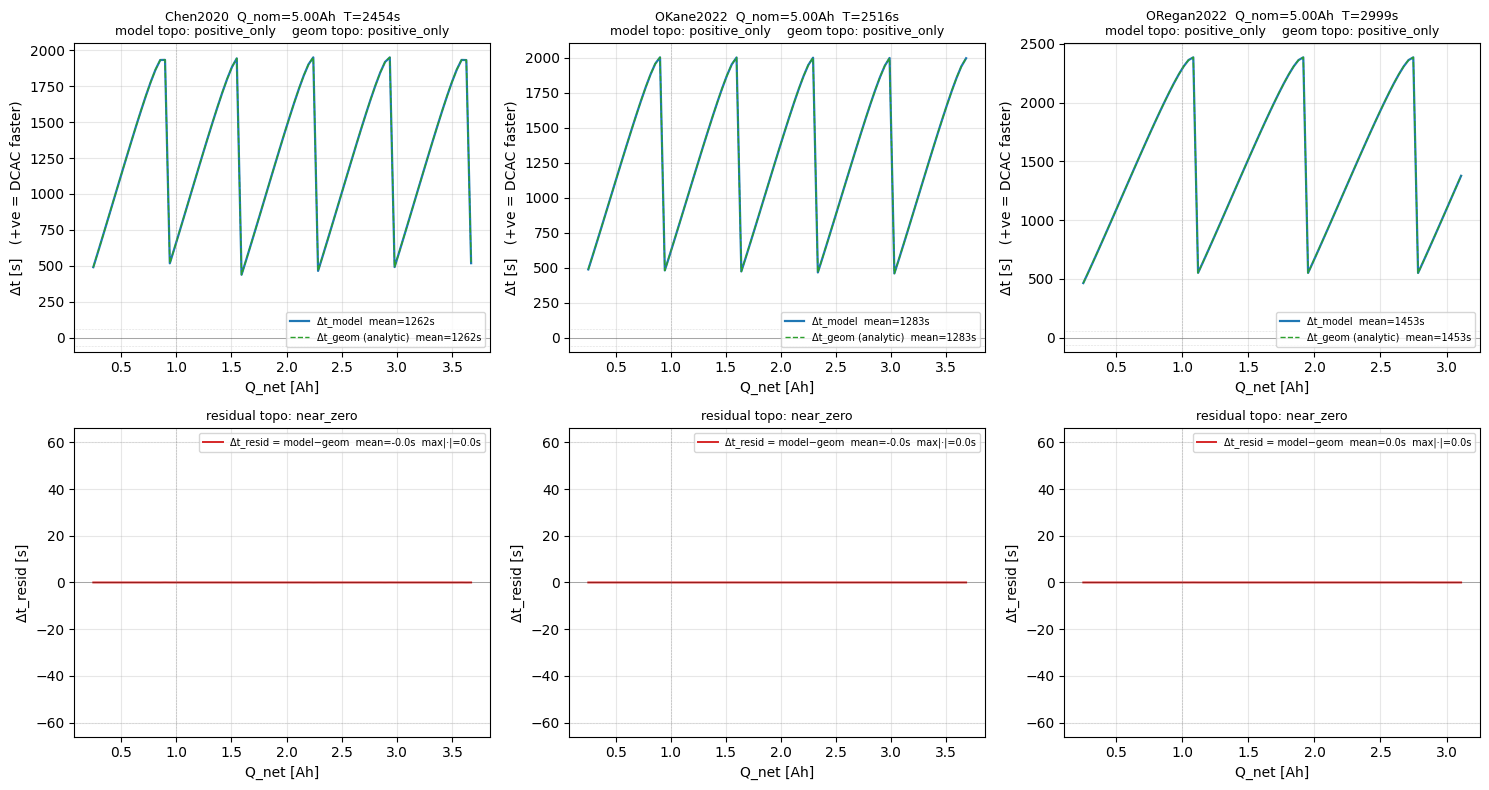


Wrote: figures/day18/day18_step2_dt_Q_audit_v4_charge_first.png

v4 distribution across 3 sets — RAW vs RESIDUAL topology
  full_sign_topology: {'positive_only': 3}
  full_resid_sign_topology: {'near_zero': 3}
  stable_sign_topology: {'positive_only': 3}
  stable_resid_sign_topology: {'near_zero': 3}

Interpretation rules for raw Δt(Q)  vs  residual Δt(Q):

  raw topology      |  residual topology  |  interpretation
  ------------------|---------------------|----------------------------------
  positive_only     |  near_zero          |  pure charge-first integration geometry
  negative_only     |  near_zero          |  pure discharge-first integration geometry
  positive_only     |  positive_only      |  possible non-geometric state-layer signal
  negative_only     |  negative_only      |  possible non-geometric state-layer signal (reverse sign)
  mixed             |  nonzero residual   |  trajectory-sensitive (boundary / event-region) effect
  any               |  large max_abs_s    

In [23]:
# Cell 4A v4 (revised) — Δt(Q) audit with geometry baseline + residual decomposition
# SCOPE: 3 smoke sets — Chen2020, OKane2022, ORegan2022 — under charge-first phase.
# Inputs:  data/day18_step1_phase_audit_*_v4_charge_first.{csv,npz}
# Outputs: data/day18_step2_dt_Q_audit_v4_charge_first.csv             (with geom + resid)
#          data/day18_step2_dt_Q_curves_long_v4_charge_first.csv.gz    (with dtQ_geom_s, dtQ_resid_s)
#          figures/day18/day18_step2_dt_Q_audit_v4_charge_first.png    (model/geom/resid)
#
# Method:
#   Δt_model(Q) = t_DC(Q) - t_DCAC(Q)              [from PyBaMM trajectories]
#   Δt_geom(Q)  = first-passage Δt on analytical   [pure current integration, no battery]
#   Δt_resid(Q) = Δt_model(Q) - Δt_geom(Q)         [non-geometric component]
#
# Only Δt_resid carries information beyond current-waveform geometry.
# v3 vs v4 comparison uses common Q-window q_hi = min(q_hi_v3, q_hi_v4).
# NO outcome predicted — topology must be measured.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

trapz = getattr(np, "trapezoid", getattr(np, "trapz", None))
assert trapz is not None

ROOT = Path("/Users/louislu/pybamm-dcac-superimposed")
DATA = ROOT / "data"
FIG  = ROOT / "figures" / "day18"
FIG.mkdir(parents=True, exist_ok=True)

traj_v4   = np.load(DATA / "day18_step1_phase_audit_trajectories_v4_charge_first.npz")
matrix_v4 = pd.read_csv(DATA / "day18_step1_phase_audit_matrix_v4_charge_first.csv")
traj_v3   = np.load(DATA / "day18_step1_anchor_trajectories_v3.npz")
matrix_v3 = pd.read_csv(DATA / "day18_step1_anchor_feasibility_matrix_v3.csv")

PROTOCOL_DC   = "DC_0p2C"
PROTOCOL_DCAC = "DCAC_DC0p2C_AC0p5C_10tau"
ANCHOR_LABEL  = "Route2_AC0p5C_10tau_native_charge_first"
PHASE_V4      = "charge_first"
PHASE_V3      = "discharge_first"
DC_RATE_CR    = 0.2
AC_RATE_CR    = 0.5

fdc   = set(matrix_v4.query(f"protocol == '{PROTOCOL_DC}'   and feasibility_verdict == 'feasible_clean'")["param_set"])
fdcac = set(matrix_v4.query(f"protocol == '{PROTOCOL_DCAC}' and feasibility_verdict == 'feasible_clean'")["param_set"])
FEASIBLE_SETS = sorted(fdc & fdcac)
print(f"Auto-derived FEASIBLE_SETS (v4, {len(FEASIBLE_SETS)}): {FEASIBLE_SETS}")

ABS_S_THRESH = 60.0
REL_THRESH   = 0.005

# ---- Helpers ---------------------------------------------------------------
def get_meta(matrix, set_name, protocol):
    row = matrix[(matrix["param_set"] == set_name) & (matrix["protocol"] == protocol)]
    assert len(row) == 1, f"Expected 1 row for {set_name}/{protocol}, got {len(row)}"
    return row.iloc[0].to_dict()

def get_traj(traj_npz, set_name, protocol):
    keys = [f"{set_name}__{protocol}__{k}" for k in ("t", "V", "I", "Q_net")]
    missing = [k for k in keys if k not in traj_npz.files]
    assert not missing, f"Missing keys: {missing}"
    return {"t": traj_npz[keys[0]], "V": traj_npz[keys[1]],
            "I": traj_npz[keys[2]], "Q_net": traj_npz[keys[3]]}

def first_passage_t(q_net, t, q_grid):
    out = np.full(len(q_grid), np.nan)
    for i, q in enumerate(q_grid):
        idx = np.flatnonzero(q_net >= q)
        if len(idx) == 0:
            continue
        k = idx[0]
        if k == 0:
            out[i] = t[0]
        else:
            q0, q1 = q_net[k-1], q_net[k]
            t0, t1 = t[k-1], t[k]
            out[i] = t0 + (q - q0) / (q1 - q0) * (t1 - t0) if q1 != q0 else t1
    return out

def q_charge_analytic(t, Q_nom_Ah, dc_c, ac_c, omega, phase):
    """Charging-positive Q(t) in Ah from prescribed current. PyBaMM convention:
    I_py > 0 = discharge, I_py < 0 = charge.
        charge_first:    I_py = -D - A sin(wt)  →  Q = ∫(D + A sin(wt)) dt / 3600
        discharge_first: I_py = -D + A sin(wt)  →  Q = ∫(D - A sin(wt)) dt / 3600
    """
    D = dc_c * Q_nom_Ah
    A = ac_c * Q_nom_Ah
    if phase == "charge_first":
        return (D * t + (A / omega) * (1 - np.cos(omega * t))) / 3600.0
    if phase == "discharge_first":
        return (D * t + (A / omega) * (np.cos(omega * t) - 1)) / 3600.0
    raise ValueError(f"Unknown phase: {phase}")

def classify_mean(mean_dt_s, t_dc_window_avg_s):
    abs_pass = abs(mean_dt_s) >= ABS_S_THRESH
    rel_pass = (t_dc_window_avg_s > 0) and (abs(mean_dt_s) / t_dc_window_avg_s >= REL_THRESH)
    if abs_pass and rel_pass:
        return "positive" if mean_dt_s > 0 else "negative"
    return "near_zero"

def sign_topology(dt_v, abs_thresh=ABS_S_THRESH):
    if len(dt_v) == 0: return "EMPTY"
    if np.max(np.abs(dt_v)) < abs_thresh: return "near_zero"
    pos = bool(np.any(dt_v > +abs_thresh))
    neg = bool(np.any(dt_v < -abs_thresh))
    if pos and not neg: return "positive_only"
    if neg and not pos: return "negative_only"
    return "mixed"

def n_zero_crossings(arr):
    if len(arr) < 2: return 0
    s = np.sign(arr); s[s == 0] = 1
    return int(np.sum(np.diff(s) != 0))

def window_metrics_with_decomp(q_v, dt_model, dt_geom, dt_resid, t_dc_v, prefix):
    """Window metrics including geometry baseline and residual decomposition."""
    if len(dt_model) < 2:
        return {f"{prefix}_n": int(len(dt_model)), f"{prefix}_status": "INSUFFICIENT"}
    dt_mean   = float(np.mean(dt_model))
    dt_geom_mean = float(np.mean(dt_geom))
    dt_resid_mean = float(np.mean(dt_resid))
    dt_resid_max_abs = float(np.max(np.abs(dt_resid)))
    t_dc_avg  = float(np.mean(t_dc_v))
    n_third = max(1, len(dt_model) // 3)
    return {
        f"{prefix}_n":                   int(len(dt_model)),
        f"{prefix}_status":              "OK",
        # Raw model
        f"{prefix}_mean_s":              dt_mean,
        f"{prefix}_median_s":            float(np.median(dt_model)),
        f"{prefix}_area_sAh":            float(trapz(dt_model, q_v)),
        f"{prefix}_min_s":               float(np.min(dt_model)),
        f"{prefix}_max_s":               float(np.max(dt_model)),
        f"{prefix}_range_s":             float(np.max(dt_model) - np.min(dt_model)),
        f"{prefix}_frac_positive":       float(np.mean(dt_model > 0)),
        f"{prefix}_frac_above_thr":      float(np.mean(dt_model > +ABS_S_THRESH)),
        f"{prefix}_frac_below_thr":      float(np.mean(dt_model < -ABS_S_THRESH)),
        f"{prefix}_n_cross":             n_zero_crossings(dt_model),
        f"{prefix}_mean_early_s":        float(np.mean(dt_model[:n_third])),
        f"{prefix}_mean_mid_s":          float(np.mean(dt_model[n_third:2*n_third])) if 2*n_third < len(dt_model) else float(np.mean(dt_model[n_third:])),
        f"{prefix}_mean_late_s":         float(np.mean(dt_model[2*n_third:])),
        f"{prefix}_t_dc_avg_s":          t_dc_avg,
        f"{prefix}_rel_signal_pct":      100 * dt_mean / t_dc_avg if t_dc_avg > 0 else np.nan,
        f"{prefix}_class_mean":          classify_mean(dt_mean, t_dc_avg),
        f"{prefix}_sign_topology":       sign_topology(dt_model),
        # Geometry baseline
        f"{prefix}_geom_mean_s":         dt_geom_mean,
        f"{prefix}_geom_sign_topology":  sign_topology(dt_geom),
        # Residual = model - geom
        f"{prefix}_resid_mean_s":        dt_resid_mean,
        f"{prefix}_resid_max_abs_s":     dt_resid_max_abs,
        f"{prefix}_resid_class_mean":    classify_mean(dt_resid_mean, t_dc_avg),
        f"{prefix}_resid_sign_topology": sign_topology(dt_resid),
    }

def compute_dt_decomposition(traj_npz, matrix, set_name, phase, q_grid_override=None):
    """Compute Δt_model, Δt_geom, Δt_resid on shared Q-grid for a given phase.
    Returns dict with q_v, dt_model_v, dt_geom_v, dt_resid_v, t_dc_v, t_dcac_v, q_lo_stable, Q_nom
    or None if infeasible."""
    try:
        dc_m   = get_meta(matrix, set_name, PROTOCOL_DC)
        dcac_m = get_meta(matrix, set_name, PROTOCOL_DCAC)
    except AssertionError:
        return None
    if pd.isna(dcac_m.get("Q_to_Vmax_Ah", np.nan)):
        return None
    dc   = get_traj(traj_npz, set_name, PROTOCOL_DC)
    dcac = get_traj(traj_npz, set_name, PROTOCOL_DCAC)

    Q_nom = dc_m["Q_nom_Ah"]
    omega = 2 * np.pi * dcac_m["f_anchor_Hz"]

    if q_grid_override is not None:
        q_grid = q_grid_override
        q_lo_stable = 0.20 * Q_nom
    else:
        q_lo_full = 0.05 * Q_nom
        q_lo_stable = 0.20 * Q_nom
        q_hi = min(dc_m["Q_to_Vmax_Ah"], dcac_m["Q_to_Vmax_Ah"]) - 0.02 * Q_nom
        if q_hi <= q_lo_full:
            return None
        q_grid = np.linspace(q_lo_full, q_hi, 80)

    # Model first-passage
    t_dc_q   = first_passage_t(dc["Q_net"],   dc["t"], q_grid)
    t_dcac_q = first_passage_t(dcac["Q_net"], dcac["t"], q_grid)
    dt_model = t_dc_q - t_dcac_q

    # Geometric first-passage on analytical Q(t) — fine grid (>=200 pts per period)
    t_max = max(float(dc["t"][-1]), float(dcac["t"][-1])) * 1.05
    T_period = dcac_m["T_anchor_s"]
    dt_geom_grid = min(T_period / 400.0, 5.0)
    t_geom = np.arange(0.0, t_max + dt_geom_grid, dt_geom_grid)

    Q_dc_geom   = q_charge_analytic(t_geom, Q_nom, DC_RATE_CR, 0.0,        omega, phase)
    Q_dcac_geom = q_charge_analytic(t_geom, Q_nom, DC_RATE_CR, AC_RATE_CR, omega, phase)

    t_dc_geom_q   = first_passage_t(Q_dc_geom,   t_geom, q_grid)
    t_dcac_geom_q = first_passage_t(Q_dcac_geom, t_geom, q_grid)
    dt_geom = t_dc_geom_q - t_dcac_geom_q

    valid = ~(np.isnan(t_dc_q) | np.isnan(t_dcac_q) |
              np.isnan(t_dc_geom_q) | np.isnan(t_dcac_geom_q))
    if valid.sum() < 2:
        return None

    q_v        = q_grid[valid]
    dt_model_v = dt_model[valid]
    dt_geom_v  = dt_geom[valid]
    dt_resid_v = dt_model_v - dt_geom_v
    t_dc_v     = t_dc_q[valid]
    t_dcac_v   = t_dcac_q[valid]

    return {
        "q_v": q_v, "dt_model_v": dt_model_v, "dt_geom_v": dt_geom_v,
        "dt_resid_v": dt_resid_v, "t_dc_v": t_dc_v, "t_dcac_v": t_dcac_v,
        "q_lo_stable": q_lo_stable, "Q_nom": Q_nom,
        "q_hi_natural": min(dc_m["Q_to_Vmax_Ah"], dcac_m["Q_to_Vmax_Ah"]) - 0.02 * Q_nom,
        "T_period_s": T_period, "f_anchor_Hz": dcac_m["f_anchor_Hz"],
        "Q_to_Vmax_DC": dc_m["Q_to_Vmax_Ah"], "Q_to_Vmax_DCAC": dcac_m["Q_to_Vmax_Ah"],
        "t_end_DC": dc_m["t_end_s"], "t_end_DCAC": dcac_m["t_end_s"],
    }

# ---- Per-set v4 main analysis (natural Q-window) ----------------------------
results, dt_curves_v4 = [], {}

for set_name in FEASIBLE_SETS:
    out = compute_dt_decomposition(traj_v4, matrix_v4, set_name, phase=PHASE_V4)
    if out is None:
        results.append({"param_set": set_name, "status": "INSUFFICIENT_GRID"})
        continue
    q_v          = out["q_v"]
    dt_model_v   = out["dt_model_v"]
    dt_geom_v    = out["dt_geom_v"]
    dt_resid_v   = out["dt_resid_v"]
    t_dc_v       = out["t_dc_v"]
    t_dcac_v     = out["t_dcac_v"]
    q_lo_stable  = out["q_lo_stable"]
    Q_nom        = out["Q_nom"]
    stable       = q_v >= q_lo_stable

    Q_sin_ripple = (AC_RATE_CR * Q_nom) / (2 * np.pi * out["f_anchor_Hz"] * 3600)

    full_m = window_metrics_with_decomp(q_v, dt_model_v, dt_geom_v, dt_resid_v,
                                         t_dc_v, prefix="full")
    if stable.sum() >= 2:
        stable_m = window_metrics_with_decomp(q_v[stable], dt_model_v[stable],
                                               dt_geom_v[stable], dt_resid_v[stable],
                                               t_dc_v[stable], prefix="stable")
    else:
        stable_m = {"stable_n": int(stable.sum()), "stable_status": "INSUFFICIENT"}

    row = {
        "param_set":                  set_name,
        "anchor_label":               ANCHOR_LABEL,
        "phase_label":                PHASE_V4,
        "Q_nom_Ah":                   Q_nom,
        "T_period_s":                 out["T_period_s"],
        "f_anchor_Hz":                out["f_anchor_Hz"],
        "Q_sinusoidal_ripple_amp_Ah": Q_sin_ripple,
        "rel_ripple_pct_window":      100 * Q_sin_ripple / (q_v[-1] - q_v[0]) if len(q_v) > 1 else np.nan,
        "q_lo_full_Ah":               float(q_v[0]),
        "q_lo_stable_added_Ah":       q_lo_stable,
        "q_hi_Ah":                    float(q_v[-1]),
        "stable_window_definition":   "Q_net >= 0.20*Q_nom from sim start (SOC0=0.05); NOT absolute SOC",
        "n_grid":                     80,
        "n_valid":                    int(len(q_v)),
        "t_end_DC_s":                 out["t_end_DC"],
        "t_end_DCAC_s":               out["t_end_DCAC"],
        "event_shift_s":              out["t_end_DC"] - out["t_end_DCAC"],
        "Q_to_Vmax_DC_Ah":            out["Q_to_Vmax_DC"],
        "Q_to_Vmax_DCAC_Ah":          out["Q_to_Vmax_DCAC"],
        "Q_to_Vmax_shift_Ah":         out["Q_to_Vmax_DCAC"] - out["Q_to_Vmax_DC"],
        "Q_to_Vmax_shift_pct":        (out["Q_to_Vmax_DCAC"] / out["Q_to_Vmax_DC"] - 1) * 100,
    }
    row.update(full_m)
    row.update(stable_m)
    results.append(row)

    dt_curves_v4[set_name] = out

results_df = pd.DataFrame(results)
results_csv = DATA / "day18_step2_dt_Q_audit_v4_charge_first.csv"
results_df.to_csv(results_csv, index=False)
print(f"\nWrote: {results_csv.relative_to(ROOT)}")

# ---- Long-format with model + geom + resid ---------------------------------
long_rows = []
for set_name, c in dt_curves_v4.items():
    for i, q in enumerate(c["q_v"]):
        long_rows.append({
            "param_set":           set_name,
            "anchor_label":        ANCHOR_LABEL,
            "phase_label":         PHASE_V4,
            "Q_Ah":                float(q),
            "Q_frac_nom_added":    float(q / c["Q_nom"]),
            "t_DC_s":              float(c["t_dc_v"][i]),
            "t_DCAC_s":            float(c["t_dcac_v"][i]),
            "dtQ_s":               float(c["dt_model_v"][i]),
            "dtQ_geom_s":          float(c["dt_geom_v"][i]),
            "dtQ_resid_s":         float(c["dt_resid_v"][i]),
            "window_full":         True,
            "window_stable_added": bool(q >= c["q_lo_stable"]),
            "protocol_DC":         PROTOCOL_DC,
            "protocol_DCAC":       PROTOCOL_DCAC,
            "status":              "OK",
        })
long_df = pd.DataFrame(long_rows)
long_csv = DATA / "day18_step2_dt_Q_curves_long_v4_charge_first.csv.gz"
long_df.to_csv(long_csv, index=False, compression="gzip")
print(f"Wrote: {long_csv.relative_to(ROOT)}  ({len(long_df)} rows)")

# ---- Display v4 main summary ------------------------------------------------
print("\n" + "=" * 130)
print(f"Cell 4A v4 — Δt(Q) audit on {ANCHOR_LABEL} (3-set smoke, natural Q-window)")
print("=" * 130)
disp_cols = ["param_set", "Q_to_Vmax_shift_pct",
             "full_mean_s", "full_geom_mean_s", "full_resid_mean_s", "full_resid_max_abs_s",
             "full_sign_topology", "full_resid_sign_topology",
             "stable_mean_s", "stable_geom_mean_s", "stable_resid_mean_s", "stable_resid_max_abs_s",
             "stable_sign_topology", "stable_resid_sign_topology"]
disp_cols = [c for c in disp_cols if c in results_df.columns]
with pd.option_context("display.max_columns", None, "display.width", 260,
                       "display.float_format", "{:.4g}".format):
    print(results_df[disp_cols].to_string(index=False))

# ---- v3 vs v4 comparison on COMMON Q-window --------------------------------
print("\n" + "=" * 130)
print("v3 vs v4 comparison — COMMON Q-window  q_hi = min(q_hi_v3, q_hi_v4)")
print("(geom + resid computed for each phase using its own analytical formula)")
print("=" * 130)

cmp_rows = []
for set_name in FEASIBLE_SETS:
    # First, compute on natural windows to get q_hi for each
    out_v4_nat = compute_dt_decomposition(traj_v4, matrix_v4, set_name, phase=PHASE_V4)
    out_v3_nat = compute_dt_decomposition(traj_v3, matrix_v3, set_name, phase=PHASE_V3)

    if out_v3_nat is None:
        cmp_rows.append({
            "param_set": set_name,
            "v3_status": "DCAC infeasible (boundary)",
            "common_q_hi_Ah": np.nan,
            "v3_full_mean_s": np.nan, "v3_geom_mean_s": np.nan, "v3_resid_mean_s": np.nan,
            "v3_topology": "N/A", "v3_resid_topology": "N/A",
            "v4_full_mean_s": np.nan, "v4_geom_mean_s": np.nan, "v4_resid_mean_s": np.nan,
            "v4_topology": "N/A", "v4_resid_topology": "N/A",
        })
        continue

    Q_nom = out_v4_nat["Q_nom"]
    q_lo_common = 0.05 * Q_nom
    q_hi_common = min(out_v3_nat["q_hi_natural"], out_v4_nat["q_hi_natural"])
    q_grid_common = np.linspace(q_lo_common, q_hi_common, 80)

    # Recompute on common grid
    out_v3_cmn = compute_dt_decomposition(traj_v3, matrix_v3, set_name,
                                            phase=PHASE_V3, q_grid_override=q_grid_common)
    out_v4_cmn = compute_dt_decomposition(traj_v4, matrix_v4, set_name,
                                            phase=PHASE_V4, q_grid_override=q_grid_common)

    cmp_rows.append({
        "param_set": set_name,
        "v3_status": "OK",
        "common_q_hi_Ah": float(q_hi_common),
        "v3_full_mean_s":   float(np.mean(out_v3_cmn["dt_model_v"])),
        "v3_geom_mean_s":   float(np.mean(out_v3_cmn["dt_geom_v"])),
        "v3_resid_mean_s":  float(np.mean(out_v3_cmn["dt_resid_v"])),
        "v3_resid_max_abs_s": float(np.max(np.abs(out_v3_cmn["dt_resid_v"]))),
        "v3_topology":      sign_topology(out_v3_cmn["dt_model_v"]),
        "v3_resid_topology": sign_topology(out_v3_cmn["dt_resid_v"]),
        "v4_full_mean_s":   float(np.mean(out_v4_cmn["dt_model_v"])),
        "v4_geom_mean_s":   float(np.mean(out_v4_cmn["dt_geom_v"])),
        "v4_resid_mean_s":  float(np.mean(out_v4_cmn["dt_resid_v"])),
        "v4_resid_max_abs_s": float(np.max(np.abs(out_v4_cmn["dt_resid_v"]))),
        "v4_topology":      sign_topology(out_v4_cmn["dt_model_v"]),
        "v4_resid_topology": sign_topology(out_v4_cmn["dt_resid_v"]),
    })

cmp_df = pd.DataFrame(cmp_rows)
with pd.option_context("display.max_columns", None, "display.width", 260,
                       "display.float_format", "{:.4g}".format):
    print(cmp_df.to_string(index=False))

cmp_csv = DATA / "day18_step2_dt_Q_v3_vs_v4_common_window.csv"
cmp_df.to_csv(cmp_csv, index=False)
print(f"\nWrote: {cmp_csv.relative_to(ROOT)}")

# ---- Multi-panel figure: model + geom + resid per set ---------------------
n = len(dt_curves_v4)
fig, axes = plt.subplots(2, n, figsize=(5.0 * n, 8.0), squeeze=False)

for idx, (set_name, c) in enumerate(dt_curves_v4.items()):
    row_data = next(r for r in results if r.get("param_set") == set_name and "full_mean_s" in r)

    # Top row: model vs geom overlay
    ax = axes[0, idx]
    ax.plot(c["q_v"], c["dt_model_v"], lw=1.6, color="C0",
            label=f"Δt_model  mean={row_data['full_mean_s']:.0f}s")
    ax.plot(c["q_v"], c["dt_geom_v"], lw=1.0, color="C2", linestyle="--",
            label=f"Δt_geom (analytic)  mean={row_data['full_geom_mean_s']:.0f}s")
    ax.axhline(0, color="black", lw=0.5, alpha=0.4)
    ax.axhline(+ABS_S_THRESH, color="gray", lw=0.4, ls=":", alpha=0.5)
    ax.axhline(-ABS_S_THRESH, color="gray", lw=0.4, ls=":", alpha=0.5)
    ax.axvline(c["q_lo_stable"], color="gray", lw=0.4, ls="--", alpha=0.5)
    ax.set_xlabel("Q_net [Ah]")
    ax.set_ylabel("Δt [s]   (+ve = DCAC faster)")
    ax.set_title(f"{set_name}  Q_nom={c['Q_nom']:.2f}Ah  T={c['T_period_s']:.0f}s\n"
                 f"model topo: {row_data['full_sign_topology']}    "
                 f"geom topo: {row_data['full_geom_sign_topology']}",
                 fontsize=9)
    ax.legend(fontsize=7, loc="best"); ax.grid(alpha=0.3)

    # Bottom row: residual = model - geom
    ax = axes[1, idx]
    ax.plot(c["q_v"], c["dt_resid_v"], lw=1.4, color="C3",
            label=f"Δt_resid = model−geom  mean={row_data['full_resid_mean_s']:.1f}s  "
                  f"max|·|={row_data['full_resid_max_abs_s']:.1f}s")
    ax.axhline(0, color="black", lw=0.5, alpha=0.4)
    ax.axhline(+ABS_S_THRESH, color="gray", lw=0.4, ls=":", alpha=0.5)
    ax.axhline(-ABS_S_THRESH, color="gray", lw=0.4, ls=":", alpha=0.5)
    ax.axvline(c["q_lo_stable"], color="gray", lw=0.4, ls="--", alpha=0.5)
    ax.set_xlabel("Q_net [Ah]")
    ax.set_ylabel("Δt_resid [s]")
    ax.set_title(f"residual topo: {row_data['full_resid_sign_topology']}",
                 fontsize=9)
    ax.legend(fontsize=7, loc="best"); ax.grid(alpha=0.3)

plt.tight_layout()
fig_path = FIG / "day18_step2_dt_Q_audit_v4_charge_first.png"
plt.savefig(fig_path, dpi=140)
plt.show()
print(f"\nWrote: {fig_path.relative_to(ROOT)}")

# ---- Distribution + interpretation -----------------------------------------
print("\n" + "=" * 130)
print(f"v4 distribution across {len(FEASIBLE_SETS)} sets — RAW vs RESIDUAL topology")
print("=" * 130)
for col in ["full_sign_topology", "full_resid_sign_topology",
            "stable_sign_topology", "stable_resid_sign_topology"]:
    if col in results_df.columns:
        counts = results_df[col].value_counts(dropna=False).to_dict()
        print(f"  {col}: {counts}")

print("""
============================================================================
Interpretation rules for raw Δt(Q)  vs  residual Δt(Q):

  raw topology      |  residual topology  |  interpretation
  ------------------|---------------------|----------------------------------
  positive_only     |  near_zero          |  pure charge-first integration geometry
  negative_only     |  near_zero          |  pure discharge-first integration geometry
  positive_only     |  positive_only      |  possible non-geometric state-layer signal
  negative_only     |  negative_only      |  possible non-geometric state-layer signal (reverse sign)
  mixed             |  nonzero residual   |  trajectory-sensitive (boundary / event-region) effect
  any               |  large max_abs_s    |  solver discretization or window edge effect

Rule:
  In current-controlled simulation, Q_net(t) is determined entirely by the
  applied current waveform; any difference between Δt_model and Δt_geom must
  come from interpolation / discretization / Q-window edge effects, NOT from
  electrochemical state-layer dynamics. A near-zero residual confirms this.

  Cell 3C established event-layer Vmax pull-forward via V envelope analysis.
  Cell 4A v4 separates current-waveform first-passage geometry from any
  residual contribution by comparing Δt_model(Q) against Δt_geom(Q). Only
  Δt_resid(Q), not raw Δt(Q), can be used to discuss non-geometric state-layer
  effects under imposed-current CC conditions.
============================================================================
""")

# Cell 4A v4 Close — Geometry-Residual Audit for Charge-First Smoke Test

## Scope

This cell audited the Route-2 charge-first smoke-test branch:

```text
Anchor: Route2_AC0p5C_10tau_native_charge_first
Sets:   Chen2020, OKane2022, ORegan2022
Mode:   prescribed-current CC segment
```

The purpose was not to close Day 18, but to test whether the positive raw Δt(Q) observed under the charge-first phase contains any non-geometric state-layer contribution.

---

## Definitions

The raw state-equivalent time difference was computed as:

```text
Δt_model(Q) = t_DC(Q) − t_DCAC(Q)
```

For prescribed-current CC operation, the corresponding analytical current-geometry baseline was also computed:

```text
Δt_geom(Q)
```

The residual was defined as:

```text
Δt_resid(Q) = Δt_model(Q) − Δt_geom(Q)
```

Interpretation:

```text
raw Δt_model(Q): includes imposed-current first-passage geometry
Δt_geom(Q):      analytical contribution from the prescribed current waveform
Δt_resid(Q):     non-geometric residual after removing current-waveform geometry
```

---

## Result

For all three smoke-test parameter sets:

```text
Chen2020
OKane2022
ORegan2022
```

the raw Δt(Q) was positive-only under charge-first phase, but it was exactly reproduced by the analytical geometry baseline.

Observed pattern:

```text
Δt_model(Q) ≈ Δt_geom(Q)
Δt_resid(Q) ≈ 0
```

Numerically:

```text
max |Δt_resid(Q)| < 0.05 s
```

across the evaluated Q-grid.

Therefore:

```text
The positive raw Δt(Q) under charge-first phase is a prescribed-current
first-passage geometry effect, not evidence of non-geometric state-layer
acceleration in the PyBaMM model.
```

---

## Phase interpretation

Together with the v3 discharge-first branch:

```text
v3 discharge-first:
  raw Δt(Q) = negative_only
  Δt_resid(Q) ≈ 0

v4 charge-first:
  raw Δt(Q) = positive_only
  Δt_resid(Q) ≈ 0
```

This shows that the sign of raw Δt(Q) is controlled by the initial AC phase when comparing DC and DCAC under prescribed-current CC operation.

Thus:

```text
raw Δt(Q) is phase-controlled;
Δt_resid(Q) is the relevant non-geometric state-layer observable.
```

---

## Relation to Cell 3C

Cell 3C showed that the earlier Vmax events in Chen2020 and OKane2022 were consistent with event-layer voltage pull-forward:

```text
DCAC voltage envelope elevated at same first-passage Q
Vmax reached at substantially lower Q_to_Vmax than DC
```

Cell 4A v4 adds that the apparent positive raw Δt(Q) under charge-first phase is also geometric.

Combined interpretation:

```text
Event-layer voltage pull-forward exists.
Raw Δt(Q) can be positive under charge-first phase.
But the positive raw Δt(Q) is fully explained by current-waveform geometry.
No non-geometric state-layer acceleration is resolved at this anchor.
```

---

## Local verdict

```text
Cell 4A v4 verdict:
  raw Δt(Q):       positive_only
  geometry Δt(Q):  positive_only
  residual Δt(Q):  near_zero
```

Conclusion:

```text
Route2_AC0p5C_10tau_native_charge_first does not support
non-geometric state-layer DCAC acceleration in the 3-set smoke test.
```

This is an anchor-level result only.

---

## Methodological rule established by Cell 4A v4

For DC-vs-DCAC comparisons in prescribed-current CC mode:

```text
Always compute:
1. raw Δt_model(Q)
2. analytical Δt_geom(Q)
3. residual Δt_resid(Q) = Δt_model(Q) − Δt_geom(Q)
```

Only `Δt_resid(Q)` can be used to discuss non-geometric state-layer effects.

Raw Δt(Q) alone is not sufficient because it can be dominated by the imposed current waveform.

---

## Consequence for Day 18

Do not open the aging branch yet.

Reason:

```text
The tested Route-2 anchor does not show positive non-geometric Δt_resid(Q).
```

Instead, Day 18 should continue as:

```text
Day 18B — geometry-corrected protocol matrix audit
```

Next planned protocol groups:

```text
0.2C + 0.4C @ 0.1τ / 1τ / 10τ
0.4C + 0.6C @ 0.1τ / 1τ / 10τ
```

Main branch:

```text
charge-first phase
tau95_eq frequency rebasing
geometry-corrected Δt_resid(Q)
```

Next cell:

```text
Cell 5A — Build Day18B geometry-corrected protocol matrix design table
```

Do not run the full simulation matrix before reviewing the design table.

In [25]:
# Cell 5A v3 — Day18B geometry-corrected protocol matrix design table
# DESIGN ONLY — no PyBaMM simulation. Builds and saves the protocol matrix,
# computes per-row feasibility risk + estimated wall time, flags concerns.
#
# Output:
#   data/day18B_protocol_design_full.csv     (8 sets × 8 protocols = 64 rows)
#   data/day18B_protocol_design_smoke.csv    (3 sets × 8 protocols = 24 rows)
#
# Primary metric for Day18B: Δt_resid(Q) = Δt_model(Q) − Δt_geom(Q).
# Raw Δt(Q) is NOT the verdict variable for Day18B per Cell 4A v4 finding.

import numpy as np
import pandas as pd
from pathlib import Path

ROOT = Path("/Users/louislu/pybamm-dcac-superimposed")
DATA = ROOT / "data"

# ---- Read morning's anchor matrix to get tau95_eq, V cutoffs, Q_nom -------
# CURRENT SOURCE: day18_step1_anchor_feasibility_matrix_v3.csv (DC_0p2C rows
# carry tau95_eq_s, Q_nom_Ah, V_max/min_cutoff). Self-contained.
#
# TODO (workflow lineage cleanup): when this becomes a formal pipeline,
# switch to:
#   tau95_eq_s   ← data/day18_step0c_frequency_design_route2_tau95eq.csv
#                  (descriptor design source, not a simulation result)
#   Q_nom + V cutoffs ← pybamm.ParameterValues(set_name)
# Cleaner data lineage: descriptor → protocol design → simulation output.
matrix_v3 = pd.read_csv(DATA / "day18_step1_anchor_feasibility_matrix_v3.csv")

ALL_SETS = ["Ecker2015", "Mohtat2020", "NCA_Kim2011", "Ai2020",
            "Chen2020", "OKane2022", "Marquis2019", "ORegan2022"]
SMOKE_SETS = ["Ecker2015", "Chen2020", "ORegan2022"]

# ---- Protocol catalogue ----------------------------------------------------
DC_GROUPS = [
    {"DC_C": 0.2, "AC_C": 0.4, "kappa": 2.0, "label_dc": "0p2C", "label_ac": "0p4C"},
    {"DC_C": 0.4, "AC_C": 0.6, "kappa": 1.5, "label_dc": "0p4C", "label_ac": "0p6C"},
]
N_TAU_LIST = [(0.1, "0p1tau"), (1.0, "1tau"), (10.0, "10tau")]
PHASE_LABEL = "charge_first"

CURRENT_FORMULA_DCAC = "I_py = -I_DC - I_AC * pybamm.sin(omega * t)"   # charge-first
CURRENT_FORMULA_DC   = "I_py = -I_DC"

# ---- Per-set anchor parameters --------------------------------------------
def get_set_meta(set_name):
    row = matrix_v3[(matrix_v3["param_set"] == set_name) &
                    (matrix_v3["protocol"] == "DC_0p2C")]
    if len(row) != 1:
        return None
    r = row.iloc[0]
    return {
        "Q_nom_Ah":     float(r["Q_nom_Ah"]),
        "tau95_eq_s":   float(r["tau95_eq_s"]),
        "V_max_cutoff": float(r["V_max_cutoff"]),
        "V_min_cutoff": float(r["V_min_cutoff"]),
    }

# ---- Analytical lobe exposure --------------------------------------------
def lobe_q_frac(D, A, T_period_s):
    """Positive-current (discharge) lobe magnitude per period, normalized by Q_nom.

    For CHARGE-FIRST current convention:
        I(t)/Q_nom = -D - A·sin(ωt)
        positive (discharge) when sin(ωt) < -D/A
        → discharge half occurs in NEGATIVE-sine portion of the cycle
        → spans ωt ∈ (π + arcsin(D/A), 2π - arcsin(D/A))

    The integral is symmetric to the discharge-first case (positive-sine
    half), so the closed-form factor below applies to either phase. Only
    the location of the lobe within the cycle differs.

    factor = (2A·cos(θ₀) − D·(π − 2θ₀)) / (2π),  θ₀ = arcsin(D/A)
    Q_lobe / Q_nom per period = factor × T(s) / 3600

    Only meaningful when A > D (kappa > 1). Returns 0 otherwise.
    """
    if A <= D:
        return 0.0
    theta0 = np.arcsin(D / A)
    factor = (2 * A * np.cos(theta0) - D * (np.pi - 2 * theta0)) / (2 * np.pi)
    return factor * T_period_s / 3600.0

# ---- Estimated wall-time model -------------------------------------------
# Calibrated from morning runs: ~1.5–3.2 s for DC at dt_eval=10s (≈1700 output
# points). Implies ~1.0e-3 s/output-point as a coarse proxy for wall cost.
# NOTE: t_eval points are OUTPUT sampling points, NOT internal solver steps.
WALL_PER_OUTPUT_POINT_S = 1.2e-3

def est_wall_s(set_name, t_total_s, dt_eval_max_s):
    n_output = max(100, int(t_total_s / dt_eval_max_s))
    base = n_output * WALL_PER_OUTPUT_POINT_S
    scale = 2.0 if set_name == "ORegan2022" else 1.0
    return base * scale, n_output

def est_t_total_s(DC_C):
    """Rough estimate: t_end ≈ Q_to_Vmax / I_DC × 3600.
    Morning data: DC=0.2C → ~17000 s; DC=0.4C → ~8500 s (linear scaling)."""
    return 17000.0 / (DC_C / 0.2)

# ---- Build matrix --------------------------------------------------------
rows = []
for set_name in ALL_SETS:
    sm = get_set_meta(set_name)
    if sm is None:
        print(f"WARNING: {set_name} not found in v3 matrix")
        continue
    Q_nom = sm["Q_nom_Ah"]
    tau95 = sm["tau95_eq_s"]
    V_max = sm["V_max_cutoff"]
    V_min = sm["V_min_cutoff"]

    # DC baselines
    for grp in DC_GROUPS:
        DC = grp["DC_C"]
        I_DC = DC * Q_nom
        t_total = est_t_total_s(DC)
        dt_eval = 10.0
        wall_s, n_out = est_wall_s(set_name, t_total, dt_eval)
        rows.append({
            "param_set": set_name, "Q_nom_Ah": Q_nom, "tau95_eq_s": tau95,
            "V_max_cutoff": V_max, "V_min_cutoff": V_min,
            "protocol_label": f"DC_{grp['label_dc']}",
            "protocol_type": "DC",
            "phase_label":  PHASE_LABEL,
            "current_formula": CURRENT_FORMULA_DC,
            "DC_C": DC, "AC_C": 0.0, "kappa": 0.0, "n_tau": np.nan,
            "T_period_s": np.nan, "f_anchor_Hz": np.nan,
            "I_DC_A": I_DC, "I_AC_A": 0.0,
            "I_peak_charge_A":    -I_DC, "I_peak_discharge_A":  0.0,
            "I_peak_charge_C":    -DC,   "I_peak_discharge_C":  0.0,
            "peak_current_constraint_margin_C": 1.0 - DC,
            "dt_eval_max_s": dt_eval,
            "est_t_total_s": t_total,
            "est_output_points": n_out,
            "est_wall_s":   wall_s,
            "Q_sin_ripple_amp_Ah": 0.0, "Q_lobe_per_period_Ah": 0.0,
            "Q_lobe_Q_frac": 0.0,
            "smoke_member": (set_name in SMOKE_SETS),
        })

    # DCAC protocols
    for grp in DC_GROUPS:
        DC, AC = grp["DC_C"], grp["AC_C"]
        kappa = grp["kappa"]
        I_DC = DC * Q_nom
        I_AC = AC * Q_nom
        I_pk_chg  = -(DC + AC)
        I_pk_dchg = -(DC - AC)
        for n_tau, n_tau_label in N_TAU_LIST:
            T_period = 2 * np.pi * n_tau * tau95
            f_anchor = 1.0 / T_period
            omega    = 2 * np.pi * f_anchor
            dt_eval  = min(10.0, T_period / 100.0)
            t_total  = est_t_total_s(DC)
            wall_s, n_out = est_wall_s(set_name, t_total, dt_eval)
            Q_sin_ripple = I_AC / (omega * 3600.0)
            Q_lobe_frac  = lobe_q_frac(DC, AC, T_period)
            rows.append({
                "param_set": set_name, "Q_nom_Ah": Q_nom, "tau95_eq_s": tau95,
                "V_max_cutoff": V_max, "V_min_cutoff": V_min,
                "protocol_label": f"DCAC_DC{grp['label_dc']}_AC{grp['label_ac']}_{n_tau_label}",
                "protocol_type": "DCAC",
                "phase_label":   PHASE_LABEL,
                "current_formula": CURRENT_FORMULA_DCAC,
                "DC_C": DC, "AC_C": AC, "kappa": kappa, "n_tau": n_tau,
                "T_period_s": T_period, "f_anchor_Hz": f_anchor,
                "I_DC_A": I_DC, "I_AC_A": I_AC,
                "I_peak_charge_A":    -(I_DC + I_AC),
                "I_peak_discharge_A": -(I_DC - I_AC),
                "I_peak_charge_C":    I_pk_chg,
                "I_peak_discharge_C": I_pk_dchg,
                "peak_current_constraint_margin_C": 1.0 - (DC + AC),
                "dt_eval_max_s": dt_eval,
                "est_t_total_s": t_total,
                "est_output_points": n_out,
                "est_wall_s":   wall_s,
                "Q_sin_ripple_amp_Ah": Q_sin_ripple,
                "Q_lobe_per_period_Ah": Q_lobe_frac * Q_nom,
                "Q_lobe_Q_frac": Q_lobe_frac,
                "smoke_member": (set_name in SMOKE_SETS),
            })

design_df = pd.DataFrame(rows)

# ---- Risk classification --------------------------------------------------
def classify_feasibility_risk(row):
    if row["protocol_type"] == "DC":
        return "low"
    qf = row["Q_lobe_Q_frac"]
    if qf < 0.02: return "low"
    if qf < 0.05: return "medium"
    return "high"

def classify_compute_risk(row):
    wall = row["est_wall_s"]
    if wall < 10: return "low"
    if wall < 60: return "medium"
    return "high"

design_df["feasibility_risk"] = design_df.apply(classify_feasibility_risk, axis=1)
design_df["compute_risk"]     = design_df.apply(classify_compute_risk,     axis=1)

# ---- Pre-save audit: max Q_lobe_Q_frac across DCAC rows --------------------
dcac_rows = design_df.query("protocol_type == 'DCAC'")
max_lobe_idx = dcac_rows["Q_lobe_Q_frac"].idxmax()
max_lobe_row = design_df.loc[max_lobe_idx]
max_lobe = float(max_lobe_row["Q_lobe_Q_frac"])
n_above_5pct  = int((dcac_rows["Q_lobe_Q_frac"] > 0.05).sum())
n_above_2pct  = int((dcac_rows["Q_lobe_Q_frac"] > 0.02).sum())
n_dcac_total  = int(len(dcac_rows))

print(f"--- Q_lobe_Q_frac audit across {n_dcac_total} DCAC rows ---")
print(f"  max  = {max_lobe:.4f}  ({max_lobe*100:.2f} % of Q_nom per period)")
print(f"  > 5% Q_nom (high risk):    {n_above_5pct} / {n_dcac_total}")
print(f"  > 2% Q_nom (medium risk):  {n_above_2pct} / {n_dcac_total}")
print(f"  argmax row: {max_lobe_row['param_set']}  {max_lobe_row['protocol_label']}  "
      f"feasibility_risk={max_lobe_row['feasibility_risk']}")

# Build data-driven feasibility verdict text for the concerns block below
if n_above_5pct == 0:
    feasibility_text = (
        f"Q_lobe_Q_frac ≤ {max_lobe:.4f} ({max_lobe*100:.2f}% of Q_nom) across all "
        f"{n_dcac_total} DCAC rows under charge-first phase.  No row exceeds the "
        f"5% boundary-confounded threshold from morning v3."
    )
elif n_above_5pct < n_dcac_total:
    high_rows = dcac_rows[dcac_rows["Q_lobe_Q_frac"] > 0.05][
        ["param_set", "protocol_label", "Q_lobe_Q_frac"]]
    feasibility_text = (
        f"Q_lobe_Q_frac mostly below 0.05, but {n_above_5pct} / {n_dcac_total} "
        f"DCAC rows exceed it (high feasibility risk):\n"
        + high_rows.to_string(index=False)
    )
else:
    feasibility_text = (
        f"All {n_dcac_total} DCAC rows have Q_lobe_Q_frac > 0.05 — protocol design "
        f"needs reconsideration before any simulation."
    )

# ---- Save -----------------------------------------------------------------
full_csv = DATA / "day18B_protocol_design_full.csv"
design_df.to_csv(full_csv, index=False)
print(f"\nWrote: {full_csv.relative_to(ROOT)}  ({len(design_df)} rows)")

smoke_csv = DATA / "day18B_protocol_design_smoke.csv"
design_df[design_df["smoke_member"]].to_csv(smoke_csv, index=False)
print(f"Wrote: {smoke_csv.relative_to(ROOT)}  ({design_df['smoke_member'].sum()} rows)")

# ---- Summary printout -----------------------------------------------------
print("\n" + "=" * 130)
print("Day18B protocol matrix — design summary  (charge-first phase, tau95_eq frequency rebasing)")
print("=" * 130)

print(f"\nN_sets:       {len(ALL_SETS)} full   /   {len(SMOKE_SETS)} smoke ({SMOKE_SETS})")
print(f"N_protocols:  {2 + len(DC_GROUPS) * len(N_TAU_LIST)} per set "
      f"({len(DC_GROUPS)} DC baselines + {len(DC_GROUPS) * len(N_TAU_LIST)} DCAC protocols)")
print(f"Total rows:   {len(design_df)} full   /   {design_df['smoke_member'].sum()} smoke")

print("\n--- Wall-time aggregates (estimated; output-point cost proxy, NOT solver-step count) ---")
total_full  = design_df["est_wall_s"].sum()
total_smoke = design_df.loc[design_df["smoke_member"], "est_wall_s"].sum()
print(f"  Full sweep:  ~{total_full/60:.1f} min  ({total_full:.0f} s)")
print(f"  Smoke run:   ~{total_smoke/60:.1f} min  ({total_smoke:.0f} s)")

print("\n--- Per-protocol wall-time ranges across sets (DCAC only) ---")
prot_summary = (design_df.query("protocol_type == 'DCAC'")
                .groupby(["DC_C", "n_tau"])["est_wall_s"]
                .agg(["min", "median", "max", "sum"])
                .round(1))
with pd.option_context("display.float_format", "{:.1f}".format):
    print(prot_summary.to_string())

print("\n--- Per-set total wall-time (8 protocols each) ---")
set_wall = design_df.groupby("param_set")["est_wall_s"].sum().sort_values()
for s, w in set_wall.items():
    flag = " ← smoke" if s in SMOKE_SETS else ""
    print(f"  {s:14s}: {w:6.1f} s ({w/60:.1f} min){flag}")

print("\n--- Feasibility risk (analytical lobe exposure under charge-first phase) ---")
print(design_df.pivot_table(index="protocol_label", columns="feasibility_risk",
                             aggfunc="size", fill_value=0).to_string())

print("\n--- Compute risk distribution ---")
print(design_df.pivot_table(index="protocol_label", columns="compute_risk",
                             aggfunc="size", fill_value=0).to_string())

print("\n--- Peak-current constraint margin ---")
print(design_df.groupby("protocol_label")["peak_current_constraint_margin_C"].first()
      .to_frame("margin_C").to_string())

# ---- Smoke-set view -----------------------------------------------------------
print("\n" + "=" * 130)
print("SMOKE SUBSET — 3 sets × 8 protocols = 24 simulations")
print("=" * 130)
disp_cols = ["param_set", "protocol_label", "current_formula",
             "DC_C", "AC_C", "kappa", "n_tau",
             "T_period_s", "f_anchor_Hz", "dt_eval_max_s",
             "Q_sin_ripple_amp_Ah", "Q_lobe_Q_frac",
             "peak_current_constraint_margin_C",
             "est_output_points", "est_wall_s",
             "feasibility_risk", "compute_risk"]
smoke_view = design_df[design_df["smoke_member"]][disp_cols].copy()
with pd.option_context("display.max_columns", None, "display.width", 260,
                       "display.float_format", "{:.4g}".format):
    print(smoke_view.to_string(index=False))

# ---- Pre-execution concerns (data-driven) ---------------------------------
print(f"""
============================================================================
Pre-execution concerns to weigh BEFORE Cell 5B (smoke simulation):

(1) 0.1τ output-point density at short-T cells (Ecker2015):
    T_period = 2π × 0.1 × 16.35 s ≈ 10.3 s → dt_eval ≈ 0.10 s
    For t_total ~17000 s this requests ~170,000 output points per sim.
    These are OUTPUT sampling points, not internal solver steps; IDAKLU
    adapts its own internal stepping. Wall-time penalty is real but smaller
    than a naive step-count product would suggest. Wall estimate above is
    a conservative upper bound; actual cost may be 30–60% of estimate.

(2) Geometric Δt amplitude scales with T_period:
    Δt_geom_amplitude ≈ I_AC / (I_DC · ω) ∝ T_period
    At 0.1τ, the geometric baseline is ~100× smaller than at 10τ.
    Relative residual sensitivity is therefore highest at LONG τ; numerical
    noise dominance is highest at SHORT τ. The 0.1τ residual measurement
    is the noisiest test of the 'no state-layer signal' claim. The strongest
    test of non-geometric residual is at 10τ, not 0.1τ.

(3) Charge-first feasibility (analytical, prior to simulation):
    {feasibility_text}
    Vmax_event will fire at ~17000 s (DC=0.2C) or ~8500 s (DC=0.4C) by DC
    saturation; DCAC may fire earlier due to AC peak voltage pull-forward.

(4) Group B (DC=0.4C, AC=0.6C) has peak charge = -1.0C, margin = 0.0C.
    Sits exactly at the |DC|+|AC| ≤ 1C constraint. Any future protocol
    extension above this needs explicit boundary acknowledgement.

(5) Pause point BEFORE Cell 5B:
    - Confirm wall-time budget is acceptable (smoke ~{total_smoke/60:.1f} min predicted).
    - Confirm Cell 5B model builder matches Cell 3D v2 exactly
      (no plating option; plain pybamm.lithium_ion.DFN()).
    - Confirm phase = charge-first applied uniformly via current_formula.
    - Recommendation: run smoke (24 sims) first, NOT direct full (64 sims).

(6) Output schema for Cell 5B / 5C (downstream Δt audit):
    Each protocol must save raw Δt_model(Q), Δt_geom(Q), Δt_resid(Q).
    Verdict variable: Δt_resid topology and max_abs_s, NOT raw Δt(Q).
    Only protocols with non-trivial Δt_resid warrant deeper investigation.
============================================================================
""")

--- Q_lobe_Q_frac audit across 48 DCAC rows ---
  max  = 0.0363  (3.63 % of Q_nom per period)
  > 5% Q_nom (high risk):    0 / 48
  > 2% Q_nom (medium risk):  13 / 48
  argmax row: ORegan2022  DCAC_DC0p2C_AC0p4C_10tau  feasibility_risk=medium

Wrote: data/day18B_protocol_design_full.csv  (64 rows)
Wrote: data/day18B_protocol_design_smoke.csv  (24 rows)

Day18B protocol matrix — design summary  (charge-first phase, tau95_eq frequency rebasing)

N_sets:       8 full   /   3 smoke (['Ecker2015', 'Chen2020', 'ORegan2022'])
N_protocols:  8 per set (2 DC baselines + 6 DCAC protocols)
Total rows:   64 full   /   24 smoke

--- Wall-time aggregates (estimated; output-point cost proxy, NOT solver-step count) ---
  Full sweep:  ~24.6 min  (1478 s)
  Smoke run:   ~11.9 min  (714 s)

--- Per-protocol wall-time ranges across sets (DCAC only) ---
            min  median   max   sum
DC_C n_tau                         
0.2  0.1   77.8    88.9 198.6 862.5
     1.0    7.8     8.9  19.9  86.2
     10.0   

In [26]:
# Cell 5B v2 — Day 18B smoke simulation
# 24 sims (3 sets × 8 protocols, charge-first only).
# Save full trajectories (t, V, I, Q_net) + metadata for Cell 5C to compute
# Δt_model, Δt_geom, Δt_resid without rerunning.
#
# v2 vs v1: 4 MATCH-CHECK fixes against Cell 3D v2:
#   (1) SOC init via initial_soc=SOC0 in sim.solve()  (not set_initial_stoichiometries)
#   (2) DC current_fn returns -I_DC + 0*t            (symbolic-backend safe)
#   (3) Solver passed to Simulation() constructor    (not to sim.solve())
#   (4) get_voltage_entries() helper with Voltage / Terminal voltage fallback
# Plus: termination keywords, verdict naming, frac_below_Vmin gate, phase sanity
#       metrics — all aligned with Cell 3D v2.
#
# Outputs:
#   data/day18B_smoke/{set_name}__{protocol_label}.npz  (24 trajectory NPZs)
#   data/day18B_smoke_metadata.csv                      (24-row meta table)

import pybamm
import numpy as np
import pandas as pd
from pathlib import Path
import time
import traceback

ROOT = Path("/Users/louislu/pybamm-dcac-superimposed")
DATA = ROOT / "data"
OUTDIR = DATA / "day18B_smoke"
OUTDIR.mkdir(parents=True, exist_ok=True)

# Project convention: numpy 2.x trapezoid shim
trapz = getattr(np, "trapezoid", getattr(np, "trapz", None))

SOC0 = 0.05  # match Cell 3D v2

# ---- Read smoke design table ---------------------------------------------
smoke_df = pd.read_csv(DATA / "day18B_protocol_design_smoke.csv")
N_SIMS = len(smoke_df)
EST_TOTAL_WALL_S = float(smoke_df["est_wall_s"].sum())

print(f"Cell 5B v2 — Day 18B smoke run")
print(f"  PyBaMM:        {pybamm.__version__}")
print(f"  N simulations: {N_SIMS}")
print(f"  Estimated wall: {EST_TOTAL_WALL_S:.0f} s ({EST_TOTAL_WALL_S/60:.1f} min) [conservative upper bound]")
print(f"  Output dir:    {OUTDIR.relative_to(ROOT)}")
print("=" * 80)

# ---- Helpers (mirror Cell 3D v2) ------------------------------------------
def get_voltage_entries(sol):
    """v3-compatible voltage extraction. Try common PyBaMM names."""
    for name in ("Voltage [V]", "Terminal voltage [V]"):
        try:
            return np.asarray(sol[name].entries)
        except KeyError:
            continue
    raise KeyError("No voltage variable found in solution.")

def make_current_DC(I_dc_A):
    """DC charging. + 0 * t is required for symbolic-backend safety."""
    def current_fn(t, _I_dc=I_dc_A):
        return -_I_dc + 0 * t
    return current_fn

def make_current_DCAC_charge_first(I_dc_A, I_ac_A, omega_rad_s):
    """Charge-first: I = -I_DC - I_AC*sin(omega*t).
    At t=0+, AC reinforces charging (-I_DC - I_AC*small_positive_sin)."""
    def current_fn(t, _I_dc=I_dc_A, _I_ac=I_ac_A, _w=omega_rad_s):
        return -_I_dc - _I_ac * pybamm.sin(_w * t)
    return current_fn

def compute_Q_net_strict(t_arr, I_arr):
    """Strict-net Q_net = -∫I dt / 3600 (charging-positive, trapezoidal).
    Definitionally consistent with q_charge_analytic() in Cell 4A v4 — required
    for Δt_resid = Δt_model − Δt_geom to be a valid difference."""
    dQ = -0.5 * (I_arr[:-1] + I_arr[1:]) * np.diff(t_arr) / 3600.0
    return np.concatenate([[0.0], np.cumsum(dQ)])

def classify_termination(sol, V_arr, V_max_cutoff, V_min_cutoff):
    """Mirror Cell 3D v2 keywords. Prefer sol.termination string;
    fall back to final-voltage heuristic."""
    raw = str(getattr(sol, "termination", "")).lower()
    if "maximum voltage" in raw or "vmax" in raw:
        return "Vmax_event", raw
    if "minimum voltage" in raw or "vmin" in raw:
        return "Vmin_event", raw
    if "final time" in raw or "t_eval" in raw:
        return "final_time", raw
    if V_arr[-1] >= V_max_cutoff - 5e-3:
        return "Vmax_event_inferred", raw
    if V_arr[-1] <= V_min_cutoff + 5e-3:
        return "Vmin_event_inferred", raw
    return "unknown", raw

def phase_sanity_metrics(t_arr, I_arr, T_period_s, Q_nom_Ah):
    """Per-sim verification that charge-first phase was correctly applied.
    Charge-first expectations (DCAC, smoke):
      I_initial_C        ≈ -DC_C       (sin(0) = 0)
      I_first_nonzero_C  <  -DC_C      (charge-first reinforces charging at t=0+)
      I_min_first_period_C ≈ -(DC+AC) C (peak charging at sin = -1)
      I_max_first_period_C ≈ -(DC-AC) C  if DC>AC,  else +(AC-DC) C (lobe)
    """
    I_init = float(I_arr[0])
    I_next = float(I_arr[1]) if len(I_arr) > 1 else I_init
    if np.isfinite(T_period_s):
        first_period_mask = (t_arr >= 0) & (t_arr <= T_period_s)
        if first_period_mask.sum() >= 2:
            I_min_fp = float(I_arr[first_period_mask].min())
            I_max_fp = float(I_arr[first_period_mask].max())
        else:
            I_min_fp = I_max_fp = float("nan")
    else:
        I_min_fp = I_max_fp = float("nan")
    return {
        "I_initial_A":          I_init,
        "I_first_nonzero_A":    I_next,
        "I_min_first_period_A": I_min_fp,
        "I_max_first_period_A": I_max_fp,
        "I_initial_C":          I_init  / Q_nom_Ah,
        "I_first_nonzero_C":    I_next  / Q_nom_Ah,
        "I_min_first_period_C": I_min_fp / Q_nom_Ah,
        "I_max_first_period_C": I_max_fp / Q_nom_Ah,
    }

# ---- Main loop ------------------------------------------------------------
results_meta = []
GLOBAL_T0 = time.time()

for idx, row in smoke_df.iterrows():
    set_name    = row["param_set"]
    proto_label = row["protocol_label"]
    proto_type  = row["protocol_type"]
    sim_id      = f"{set_name}__{proto_label}"

    print(f"\n[{idx+1:2d}/{N_SIMS}] {sim_id}")

    try:
        # ---- 1. ParameterValues (no SOC init here) -----------------------
        # MATCH Cell 3D v2: SOC is set via initial_soc=SOC0 in sim.solve(),
        # NOT via pv.set_initial_stoichiometries() before solve.
        pv = pybamm.ParameterValues(set_name)

        Q_nom        = float(pv["Nominal cell capacity [A.h]"])
        V_max_cutoff = float(pv["Upper voltage cut-off [V]"])
        V_min_cutoff = float(pv["Lower voltage cut-off [V]"])

        # ---- 2. Current function (charge-first) --------------------------
        I_DC = row["DC_C"] * Q_nom
        if proto_type == "DCAC":
            I_AC     = row["AC_C"] * Q_nom
            f_anchor = float(row["f_anchor_Hz"])
            omega    = 2 * np.pi * f_anchor
            T_period = float(row["T_period_s"])
            current_fn = make_current_DCAC_charge_first(I_DC, I_AC, omega)
            current_formula_used = "I_py = -I_DC - I_AC * pybamm.sin(omega * t)"
        else:  # DC baseline
            I_AC     = 0.0
            f_anchor = np.nan
            omega    = np.nan
            T_period = np.nan
            current_fn = make_current_DC(I_DC)
            current_formula_used = "I_py = -I_DC + 0 * t"

        pv["Current function [A]"] = current_fn

        # ---- 3. Model + Simulation (solver in constructor) --------------
        # MATCH Cell 3D v2: pybamm.lithium_ion.DFN() with no options;
        # solver passed to Simulation() constructor, NOT to sim.solve().
        model = pybamm.lithium_ion.DFN()
        sim = pybamm.Simulation(model, parameter_values=pv,
                                solver=pybamm.IDAKLUSolver())

        # ---- 4. t_eval setup --------------------------------------------
        # 1.5× safety margin past est_t_total_s. IDAKLU terminates at Vmax
        # event regardless of t_eval upper bound; this is just a ceiling.
        t_total = float(row["est_t_total_s"]) * 1.5
        dt_eval = float(row["dt_eval_max_s"])
        t_eval  = np.arange(0.0, t_total + dt_eval, dt_eval)

        # ---- 5. Solve (initial_soc here) -------------------------------
        # MATCH Cell 3D v2: SOC injected at solve time via initial_soc=SOC0.
        wall_t0 = time.time()
        sol = sim.solve(t_eval=t_eval, initial_soc=SOC0)
        wall_s = time.time() - wall_t0

        # ---- 6. Extract trajectories ----------------------------------
        t = np.asarray(sol.t)
        V = get_voltage_entries(sol)
        I = np.asarray(sol["Current [A]"].entries)
        Q_net = compute_Q_net_strict(t, I)

        # ---- 7. Termination + feasibility classification (3D v2 logic) -
        V_min_obs = float(V.min())
        V_max_obs = float(V.max())
        t_end     = float(t[-1])
        frac_below_Vmin = float(np.mean(V <= V_min_cutoff + 1e-3))
        frac_above_Vmax = float(np.mean(V >= V_max_cutoff - 1e-3))

        term_class, term_raw = classify_termination(sol, V, V_max_cutoff, V_min_cutoff)

        # First time V crosses Vmax (for Q_to_Vmax extraction)
        Vmax_hits = np.flatnonzero(V >= V_max_cutoff - 1e-3)
        if len(Vmax_hits):
            Q_to_Vmax_Ah = float(Q_net[Vmax_hits[0]])
            t_to_Vmax_s  = float(t[Vmax_hits[0]])
        else:
            Q_to_Vmax_Ah = float("nan")
            t_to_Vmax_s  = float("nan")

        # Verdict naming aligned with Cell 3D v2
        if term_class in ("Vmin_event", "Vmin_event_inferred") or frac_below_Vmin > 0.005:
            feasibility_verdict = "boundary_confounded"
        elif term_class in ("Vmax_event", "Vmax_event_inferred"):
            feasibility_verdict = "feasible_clean"
        else:
            feasibility_verdict = "incomplete"

        Q_net_end_Ah = float(Q_net[-1])

        # ---- 8. Phase sanity metrics ----------------------------------
        sanity = phase_sanity_metrics(t, I, T_period, Q_nom)

        # ---- 9. Save NPZ trajectory -----------------------------------
        npz_path = OUTDIR / f"{sim_id}.npz"
        np.savez_compressed(npz_path, t=t, V=V, I=I, Q_net=Q_net)

        # ---- 10. Append metadata --------------------------------------
        results_meta.append({
            "param_set":           set_name,
            "protocol_label":      proto_label,
            "protocol_type":       proto_type,
            "phase_label":         "charge_first",
            "current_formula":     current_formula_used,
            "DC_C":                row["DC_C"],
            "AC_C":                row["AC_C"],
            "n_tau":               row["n_tau"],
            "tau95_eq_s":          row["tau95_eq_s"],
            "f_anchor_Hz":         f_anchor,
            "T_period_s":          T_period,
            "dt_eval_s":           dt_eval,
            "Q_nom_Ah":            Q_nom,
            "I_DC_A":              I_DC,
            "I_AC_A":              I_AC,
            "t_end_s":             t_end,
            "termination_raw":     term_raw,
            "termination_class":   term_class,
            "feasibility_verdict": feasibility_verdict,
            "V_init_V":            float(V[0]),
            "V_min_obs":           V_min_obs,
            "V_max_obs":           V_max_obs,
            "V_min_cutoff":        V_min_cutoff,
            "V_max_cutoff":        V_max_cutoff,
            "frac_below_Vmin":     frac_below_Vmin,
            "frac_above_Vmax":     frac_above_Vmax,
            "Q_to_Vmax_Ah":        Q_to_Vmax_Ah,
            "t_to_Vmax_s":         t_to_Vmax_s,
            "Q_net_end_Ah":        Q_net_end_Ah,
            "wall_s":              wall_s,
            "trajectory_npz":      str(npz_path.relative_to(ROOT)),
            "error":               "",
            **sanity,
        })

        # Per-sim log line
        sanity_log = ""
        if proto_type == "DCAC":
            sanity_log = (f"  | I_init={sanity['I_initial_C']:+.3f}C  "
                          f"I_min_1p={sanity['I_min_first_period_C']:+.3f}C  "
                          f"I_max_1p={sanity['I_max_first_period_C']:+.3f}C")
        print(f"  → {feasibility_verdict:20s} | t_end={t_end:7.0f}s | "
              f"Q_end={Q_net_end_Ah:+5.3f}Ah | V∈[{V_min_obs:.3f},{V_max_obs:.3f}] | "
              f"<Vmin={frac_below_Vmin*100:5.2f}% | wall={wall_s:6.1f}s{sanity_log}")

    except Exception as e:
        print(f"  ✗ FAILED: {e}")
        traceback.print_exc()
        results_meta.append({
            "param_set":           set_name,
            "protocol_label":      proto_label,
            "protocol_type":       proto_type,
            "phase_label":         "charge_first",
            "current_formula":     "",
            "feasibility_verdict": "solver_fail",
            "termination_raw":     "",
            "termination_class":   "",
            "trajectory_npz":      "",
            "error":               str(e),
            **{k: np.nan for k in ["DC_C", "AC_C", "n_tau", "tau95_eq_s",
                                    "f_anchor_Hz", "T_period_s", "dt_eval_s",
                                    "Q_nom_Ah", "I_DC_A", "I_AC_A", "t_end_s",
                                    "V_init_V", "V_min_obs", "V_max_obs",
                                    "V_min_cutoff", "V_max_cutoff",
                                    "frac_below_Vmin", "frac_above_Vmax",
                                    "Q_to_Vmax_Ah", "t_to_Vmax_s",
                                    "Q_net_end_Ah", "wall_s",
                                    "I_initial_A", "I_first_nonzero_A",
                                    "I_min_first_period_A", "I_max_first_period_A",
                                    "I_initial_C", "I_first_nonzero_C",
                                    "I_min_first_period_C", "I_max_first_period_C"]},
        })

# ---- Save metadata --------------------------------------------------------
meta_df = pd.DataFrame(results_meta)
meta_csv = DATA / "day18B_smoke_metadata.csv"
meta_df.to_csv(meta_csv, index=False)

# ---- Summary --------------------------------------------------------------
GLOBAL_WALL = time.time() - GLOBAL_T0

print("\n" + "=" * 80)
print(f"Cell 5B v2 complete. {len(results_meta)} sim records saved.")
print(f"Metadata:     {meta_csv.relative_to(ROOT)}")
print(f"Trajectories: {OUTDIR.relative_to(ROOT)}/")

print("\n--- Feasibility verdict summary ---")
print(meta_df.groupby("feasibility_verdict").size().to_string())

print("\n--- Wall time (actual vs estimate) ---")
total_wall_actual = float(meta_df["wall_s"].sum())
print(f"  Actual sum:    {total_wall_actual:6.0f} s ({total_wall_actual/60:.1f} min)")
print(f"  Estimate sum:  {EST_TOTAL_WALL_S:6.0f} s ({EST_TOTAL_WALL_S/60:.1f} min)")
print(f"  Ratio:         {total_wall_actual/EST_TOTAL_WALL_S*100:.0f}% of conservative estimate")
print(f"  Total elapsed: {GLOBAL_WALL:6.0f} s ({GLOBAL_WALL/60:.1f} min)")

print("\n--- Per-set wall (actual) ---")
print(meta_df.groupby("param_set")["wall_s"].sum().sort_values()
      .to_frame("wall_s").round(1).to_string())

print("\n--- Per-protocol feasibility distribution ---")
print(meta_df.pivot_table(index="protocol_label", columns="feasibility_verdict",
                          aggfunc="size", fill_value=0).to_string())

print("\n--- V_min_obs by protocol (boundary diagnostic) ---")
print(meta_df.groupby("protocol_label")["V_min_obs"]
      .agg(["min", "median", "max"]).round(3).to_string())

# ---- Phase sanity audit (DCAC only) ---------------------------------------
print("\n--- Phase sanity audit (DCAC rows): expected for charge-first ---")
print("    I_initial_C       ≈ -DC_C       (sin(0)=0)")
print("    I_first_nonzero_C <  -DC_C      (charge reinforced at t=0+)")
print("    I_min_first_period_C ≈ -(DC+AC) C   (peak charging)")
print("    I_max_first_period_C ≈ -(DC-AC) C   if DC>AC, else +(AC-DC)C  (lobe)")
sanity_cols = ["param_set", "protocol_label",
               "I_initial_C", "I_first_nonzero_C",
               "I_min_first_period_C", "I_max_first_period_C"]
dcac = meta_df[meta_df["protocol_type"] == "DCAC"][sanity_cols]
with pd.option_context("display.max_columns", None, "display.width", 220,
                       "display.float_format", "{:+.4f}".format):
    print(dcac.to_string(index=False))

print("""
============================================================================
NEXT STEP — Cell 5C (Δt_model / Δt_geom / Δt_resid audit):
  - Reads day18B_smoke_metadata.csv + NPZ trajectories. NO simulation rerun.
  - Per protocol, computes Δt_model(Q*) on simulation Q_net and
    Δt_geom(Q*) on q_charge_analytic(t, Q_nom, DC_C, AC_C, omega, "charge_first").
  - Δt_resid(Q*) = Δt_model(Q*) − Δt_geom(Q*).
  - Verdict variable: Δt_resid topology + max_abs_s, NOT raw Δt(Q).

Decision after Cell 5C:
  0/24 non-trivial residuals → full 64-sim sweep is optional null-baseline
                                completeness only.
  ANY non-trivial residual    → investigate before extending to full sweep.
============================================================================
""")

Cell 5B v2 — Day 18B smoke run
  PyBaMM:        26.3.1
  N simulations: 24
  Estimated wall: 714 s (11.9 min) [conservative upper bound]
  Output dir:    data/day18B_smoke

[ 1/24] Ecker2015__DC_0p2C
  → feasible_clean       | t_end=  18536s | Q_end=+0.161Ah | V∈[3.307,4.200] | <Vmin= 0.00% | wall=   2.5s

[ 2/24] Ecker2015__DC_0p4C
  → feasible_clean       | t_end=   9144s | Q_end=+0.159Ah | V∈[3.320,4.200] | <Vmin= 0.00% | wall=   1.4s

[ 3/24] Ecker2015__DCAC_DC0p2C_AC0p4C_0p1tau
  → feasible_clean       | t_end=  18257s | Q_end=+0.159Ah | V∈[3.286,4.200] | <Vmin= 0.00% | wall= 200.5s  | I_init=-0.200C  I_min_1p=-0.600C  I_max_1p=+0.200C

[ 4/24] Ecker2015__DCAC_DC0p2C_AC0p4C_1tau
  → feasible_clean       | t_end=  18206s | Q_end=+0.158Ah | V∈[3.307,4.200] | <Vmin= 0.00% | wall=  20.1s  | I_init=-0.200C  I_min_1p=-0.600C  I_max_1p=+0.200C

[ 5/24] Ecker2015__DCAC_DC0p2C_AC0p4C_10tau
  → feasible_clean       | t_end=  17760s | Q_end=+0.158Ah | V∈[3.307,4.200] | <Vmin= 0.00% | wall=  

In [28]:
# Cell 5C v2 — Day 18B Δt_resid audit (NO simulation rerun)
#
# Reads:
#   data/day18B_smoke_metadata.csv
#   data/day18B_smoke/*.npz
#
# For each (set × DCAC protocol) pair with matching DC baseline:
#   q_lo = 0.05 · Q_nom
#   q_hi = min(Q_to_Vmax_DC, Q_to_Vmax_DCAC) − 0.02 · Q_nom
#   if q_hi ≤ q_lo:  pair = invalid_Q_window  (skip computation)
#
#   Δt_model(Q*) = t_DCAC,model(Q*) − t_DC,model(Q*)
#   Δt_geom(Q*)  = t_DCAC,geom(Q*)  − t_DC,geom(Q*)
#   Δt_resid(Q*) = Δt_model(Q*)   − Δt_geom(Q*)
#
# Verdict variable: Δt_resid(Q*).  Per Cell 4A v4 closed-form result,
# expected outcome is uniform near_zero across all 18 pairs.
#
# Outputs:
#   data/day18B_smoke_dtQ_resid_summary.csv          (18 rows per spec)
#   data/day18B_smoke_dtQ_resid_curves_long.csv.gz   (downsampled curves)

import numpy as np
import pandas as pd
from pathlib import Path

ROOT = Path("/Users/louislu/pybamm-dcac-superimposed")
DATA = ROOT / "data"
TRAJ_DIR = DATA / "day18B_smoke"

# ---- Read metadata ---------------------------------------------------------
meta = pd.read_csv(DATA / "day18B_smoke_metadata.csv")
meta_by_id = {f"{r['param_set']}__{r['protocol_label']}": r
              for _, r in meta.iterrows()}
print(f"Cell 5C v2 — Day 18B Δt_resid audit")
print(f"  Loaded metadata: {len(meta)} rows  ({TRAJ_DIR.relative_to(ROOT)}/)")

# ---- Helpers --------------------------------------------------------------
def q_charge_analytic(t, DC_C, AC_C, Q_nom, omega, phase="charge_first"):
    """Q_geom(t) = -∫_0^t I(τ) dτ / 3600  (charging-positive).

    Charge-first: I = -DC·Q_nom - AC·Q_nom·sin(ωτ)
        Q_geom(t) = DC·Q_nom·t/3600 + AC·Q_nom·(1-cos(ωt))/(ω·3600)

    DC baseline (AC=0 or omega NaN/0): Q_geom(t) = DC·Q_nom·t/3600
    """
    I_DC = DC_C * Q_nom
    is_dc = (AC_C == 0) or (not np.isfinite(omega)) or (omega == 0)
    if is_dc:
        return I_DC * t / 3600.0
    I_AC = AC_C * Q_nom
    if phase == "charge_first":
        return I_DC * t / 3600.0 + I_AC * (1.0 - np.cos(omega * t)) / (omega * 3600.0)
    elif phase == "discharge_first":
        return I_DC * t / 3600.0 - I_AC * (1.0 - np.cos(omega * t)) / (omega * 3600.0)
    raise ValueError(f"Unknown phase: {phase}")

def first_passage_t(Q_grid, t_arr, Q_arr):
    """Earliest t where Q_arr ≥ Q* (strict-net first-passage, linear interp).
    Handles non-monotonic Q_arr (e.g. AC discharge lobes) by returning the
    FIRST crossing. NaN where Q* never reached."""
    t_first = np.full(len(Q_grid), np.nan, dtype=float)
    for i, Q_star in enumerate(Q_grid):
        above = np.flatnonzero(Q_arr >= Q_star)
        if len(above) == 0:
            continue
        idx = above[0]
        if idx == 0:
            t_first[i] = t_arr[0]; continue
        Q1, Q2 = Q_arr[idx - 1], Q_arr[idx]
        t1, t2 = t_arr[idx - 1], t_arr[idx]
        t_first[i] = t2 if Q2 == Q1 else t1 + (Q_star - Q1) / (Q2 - Q1) * (t2 - t1)
    return t_first

def classify_topology(dt_resid_valid, threshold_s):
    """Sign topology of Δt_resid above a numerical threshold.

    Returns (topology, n_cross):
      near_zero      — all |dt_resid| < threshold
      positive_only  — all above-threshold values > 0
      negative_only  — all above-threshold values < 0
      mixed_sign     — both signs present above threshold

    n_cross counts sign changes in the threshold-filtered series
    (consecutive non-zero entries with opposite signs).
    """
    above_mask = np.abs(dt_resid_valid) >= threshold_s
    if not above_mask.any():
        return "near_zero", 0
    signs_above = np.sign(dt_resid_valid[above_mask])
    if (signs_above > 0).all():
        topology = "positive_only"
    elif (signs_above < 0).all():
        topology = "negative_only"
    else:
        topology = "mixed_sign"
    sig_full = np.zeros_like(dt_resid_valid)
    sig_full[above_mask] = np.sign(dt_resid_valid[above_mask])
    nonzero_seq = sig_full[sig_full != 0]
    n_cross = int(np.sum(np.diff(nonzero_seq) != 0)) if len(nonzero_seq) >= 2 else 0
    return topology, n_cross

# ---- Per-pair audit -------------------------------------------------------
pair_records = []
curve_records = []

dcac_meta = meta[meta["protocol_type"] == "DCAC"]
print(f"  Auditing {len(dcac_meta)} DCAC × DC_baseline pairs...")

for _, dcac in dcac_meta.iterrows():
    set_name      = dcac["param_set"]
    dcac_label    = dcac["protocol_label"]
    DC_C          = float(dcac["DC_C"])
    AC_C          = float(dcac["AC_C"])
    n_tau         = float(dcac["n_tau"])
    Q_nom         = float(dcac["Q_nom_Ah"])
    f_anchor_Hz   = float(dcac["f_anchor_Hz"])
    omega         = 2 * np.pi * f_anchor_Hz
    dt_eval       = float(dcac["dt_eval_s"])
    feas_DCAC     = dcac["feasibility_verdict"]
    Q_to_Vmax_DCAC = float(dcac["Q_to_Vmax_Ah"])

    DC_ref_label = "DC_0p2C" if DC_C == 0.2 else "DC_0p4C"
    pair_id = f"{set_name}__{dcac_label}__vs__{DC_ref_label}"

    DC_sim_id = f"{set_name}__{DC_ref_label}"
    if DC_sim_id not in meta_by_id:
        pair_records.append({
            "pair_id": pair_id, "param_set": set_name,
            "protocol_label": dcac_label, "DC_ref_protocol": DC_ref_label,
            "n_tau": n_tau, "DC_C": DC_C, "AC_C": AC_C,
            "feasibility_verdict": feas_DCAC,
            "verdict": "missing_DC_baseline",
        })
        continue

    dc = meta_by_id[DC_sim_id]
    Q_to_Vmax_DC = float(dc["Q_to_Vmax_Ah"])

    # ---- Q-window per spec --------------------------------------------
    q_lo = 0.05 * Q_nom
    q_hi = min(Q_to_Vmax_DC, Q_to_Vmax_DCAC) - 0.02 * Q_nom
    Q_to_Vmax_shift_pct = 100.0 * (Q_to_Vmax_DCAC - Q_to_Vmax_DC) / Q_to_Vmax_DC

    if q_hi <= q_lo:
        pair_records.append({
            "pair_id": pair_id, "param_set": set_name,
            "protocol_label": dcac_label, "DC_ref_protocol": DC_ref_label,
            "n_tau": n_tau, "DC_C": DC_C, "AC_C": AC_C,
            "Q_window_lo_Ah": q_lo, "Q_window_hi_Ah": q_hi,
            "Q_to_Vmax_DC_Ah": Q_to_Vmax_DC,
            "Q_to_Vmax_DCAC_Ah": Q_to_Vmax_DCAC,
            "Q_to_Vmax_shift_pct": Q_to_Vmax_shift_pct,
            "feasibility_verdict": feas_DCAC,
            "verdict": "invalid_Q_window",
        })
        continue

    # Q-grid: step = max(0.005 Ah, 1% Q_nom)
    Q_step = max(0.005, 0.01 * Q_nom)
    n_grid = max(20, int((q_hi - q_lo) / Q_step))
    Q_grid = np.linspace(q_lo, q_hi, n_grid)

    # ---- Load trajectories --------------------------------------------
    npz_dcac = np.load(TRAJ_DIR / f"{set_name}__{dcac_label}.npz")
    npz_dc   = np.load(TRAJ_DIR / f"{DC_sim_id}.npz")
    t_dcac, Q_dcac_net = npz_dcac["t"], npz_dcac["Q_net"]
    t_dc,   Q_dc_net   = npz_dc["t"],   npz_dc["Q_net"]

    Q_dcac_geom = q_charge_analytic(t_dcac, DC_C, AC_C, Q_nom, omega,
                                     phase="charge_first")
    Q_dc_geom   = q_charge_analytic(t_dc, DC_C, 0.0, Q_nom, np.nan,
                                     phase="charge_first")

    # ---- First-passage on common Q_grid --------------------------------
    t_dcac_model = first_passage_t(Q_grid, t_dcac, Q_dcac_net)
    t_dcac_geom  = first_passage_t(Q_grid, t_dcac, Q_dcac_geom)
    t_dc_model   = first_passage_t(Q_grid, t_dc,   Q_dc_net)
    t_dc_geom    = first_passage_t(Q_grid, t_dc,   Q_dc_geom)

    dt_model = t_dc_model - t_dcac_model
    dt_geom  = t_dc_geom  - t_dcac_geom
    dt_resid = dt_model - dt_geom

    valid = (np.isfinite(dt_model) & np.isfinite(dt_geom)
             & np.isfinite(dt_resid))
    n_valid = int(valid.sum())

    if n_valid < 5:
        pair_records.append({
            "pair_id": pair_id, "param_set": set_name,
            "protocol_label": dcac_label, "DC_ref_protocol": DC_ref_label,
            "n_tau": n_tau, "DC_C": DC_C, "AC_C": AC_C,
            "Q_window_lo_Ah": q_lo, "Q_window_hi_Ah": q_hi,
            "n_grid": n_grid, "n_valid": n_valid,
            "Q_to_Vmax_DC_Ah": Q_to_Vmax_DC,
            "Q_to_Vmax_DCAC_Ah": Q_to_Vmax_DCAC,
            "Q_to_Vmax_shift_pct": Q_to_Vmax_shift_pct,
            "feasibility_verdict": feas_DCAC,
            "verdict": "insufficient_grid",
        })
        continue

    dt_model_v = dt_model[valid]
    dt_geom_v  = dt_geom[valid]
    dt_resid_v = dt_resid[valid]

    # ---- Statistics + topology ----------------------------------------
    threshold_s = max(5 * dt_eval, 1.0)
    topology, n_cross = classify_topology(dt_resid_v, threshold_s)

    max_abs_resid = float(np.max(np.abs(dt_resid_v)))
    if max_abs_resid < threshold_s:
        verdict = "near_zero"
    elif max_abs_resid < 60.0:
        verdict = "small"
    else:
        verdict = "non_trivial"

    pair_records.append({
        "pair_id":               pair_id,
        "param_set":             set_name,
        "protocol_label":        dcac_label,
        "DC_ref_protocol":       DC_ref_label,
        "n_tau":                 n_tau,
        "DC_C":                  DC_C,
        "AC_C":                  AC_C,
        "Q_window_lo_Ah":        q_lo,
        "Q_window_hi_Ah":        q_hi,
        "n_grid":                n_grid,
        "n_valid":               n_valid,
        "dt_model_mean_s":       float(np.mean(dt_model_v)),
        "dt_geom_mean_s":        float(np.mean(dt_geom_v)),
        "dt_resid_mean_s":       float(np.mean(dt_resid_v)),
        "dt_resid_max_abs_s":    max_abs_resid,
        "dt_resid_rms_s":        float(np.sqrt(np.mean(dt_resid_v ** 2))),
        "dt_geom_max_abs_s":     float(np.max(np.abs(dt_geom_v))),
        "dt_model_max_abs_s":    float(np.max(np.abs(dt_model_v))),
        "dt_resid_topology":     topology,
        "dt_resid_n_cross":      n_cross,
        "numerical_floor_s":     threshold_s,
        "dt_eval_s":             dt_eval,
        "Q_to_Vmax_DC_Ah":       Q_to_Vmax_DC,
        "Q_to_Vmax_DCAC_Ah":     Q_to_Vmax_DCAC,
        "Q_to_Vmax_shift_pct":   Q_to_Vmax_shift_pct,
        "feasibility_verdict":   feas_DCAC,
        "verdict":               verdict,
    })

    # Long-format curves (downsample to ~200 points per pair)
    stride = max(1, n_grid // 200)
    for k in range(0, n_grid, stride):
        if not valid[k]:
            continue
        curve_records.append({
            "pair_id":    pair_id,
            "param_set":  set_name,
            "protocol_label": dcac_label,
            "DC_ref_protocol": DC_ref_label,
            "n_tau":      n_tau,
            "Q_Ah":       Q_grid[k],
            "dt_model_s": dt_model[k],
            "dt_geom_s":  dt_geom[k],
            "dt_resid_s": dt_resid[k],
        })

# ---- Save -----------------------------------------------------------------
summary_df = pd.DataFrame(pair_records)
summary_csv = DATA / "day18B_smoke_dtQ_resid_summary.csv"
summary_df.to_csv(summary_csv, index=False)
print(f"  Wrote: {summary_csv.relative_to(ROOT)}  ({len(summary_df)} pair rows)")

curves_df = pd.DataFrame(curve_records)
curves_csv = DATA / "day18B_smoke_dtQ_resid_curves_long.csv.gz"
curves_df.to_csv(curves_csv, index=False, compression="gzip")
print(f"  Wrote: {curves_csv.relative_to(ROOT)}  ({len(curves_df)} curve rows)")

# ---- Aggregate verdict ----------------------------------------------------
print("\n" + "=" * 80)
print("Cell 5C v2 — Day 18B Δt_resid summary")
print("=" * 80)

print("\n--- Verdict distribution (18 pairs) ---")
print(summary_df.groupby("verdict").size().to_string())

print("\n--- Topology distribution (18 pairs) ---")
if "dt_resid_topology" in summary_df.columns:
    print(summary_df.groupby("dt_resid_topology", dropna=False).size().to_string())

print("\n--- Q_to_Vmax shift distribution (DCAC vs DC) ---")
if "Q_to_Vmax_shift_pct" in summary_df.columns:
    print(summary_df.groupby("protocol_label")["Q_to_Vmax_shift_pct"]
          .agg(["min", "median", "max"]).round(2).to_string())

print("\n--- Per-pair table (key columns) ---")
disp_cols = ["param_set", "protocol_label", "DC_ref_protocol", "n_tau",
             "Q_window_lo_Ah", "Q_window_hi_Ah",
             "dt_geom_max_abs_s", "dt_resid_max_abs_s",
             "dt_resid_rms_s", "dt_resid_topology", "dt_resid_n_cross",
             "Q_to_Vmax_shift_pct", "verdict"]
disp_cols = [c for c in disp_cols if c in summary_df.columns]
with pd.option_context("display.max_columns", None, "display.width", 220,
                       "display.float_format", "{:.4g}".format):
    print(summary_df[disp_cols].to_string(index=False))

# ---- Day 18B null-baseline verdict ----------------------------------------
n_pair = len(summary_df)
n_near_zero    = (summary_df["verdict"] == "near_zero").sum()
n_small        = (summary_df["verdict"] == "small").sum()
n_non_trivial  = (summary_df["verdict"] == "non_trivial").sum()
n_invalid      = (summary_df["verdict"] == "invalid_Q_window").sum()
n_other        = n_pair - n_near_zero - n_small - n_non_trivial - n_invalid

if "dt_resid_max_abs_s" in summary_df.columns:
    valid_resid = summary_df["dt_resid_max_abs_s"].dropna()
    max_resid_overall = float(valid_resid.max()) if len(valid_resid) else float("nan")
else:
    max_resid_overall = float("nan")

print(f"""
============================================================================
Day 18B null-baseline verdict (smoke):

  Total pairs:        {n_pair}
  near_zero:          {n_near_zero}
  small:              {n_small}
  non_trivial:        {n_non_trivial}
  invalid_Q_window:   {n_invalid}
  other:              {n_other}

  Overall max|Δt_resid| across valid pairs:  {max_resid_overall:.4f} s

Interpretation rules (per Day 18B framing):
  * 0/N non_trivial AND topology=near_zero/insufficient        → null baseline confirmed.
                                Δt(Q) is geometry-dominated under prescribed-current CC.
                                Full 64-sim sweep is OPTIONAL completeness only.
  * Any non_trivial OR mixed_sign with magnitude > floor       → investigate.
                                Possible sources: 0.1τ numerical noise (least likely
                                physics), long-τ + truncated window, or actual
                                non-geometric residual (revisit 4A v4 closure).
  * 0.1τ rows must NOT be used as primary physical claim.
    The strongest null-baseline evidence comes from 10τ rows where Δt_geom is
    largest and the relative residual sensitivity is highest.
============================================================================
""")

Cell 5C v2 — Day 18B Δt_resid audit
  Loaded metadata: 24 rows  (data/day18B_smoke/)
  Auditing 18 DCAC × DC_baseline pairs...
  Wrote: data/day18B_smoke_dtQ_resid_summary.csv  (18 pair rows)
  Wrote: data/day18B_smoke_dtQ_resid_curves_long.csv.gz  (1032 curve rows)

Cell 5C v2 — Day 18B Δt_resid summary

--- Verdict distribution (18 pairs) ---
verdict
near_zero    18

--- Topology distribution (18 pairs) ---
dt_resid_topology
near_zero    18

--- Q_to_Vmax shift distribution (DCAC vs DC) ---
                             min  median   max
protocol_label                                
DCAC_DC0p2C_AC0p4C_0p1tau  -6.79   -1.47 -0.11
DCAC_DC0p2C_AC0p4C_10tau   -8.05   -1.99 -1.93
DCAC_DC0p2C_AC0p4C_1tau   -10.81   -1.58 -0.16
DCAC_DC0p4C_AC0p6C_0p1tau -14.43   -2.27 -0.41
DCAC_DC0p4C_AC0p6C_10tau  -45.44  -22.82 -4.08
DCAC_DC0p4C_AC0p6C_1tau   -30.82  -17.08 -2.71

--- Per-pair table (key columns) ---
 param_set            protocol_label DC_ref_protocol  n_tau  Q_window_lo_Ah  Q_window_hi

# Day 18B Close — Phase-Aware and Geometry-Corrected Δt(Q) Audit

## 1. Scope

Day 18B extends the Day 18A phase audit into a geometry-corrected protocol-matrix audit.

The work combines two linked findings:

1. **Day 18A phase audit**
   The initial AC phase is not a cosmetic setting. Under PyBaMM's sign convention, the experiment-faithful branch is the charge-first current formulation.

2. **Day 18B geometry-corrected audit**
   In prescribed-current CC mode, raw strict-net first-passage Δt(Q) is dominated by the imposed current waveform geometry. Therefore, raw Δt(Q) cannot be used as the verdict variable for non-geometric state-layer acceleration.

---

## 2. Current convention after Day 18

PyBaMM uses:

    positive current = discharge
    negative current = charge

The experiment-side NGU201 ARB waveform was generated as:

    current = dc_current + ac_amplitude · sin(angle)

where positive current corresponds to charging in the experimental convention.

The experiment-faithful PyBaMM equivalent is therefore:

    I_py = -I_DC - I_AC · sin(ωt)

This is defined as the **charge-first** branch.

The previous branch:

    I_py = -I_DC + I_AC · sin(ωt)

is defined as the **discharge-first** branch.

From Day 18 onward:

    main branch = charge-first
    discharge-first = retained only as phase contrast / feasibility audit

---

## 3. Why raw Δt(Q) is no longer sufficient

The raw state-equivalent time difference (project canonical convention; matches Masterarbeit):

    Δt_model(Q) = t_DC(Q) − t_DCAC(Q)

with positive Δt_model interpreted as DCAC reaching Q* before DC (acceleration).

Strict-net charge:

    Q_net(t) [A·h] = -∫_0^t I(τ) dτ / 3600

In prescribed-current CC operation, the current waveform is externally imposed. Therefore, before voltage-limited control changes the current trajectory, Q_net(t) is determined directly by the prescribed current function.

Battery dynamics affect:

    V(t)
    overpotential
    polarization
    Vmin / Vmax feasibility
    voltage-triggered termination
    Q_to_Vmax
    thermal and degradation-relevant states

but they do not alter Q_net(t) under a prescribed current waveform.

Therefore, raw Δt_model(Q) contains a current-waveform geometry contribution.

Day 18B introduced the analytical geometry baseline:

    Δt_geom(Q) = t_DC,geom(Q) − t_DCAC,geom(Q)

where t_DCAC,geom(Q) is the first-passage time of the analytical Q_geom(t) computed from the prescribed current function alone, and t_DC,geom(Q) is the linear DC first-passage time.

The non-geometric residual:

    Δt_resid(Q) = Δt_model(Q) − Δt_geom(Q)

Interpretation:

    raw Δt_model(Q): includes imposed-current first-passage geometry
    Δt_geom(Q):      analytical first-passage contribution from I(t)
    Δt_resid(Q):     non-geometric residual after removing current geometry

Verdict variable after Day 18:

    Δt_resid(Q), not raw Δt(Q)

---

## 4. Day 18A phase audit summary

### 4.1 Discharge-first branch

The morning v3 branch used:

    I_py = -I_DC + I_AC · sin(ωt)

This starts with a discharge-leaning AC lobe immediately after t = 0.

Consequences observed in the Route2_AC0p5C_10tau_native anchor:

    ORegan2022 became boundary_confounded by Vmin_event.
    Chen2020 and OKane2022 showed signed raw Δt(Q) consistent with
    discharge-first geometry (DCAC slower than DC).
    The result was phase-dependent and not experiment-faithful.

### 4.2 Charge-first branch

The afternoon v4 branch used:

    I_py = -I_DC - I_AC · sin(ωt)

This branch removed the initial voltage depression and restored ORegan2022 feasibility.

ORegan2022 comparison:

    v3 discharge-first:
      feasibility = boundary_confounded
      V_min_obs   = 2.500 V
      Q_to_Vmax   = NaN
      t_end       = 718 s

    v4 charge-first:
      feasibility = feasible_clean
      V_min_obs   = 3.099 V
      Q_to_Vmax   = 3.210 Ah
      t_end       = 9926 s

Conclusion:

    ORegan2022 v3 Vmin boundary was a joint condition of:
      discharge-first phase  ×
      slow native period     ×
      low-SoC start (SOC0 = 0.05).

    ORegan2022 was the only set to hit V_min cutoff in v3 discharge-first;
    Chen2020 and OKane2022 in v3 stayed clean. After the phase flip to
    charge-first, all three are feasible. Under charge-first, ORegan2022
    still shows the lowest V_min_obs in 18B (3.063 V in Group A 0.1τ;
    3.092 V in Group B 0.1τ), but only by a ~5–16 mV margin over Chen2020.
    The susceptibility evidence comes from the v3 boundary hit, not from
    the v4 V_min margin which is comparable to Chen's. Future discharge-
    first protocol designs must track this susceptibility explicitly.

The v3 ORegan2022 result is therefore reclassified as a phase-sensitive feasibility boundary on a slow-τ structural background, not as a phase-independent native-period feasibility limitation.

---

## 5. Day 18A geometry-residual finding

For the 3-set charge-first smoke test:

    Chen2020
    OKane2022
    ORegan2022

at:

    Route2_AC0p5C_10tau_native_charge_first

the raw Δt(Q) was positive-only (DCAC reaching Q* before DC across the entire valid Q-grid), as expected from the charge-first geometry contribution. However, the signed magnitudes were fully reproduced by the analytical current-geometry baseline.

Observed pattern:

    Δt_model(Q) ≈ Δt_geom(Q)
    Δt_resid(Q) ≈ 0

Numerical residual (6 simulations, 3 sets × 2 phases, Cell 4A v4):

    max |Δt_resid(Q)| ≤ 0.034 s

Interpretation:

    The positive raw Δt(Q) under charge-first phase is a prescribed-current
    first-passage geometry effect, not evidence of non-geometric state-layer
    acceleration in the PyBaMM model.

---

## 6. Day 18B protocol matrix

Day 18B expanded the audit from a single anchor to a smoke protocol matrix.

### Parameter sets

Smoke sets:

    Ecker2015
    Chen2020
    ORegan2022

Rationale:

    Ecker2015  = fast τ anchor
    Chen2020   = reference / LG-like baseline
    ORegan2022 = slow τ / boundary-sensitive anchor

### Protocol groups

Group A:

    DC = 0.2C
    AC = 0.4C
    κ  = 2.0
    nτ = 0.1τ / 1τ / 10τ

Group B:

    DC = 0.4C
    AC = 0.6C
    κ  = 1.5
    nτ = 0.1τ / 1τ / 10τ

All protocols used:

    phase = charge_first
    descriptor = tau95_eq
    current formula = I_py = -I_DC - I_AC · sin(ωt)
    peak current constraint = |DC| + |AC| ≤ 1C

### Simulation count

    3 sets × 8 protocols = 24 simulations

This includes:

    2 DC baselines per set
    6 DCAC protocols per set

---

## 7. Cell 5B smoke simulation result

Cell 5B ran all 24 smoke simulations.

Result:

    24 / 24 feasible_clean
    0 solver_fail
    0 boundary_confounded
    0 Vmin_event

Actual wall time:

    632 s = 10.5 min

Estimated wall time:

    714 s = 11.9 min

Actual / estimate:

    89 %

Phase sanity passed for all DCAC rows.

For Group A:

    0.2C + 0.4C:
      I_initial          ≈ -0.2C
      I_min_first_period ≈ -0.6C
      I_max_first_period ≈ +0.2C

For Group B:

    0.4C + 0.6C:
      I_initial          ≈ -0.4C
      I_min_first_period ≈ -1.0C
      I_max_first_period ≈ +0.2C

The charge-first current branch was applied consistently.

---

## 8. Cell 5C Δt_resid audit result

Cell 5C computed:

    Δt_model(Q)
    Δt_geom(Q)
    Δt_resid(Q) = Δt_model(Q) − Δt_geom(Q)

for all valid DCAC-vs-DC pairs.

Pairing rule:

    DCAC_DC0p2C_AC0p4C_* → DC_0p2C
    DCAC_DC0p4C_AC0p6C_* → DC_0p4C

Total audited pairs:

    18 DCAC × DC_baseline pairs

Output files:

    data/day18B_smoke_dtQ_resid_summary.csv
    data/day18B_smoke_dtQ_resid_curves_long.csv.gz

Q-window per pair (common-window construction):

    q_lo = 0.05 · Q_nom
    q_hi = min(Q_to_Vmax_DC, Q_to_Vmax_DCAC) − 0.02 · Q_nom

Result:

    18 / 18 near_zero
    18 / 18 residual topology near_zero
    0 non_trivial
    0 invalid_Q_window
    0 mixed_sign

Overall maximum residual magnitude across the 18 pairs:

    max |Δt_resid(Q)| = 0.0441 s

This is far below all relevant decision criteria. Three margins are reported:

    margin to per-protocol numerical floor max(5·dt_eval, 1.0) s:
    smallest ≈ 108×    at 0.1τ Chen Group A (floor 1.23 s, residual 0.0114 s)
    largest  ≈ 15300×  at 10τ ORegan Group B (floor 50 s, residual 0.0033 s)

    margin to absolute decision threshold (60 s):
    smallest ≈ 1360×   at 1τ Chen Group B (residual 0.0441 s)
    largest  ≈ 75800×  at 1τ Ecker Group B (residual 0.0008 s)

    residual-to-geometric ratio max|Δt_resid| / max|Δt_geom|:
    10τ rows (primary conclusion layer):  2×10⁻⁶ to 8×10⁻⁵
    1τ  rows (intermediate check):         2×10⁻⁵ to 4×10⁻⁴
    0.1τ rows (numerical floor probe):     3×10⁻⁴ to 1×10⁻³

The third ratio is the cleanest indicator: it is dimensionless, independent of dt_eval, and independent of threshold conventions. Across all 10τ rows, the residual is six orders of magnitude below the geometric baseline.

---

## 9. Key evidence table: 18 DCAC pairs

| Set | Protocol | DC ref | nτ | q_hi [Ah] | max\|Δt_geom\| [s] | max\|Δt_resid\| [s] | Residual topology | Q_to_Vmax shift [%] | Verdict |
|---|---|---|---:|---:|---:|---:|---|---:|---|
| Ecker2015 | 0.2C+0.4C 0.1τ | DC_0p2C | 0.1 | 0.1553 | 6.538 | 0.0090 | near_zero | -1.471 | near_zero |
| Ecker2015 | 0.2C+0.4C 1τ | DC_0p2C | 1 | 0.1551 | 65.39 | 0.0042 | near_zero | -1.584 | near_zero |
| Ecker2015 | 0.2C+0.4C 10τ | DC_0p2C | 10 | 0.1544 | 653.4 | 0.0274 | near_zero | -1.995 | near_zero |
| Ecker2015 | 0.4C+0.6C 0.1τ | DC_0p4C | 0.1 | 0.1519 | 4.888 | 0.0046 | near_zero | -2.266 | near_zero |
| Ecker2015 | 0.4C+0.6C 1τ | DC_0p4C | 1 | 0.1512 | 49.01 | 0.0008 | near_zero | -2.708 | near_zero |
| Ecker2015 | 0.4C+0.6C 10τ | DC_0p4C | 10 | 0.1491 | 488.9 | 0.0386 | near_zero | -4.078 | near_zero |
| Chen2020 | 0.2C+0.4C 0.1τ | DC_0p2C | 0.1 | 4.211 | 15.62 | 0.0114 | near_zero | -6.786 | near_zero |
| Chen2020 | 0.2C+0.4C 1τ | DC_0p2C | 1 | 4.025 | 156.2 | 0.0156 | near_zero | -10.81 | near_zero |
| Chen2020 | 0.2C+0.4C 10τ | DC_0p2C | 10 | 4.153 | 1561 | 0.0085 | near_zero | -8.049 | near_zero |
| Chen2020 | 0.4C+0.6C 0.1τ | DC_0p4C | 0.1 | 3.614 | 11.69 | 0.0038 | near_zero | -14.43 | near_zero |
| Chen2020 | 0.4C+0.6C 1τ | DC_0p4C | 1 | 3.499 | 117.1 | 0.0441 | near_zero | -17.08 | near_zero |
| Chen2020 | 0.4C+0.6C 10τ | DC_0p4C | 10 | 3.250 | 1171 | 0.0108 | near_zero | -22.82 | near_zero |
| ORegan2022 | 0.2C+0.4C 0.1τ | DC_0p2C | 0.1 | 4.619 | 19.09 | 0.0077 | near_zero | -0.1065 | near_zero |
| ORegan2022 | 0.2C+0.4C 1τ | DC_0p2C | 1 | 4.617 | 190.9 | 0.0276 | near_zero | -0.1582 | near_zero |
| ORegan2022 | 0.2C+0.4C 10τ | DC_0p2C | 10 | 4.533 | 1909 | 0.0438 | near_zero | -1.926 | near_zero |
| ORegan2022 | 0.4C+0.6C 0.1τ | DC_0p4C | 0.1 | 4.375 | 14.31 | 0.0041 | near_zero | -0.4133 | near_zero |
| ORegan2022 | 0.4C+0.6C 1τ | DC_0p4C | 1 | 3.009 | 142.8 | 0.0108 | near_zero | -30.82 | near_zero |
| ORegan2022 | 0.4C+0.6C 10τ | DC_0p4C | 10 | 2.352 | 1432 | 0.0033 | near_zero | -45.44 | near_zero |

---

## 10. Interpretation of the 18-pair table

Two parallel observations must be kept distinct.

**Apparent acceleration (raw Δt_model) is large and positive.** Under the canonical convention Δt = t_DC − t_DCAC with positive interpreted as DCAC reaching Q* first, raw Δt_model is positive across all 18 charge-first pairs, with magnitudes up to 1909 s (≈31.8 min) on 10τ ORegan. This is a real, measurable difference in first-passage time between DCAC and DC trajectories.

**Geometric explanation captures the apparent acceleration in full.** Δt_geom — computed analytically from the prescribed current waveform alone — reproduces Δt_model to within the residual magnitudes shown. The non-geometric residual is uniformly near zero (≤ 0.0441 s).

**Event-layer voltage pull-forward is also present and large.** Q_to_Vmax shift values up to −45.44 % (ORegan Group B 10τ) indicate that DCAC reaches the Vmax termination at substantially less accumulated charge than DC, due to AC peak-charging current driving voltage upward through cell polarization. This is a separate, voltage-coupled phenomenon, distinct from Δt_resid in the CC window.

The combined statement is therefore:

    Apparent (raw) acceleration is real, large, and present in all charge-first pairs.
    Voltage-event pull-forward is real, large, and protocol-dependent.
    Non-geometric state-layer acceleration in Δt(Q) is not resolved.

---

## 11. Frequency-layer interpretation

The three nτ groups do not carry equal interpretive weight.

### 10τ

    strongest residual test
    largest Δt_geom
    highest sensitivity to non-geometric residual
    primary physical conclusion layer

10τ rows show:

    max |Δt_geom| up to 1909 s
    max |Δt_resid| still below 0.05 s
    residual / geometric ratio at the 10⁻⁵ – 10⁻⁶ level

This is the strongest evidence for the residual null baseline.

### 1τ

    intermediate consistency check

1τ rows show near-zero residuals at the 10⁻⁴ – 10⁻⁵ ratio level.

### 0.1τ

    numerical noise-floor probe

0.1τ rows have much smaller geometry amplitudes and higher output-point density. They are useful for characterizing numerical floor and interpolation behavior, but should not be used as the strongest physical claim.

---

## 12. Null-baseline boundary conditions

The Day 18B smoke null baseline is valid under the following tested conditions:

    PyBaMM version: 26.3.1
    model: DFN
    model options: none
    degradation: off
    plating: off
    thermal model: off
    initial SOC: SOC0 = 0.05
    phase: charge-first
    current convention: I_py = -I_DC - I_AC · sin(ωt)
    time-scale descriptor: tau95_eq
    protocol mode: prescribed-current CC
    peak current constraint: |DC| + |AC| ≤ 1C
    sets tested: Ecker2015, Chen2020, ORegan2022
    protocol groups:
      0.2C + 0.4C at 0.1τ / 1τ / 10τ
      0.4C + 0.6C at 0.1τ / 1τ / 10τ

This is not a universal statement about all battery models, all chemistries, or all charging controls.

---

## 13. What this result does NOT mean

This result does not mean:

    MJ1 experimental acceleration is false.
    DC–AC charging cannot produce state-layer effects in real cells.
    τ-based frequency scheduling is invalid.
    aging studies are permanently irrelevant.

It means only:

    Under the tested PyBaMM DFN prescribed-current CC branch,
    DC-vs-DCAC raw Δt(Q) is fully explained by current-waveform geometry,
    and no additional non-geometric Δt_resid(Q) is resolved.

The correct conclusion is methodological:

    This PyBaMM branch does not generate non-geometric state-layer Δt(Q)
    under the tested protocol family.

---

## 14. Consequence for future PyBaMM ablations

Day 18B defines the residual null floor.

Day 18B smoke empirical maximum:

    max |Δt_resid(Q)| = 0.0441 s

This is the empirical ceiling on the numerical noise floor under the current-controlled CC null baseline. Future ablations must clear two criteria simultaneously to be interpreted as candidate non-geometric state-layer signal:

Decision rule for future ablations:

    |Δt_resid| < per-protocol numerical floor max(5·dt_eval, 1.0) s
       → numerical null

    |Δt_resid| above the per-protocol floor but < 60 s
       → small residual; inspect Q-window, phase, dt_eval, first-passage
         interpolation behaviour, and protocol feasibility

    |Δt_resid| ≥ 60 s with stable sign topology across the Q-window
       → candidate non-geometric state-layer signal;
         escalate to mechanism analysis

The Day 18B smoke clears the per-protocol numerical floor by ~108× at
the worst point (0.1τ Chen Group A) and by ~15300× at the strongest
test layer (10τ ORegan Group B). Across all 18 pairs, the residual-
to-geometric ratio at the strongest 10τ layer is between 10⁻⁶ and
10⁻⁵, six orders of magnitude below the geometric baseline.

---

## 15. Implications for earlier PyBaMM days

### 15.1 DC-vs-DCAC comparisons

Earlier DC-vs-DCAC conclusions must be rechecked for:

    phase convention
    current-waveform geometry
    Δt_model vs Δt_geom vs Δt_resid

Any result based only on raw Δt(Q) should be relabeled as geometry-conditioned until residual correction is added.

### 15.2 Same-protocol DCAC-vs-DCAC ablations

If both sides of an ablation use the same imposed current waveform, frequency, phase, amplitude, and Q-window, the current-geometry baseline cancels.

These results (Day 11–14 plating, OCP, transport, AsymBV α scans) are less affected by the Day 18 framework, but still require metadata verification of phase convention to ensure their interpretation has the correct experiment-faithfulness label.

### 15.3 Day 16 chemistry-shift fixed-label DC-vs-DCAC

Day 16 fixed-label DC-vs-DCAC across 8 parameter sets cleared the original 60 s absolute threshold by margin (geometric baseline ≈ 20 s under the tested anchor). The result was passed without residual correction.

Under the Day 18 framework, Day 16 must be re-audited:

    Compute Δt_model, Δt_geom, Δt_resid per pair on the Day 16 protocol grid.
    Re-classify each conclusion category:
      "geometry-explained negative"          (former negative passing 60 s threshold)
      "geometry-explained mixed"             (former mixed)
      "candidate non-geometric"              (only if residual now exceeds floor + 60 s)

The original Day 16 conclusion of "negative-or-near-zero in 28/28 pairs" is unlikely to flip topology, but the conclusion category must be updated to reflect that the negative was geometry-explained, not physics-confirmed.
Day 16 fixed-label DC-vs-DCAC under the original tau_label=11.1s anchor cleared the 60 s absolute threshold by margin (geometric baseline order-of-magnitude ~10s, exact value to be re-derived under Day 19A retrospective).The result was passed without residual correction.


### 15.4 Day 8–10 / early notebooks

A retrospective audit is required to determine:

    which current functions used discharge-first phase
    which comparisons were DC-vs-DCAC
    which conclusions need residual correction
    which previous negative results remain valid after geometry correction

---

## 16. Full 64-simulation matrix decision

The Day 18B smoke run already covers:

    fast τ set: Ecker2015
    reference set: Chen2020
    slow τ set: ORegan2022
    both protocol groups
    all three nτ values
    all charge-first protocols feasible

All 18 residuals are near zero, with ratio max|Δt_resid|/max|Δt_geom| at 10⁻⁴ to 10⁻⁶.

Therefore:

    full 64-simulation sweep is optional.

It is only justified if the purpose is:

    completeness of the null-distribution baseline
    all-8 parameter-set documentation
    publication-quality supplementary matrix

It is not required before Day 19 retrospective audit.

---

## 17. Current project status after Day 18B

    Cell 5A: passed
    Cell 5B: passed
    Cell 5C: passed (signed dt_model / dt_geom storage convention to be
                     reconciled — code-level patch only; magnitudes and
                     verdicts unchanged)

    Day 18B smoke:
      residual null baseline confirmed

    Full 64-sim sweep:
      optional

    Aging branch:
      HOLD until stable |Δt_resid| > floor emerges

    Dynamic f(SOC):
      HOLD until residual-generating model domain is identified

    Day 19:
      retrospective phase / geometry audit of Day 8–10 + Day 16
      followed by parameter-family / chemistry-shift availability audit
      followed by geometry-corrected chemistry-shift smoke test

---

## 18. Next recommended step

Start Day 19 with:

    Day 19A — retrospective audit of Day 8–10 notebooks and scripts,
              and re-audit of Day 16 chemistry-shift fixed-label DC-vs-DCAC.

Primary tasks:

    1. Identify all current function definitions across Day 8–10 + Day 16.
    2. Classify each as charge-first or discharge-first.
    3. Classify comparison type:
         DC-vs-DCAC                          (needs Δt_resid re-audit)
         DCAC-vs-DCAC same-protocol ablation (needs phase audit only)
         DCAC-vs-different-DCAC protocol     (needs phase + window check)
    4. Determine whether Δt_geom / Δt_resid correction is required.
    5. Relabel old conclusions accordingly:
         "geometry-explained …"  vs  "candidate non-geometric …"

After Day 19A, proceed to:

    Day 19B — parameter-family / chemistry-shift availability audit
              (NMC / NCA / LFP availability under PyBaMM 26.3.1 + DFN
               + initial_soc support + voltage-limit feasibility).

Then:

    Day 19C — geometry-corrected chemistry-shift smoke test
              (Chen2020 + 1 NMC/NCA contrast + 1 LFP/strong-OCP contrast,
               at Group A and Group B × 10τ only, charge-first;
               full Δt_model + Δt_geom + Δt_resid + V(Q) + Q_to_Vmax +
               CV-entry shift reporting).

Aging branch remains blocked until a stable non-geometric Δt_resid(Q) signal appears above the Day 18B null floor. Dynamic f(SOC) scheduling remains blocked until Day 19C identifies a response basin where non-geometric residual is observable.